# Прогноз дивидендов и построение факторных стратегий: сопоставление рынков РФ и Японии

**Автор:** Еремкин Дмитрий Валерьевич
**Магистерская программа:** «Инвестиции на финансовых рынках», НИУ ВШЭ, 2026

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eremkindv91/dividend-factor-strategies/blob/main/notebooks/01_factor_backtest.ipynb)


In [ ]:
# ─── Setup: paths & dependencies ─────────────────────────────────────
import os, sys, warnings
warnings.filterwarnings('ignore')
from pathlib import Path

# Detect environment: Google Colab vs Local vs Binder
if 'google.colab' in sys.modules:
    print("Google Colab detected. Installing dependencies...")
    os.system("pip install -q catboost xgboost lightgbm scikit-learn shap pandas numpy scipy matplotlib seaborn openpyxl 2>/dev/null")

    # Clone repo
    REPO_URL = "https://github.com/eremkindv91/dividend-factor-strategies"
    if not os.path.exists("/content/dividend-factor-strategies"):
        os.system(f"git clone {REPO_URL} /content/dividend-factor-strategies 2>/dev/null")

    PROJECT_ROOT = Path("/content/dividend-factor-strategies")
    os.chdir(PROJECT_ROOT)
    sys.path.insert(0, str(PROJECT_ROOT))
    print("✓ Colab environment ready")

elif os.getenv('BINDER_LAUNCH_HOST'):
    print("Binder detected")
    PROJECT_ROOT = Path(os.getcwd()).parent if Path(os.getcwd()).name == "notebooks" else Path(os.getcwd())

else:
    # Local: notebook is in notebooks/, go up one level to repo root
    PROJECT_ROOT = Path(os.getcwd()).parent if Path(os.getcwd()).name == "notebooks" else Path(os.getcwd())
    print("Local environment")

DATA_DIR = PROJECT_ROOT / "data"
print(f"Project: {PROJECT_ROOT.name}")
print(f"Data   : {DATA_DIR}")

assert DATA_DIR.exists(), f"Error: Data not found at {DATA_DIR}"
print("Ready to run.\n")

In [1]:
def print_header():
    """Print study header with methodology description."""
    print("=" * 85)
    print("              FACTOR STRATEGIES BACKTEST: RUSSIA & JAPAN")
    print("            Fama-French Five-Factor Model + Carhart Momentum")
    print("=" * 85)
    print()
    print("  STRATEGIES:")
    print("    A — Long-Only Top-20:   Annual rebalance, VW weights, single descriptor")
    print("    B — Long-Short 2×3:     Size-neutral factor portfolios (double sort)")
    print()
    print("-" * 85)
    print("  REBALANCING SCHEDULE:")
    print("-" * 85)
    print("    Russia:    MAY annually    (post April RSBU filings)")
    print("    Japan:     JULY annually   (post June fiscal year-end reports)")
    print("    Momentum:  MONTHLY         (both countries, Jegadeesh & Titman 1993)")
    print("-" * 85)
    print()
    print("  FACTORS:")
    print("-" * 85)
    print(f"  {'Factor':<14} {'Source':<24} {'Metric':<20} {'Rebalance':<12}")
    print("-" * 85)
    print(f"  {'SMB (Size)':<14} {'Fama-French 1993':<24} {'Market Cap':<20} {'Annual':<12}")
    print(f"  {'HML (Value)':<14} {'Fama-French 1993':<24} {'Book-to-Market':<20} {'Annual':<12}")
    print(f"  {'RMW (Profit)':<14} {'Novy-Marx 2013 / FF5':<24} {'GP/A or EBITDA/A':<20} {'Annual':<12}")
    print(f"  {'WML (Mom)':<14} {'Carhart 1997':<24} {'Return [t-12, t-2]':<20} {'MONTHLY':<12}")
    print(f"  {'CMA (Invest)':<14} {'Fama-French 2015':<24} {'Asset Growth (inv)':<20} {'Annual':<12}")
    print(f"  {'DY (Div Yld)':<14} {'Litzenberger 1982':<24} {'Dividend Yield':<20} {'Annual':<12}")
    print("-" * 85)
    print()
    print("  MARKETS & DATA:")
    print("    Russia (MOEX):  268 stocks | MCFTR benchmark | RUONIA RF (~9%/yr)")
    print("    Japan (TSE):    244 stocks | Nikkei 225 TR   | JGB T-Bill (~0%/yr)")
    print("    Period:         2012–2026 (13 years, ~160 months)")
    print()
    print("  STATISTICAL TESTS:")
    print("    • Alpha vs RF:     Newey-West HAC t-statistics (3 lags)")
    print("    • Fama-MacBeth:    Cross-sectional regressions, monthly λ estimates")
    print("    • Sub-periods:     Crisis analysis (COVID, Crimea, Sanctions, Yen)")
    print()
    print("=" * 85)

print_header()

              FACTOR STRATEGIES BACKTEST: RUSSIA & JAPAN
            Fama-French Five-Factor Model + Carhart Momentum

  STRATEGIES:
    A — Long-Only Top-20:   Annual rebalance, VW weights, single descriptor
    B — Long-Short 2×3:     Size-neutral factor portfolios (double sort)

-------------------------------------------------------------------------------------
  REBALANCING SCHEDULE:
-------------------------------------------------------------------------------------
    Russia:    MAY annually    (post April RSBU filings)
    Japan:     JULY annually   (post June fiscal year-end reports)
    Momentum:  MONTHLY         (both countries, Jegadeesh & Titman 1993)
-------------------------------------------------------------------------------------

  FACTORS:
-------------------------------------------------------------------------------------
  Factor         Source                   Metric               Rebalance   
----------------------------------------------------------------

Setup OK
  BASE = /Users/dmitrijeremkin/Desktop/диплом созвон 5
  OUT  = /Users/dmitrijeremkin/Desktop/диплом созвон 5/output_factors
Helpers OK
RF helpers OK
Config OK
DataManager OK
Signal functions OK: ['SMB', 'HML', 'RMW', 'WML', 'CMA', 'DY']
Long-Only OK
Long-Short 2x3 OK
Alpha Test OK
Fama-MacBeth OK
Visualisation OK

  RUNNING FACTOR BACKTEST — RUSSIA

  Russia — LOADING DATA
  Loading RUONIA...
  RUONIA: 180 mths, avg annual = 8.91%
  Panel: рф_ПАНЕЛЬ_enriched.xlsx
    3,048 rows | 268 tickers | years 2011-2025
    Sample panel tickers: ['ABIO', 'ABRD', 'AFKS', 'AFLT', 'AGRO', 'AKRN', 'ALRS', 'AMEZ', 'APRI', 'APTK']
  Prices: russian_stocks_adjusted.xlsx
    287 tickers | 2011-01-31 – 2026-01-31
    Sample price tickers: ['ABIO', 'ABRD', 'AFKS', 'AFLT', 'AGRO', 'AKRN', 'ALNU', 'ALRS', 'AMEZ', 'APRI']

  TICKER RECONCILIATION:
    Panel tickers:  268
    Price tickers:  287
    Direct overlap: 267
    OK — 267 matched directly
  Benchmark (MCFTR): 251 mths
  Momentum fill: 12-1=

Factor,Type,Months,Excess_Monthly,Excess_Annual,SE_NW,t_stat,p_value,Sig,Pct_Positive
SMB,Long-Only,161,0.0110,13.19%,0.0069,1.58,0.1155,,53%
HML,Long-Only,165,0.0018,2.12%,0.0059,0.30,0.7653,,51%
RMW,Long-Only,165,-0.0026,-3.13%,0.0045,-0.58,0.5647,,52%
WML,Long-Only,165,0.0018,2.15%,0.0059,0.30,0.7628,,55%
CMA,Long-Only,153,-0.0004,-0.50%,0.0054,-0.08,0.9397,,54%
DY,Long-Only,141,0.0044,5.28%,0.0051,0.87,0.3856,,56%


Factor,Type,Months,Excess_Monthly,Excess_Annual,SE_NW,t_stat,p_value,Sig,Pct_Positive
SMB,Long-Short,165,-0.0048,-5.78%,0.0042,-1.14,0.2546,,42%
HML,Long-Short,165,-0.0100,-11.95%,0.0035,-2.82,0.0055,***,42%
RMW,Long-Short,165,-0.0081,-9.71%,0.0033,-2.48,0.0141,**,38%
WML,Long-Short,165,0.0054,6.53%,0.0045,1.20,0.2309,,55%
CMA,Long-Short,153,-0.0089,-10.74%,0.0035,-2.59,0.0106,**,37%
DY,Long-Short,141,-0.0070,-8.43%,0.0038,-1.85,0.0670,*,48%



  Fama-MacBeth:


Factor,mean_monthly,mean_annual,SE_NW,t_stat,p_value,sig,N_months
intercept,0.0148,17.81%,0.0060,2.46,0.0149,**,164
SMB,0.0045,5.46%,0.0027,1.68,0.0947,*,164
HML,-0.0013,-1.59%,0.0052,-0.26,0.7971,,164
RMW,0.0009,1.08%,0.0016,0.55,0.5856,,164
WML,0.0025,3.02%,0.0014,1.74,0.0835,*,164
CMA,0.0004,0.54%,0.0019,0.23,0.8187,,152
DY,0.0004,0.52%,0.0012,0.37,0.7132,,140


  -> /Users/dmitrijeremkin/Desktop/диплом созвон 5/output_factors/RF_LO_combined.png


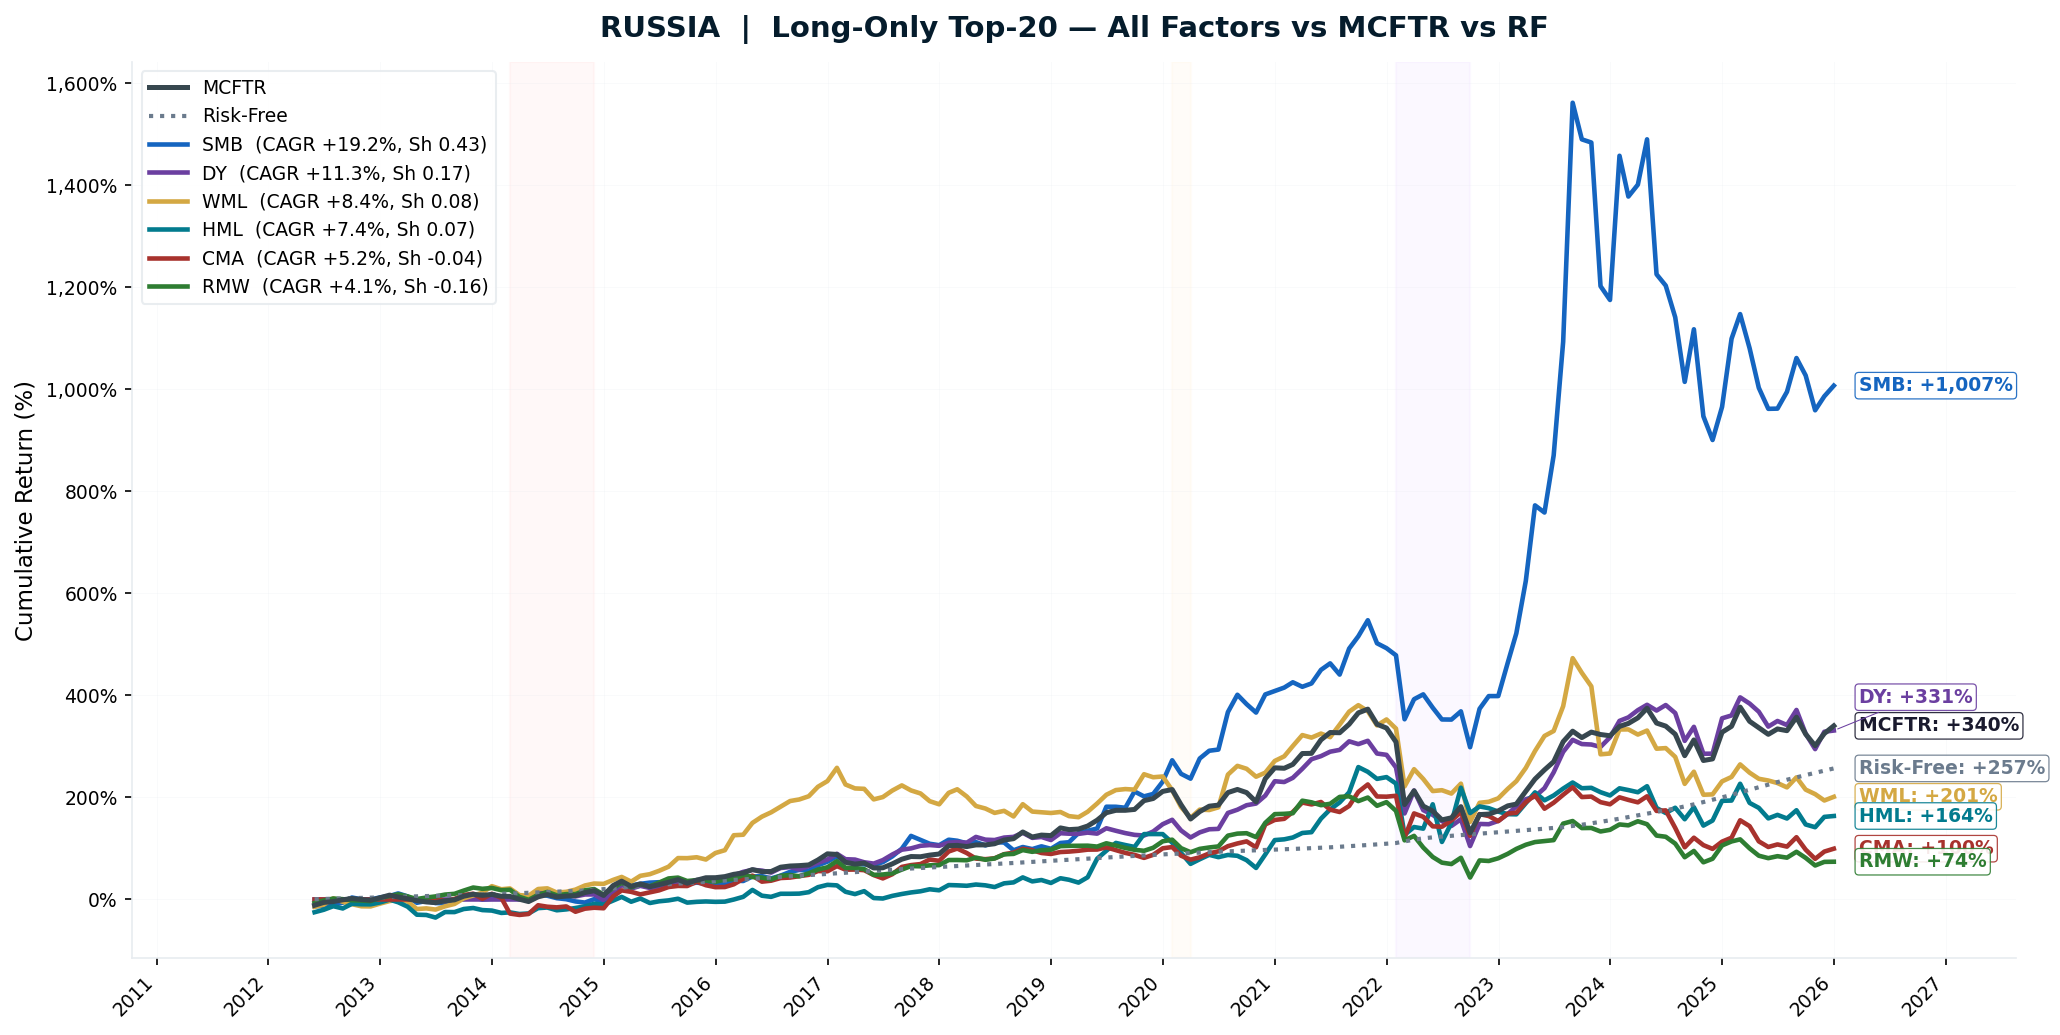

  -> /Users/dmitrijeremkin/Desktop/диплом созвон 5/output_factors/RF_LS_combined.png


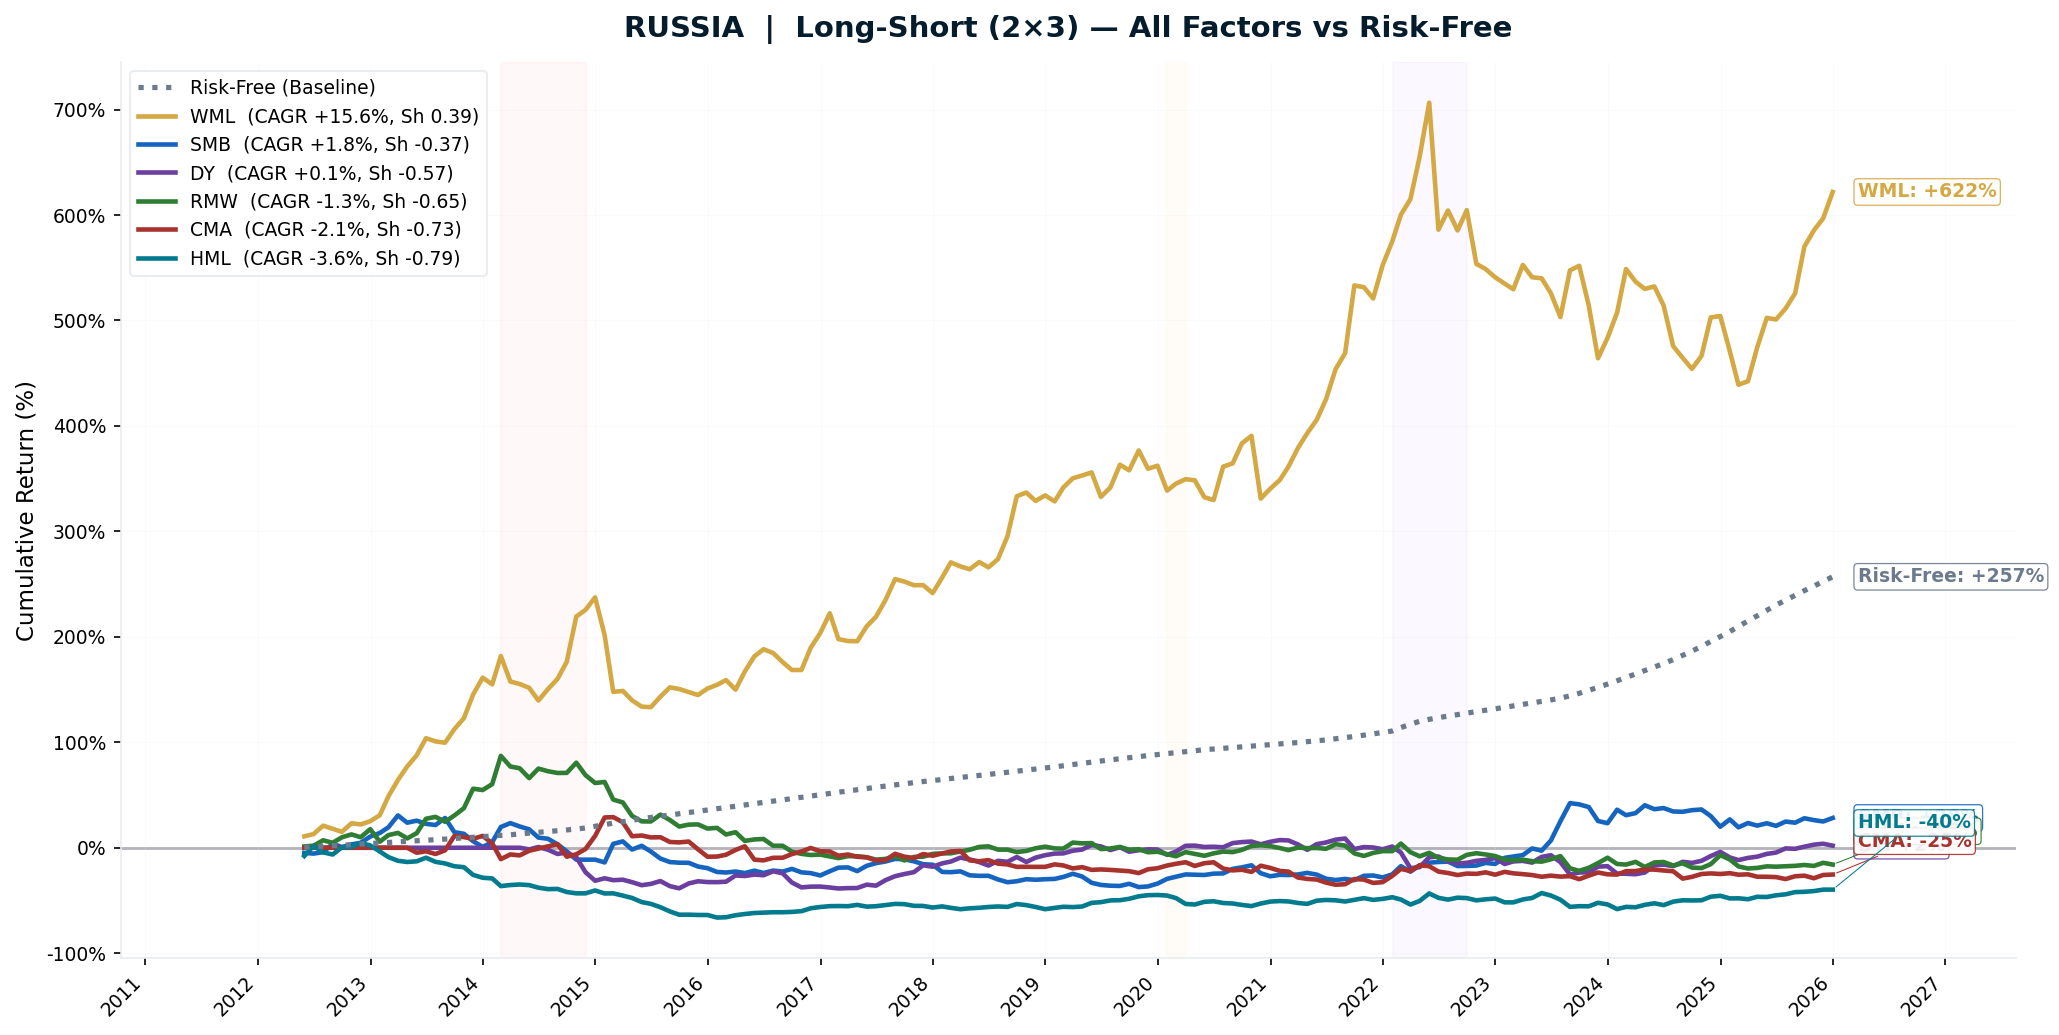

  -> /Users/dmitrijeremkin/Desktop/диплом созвон 5/output_factors/RF_individual_factors.png


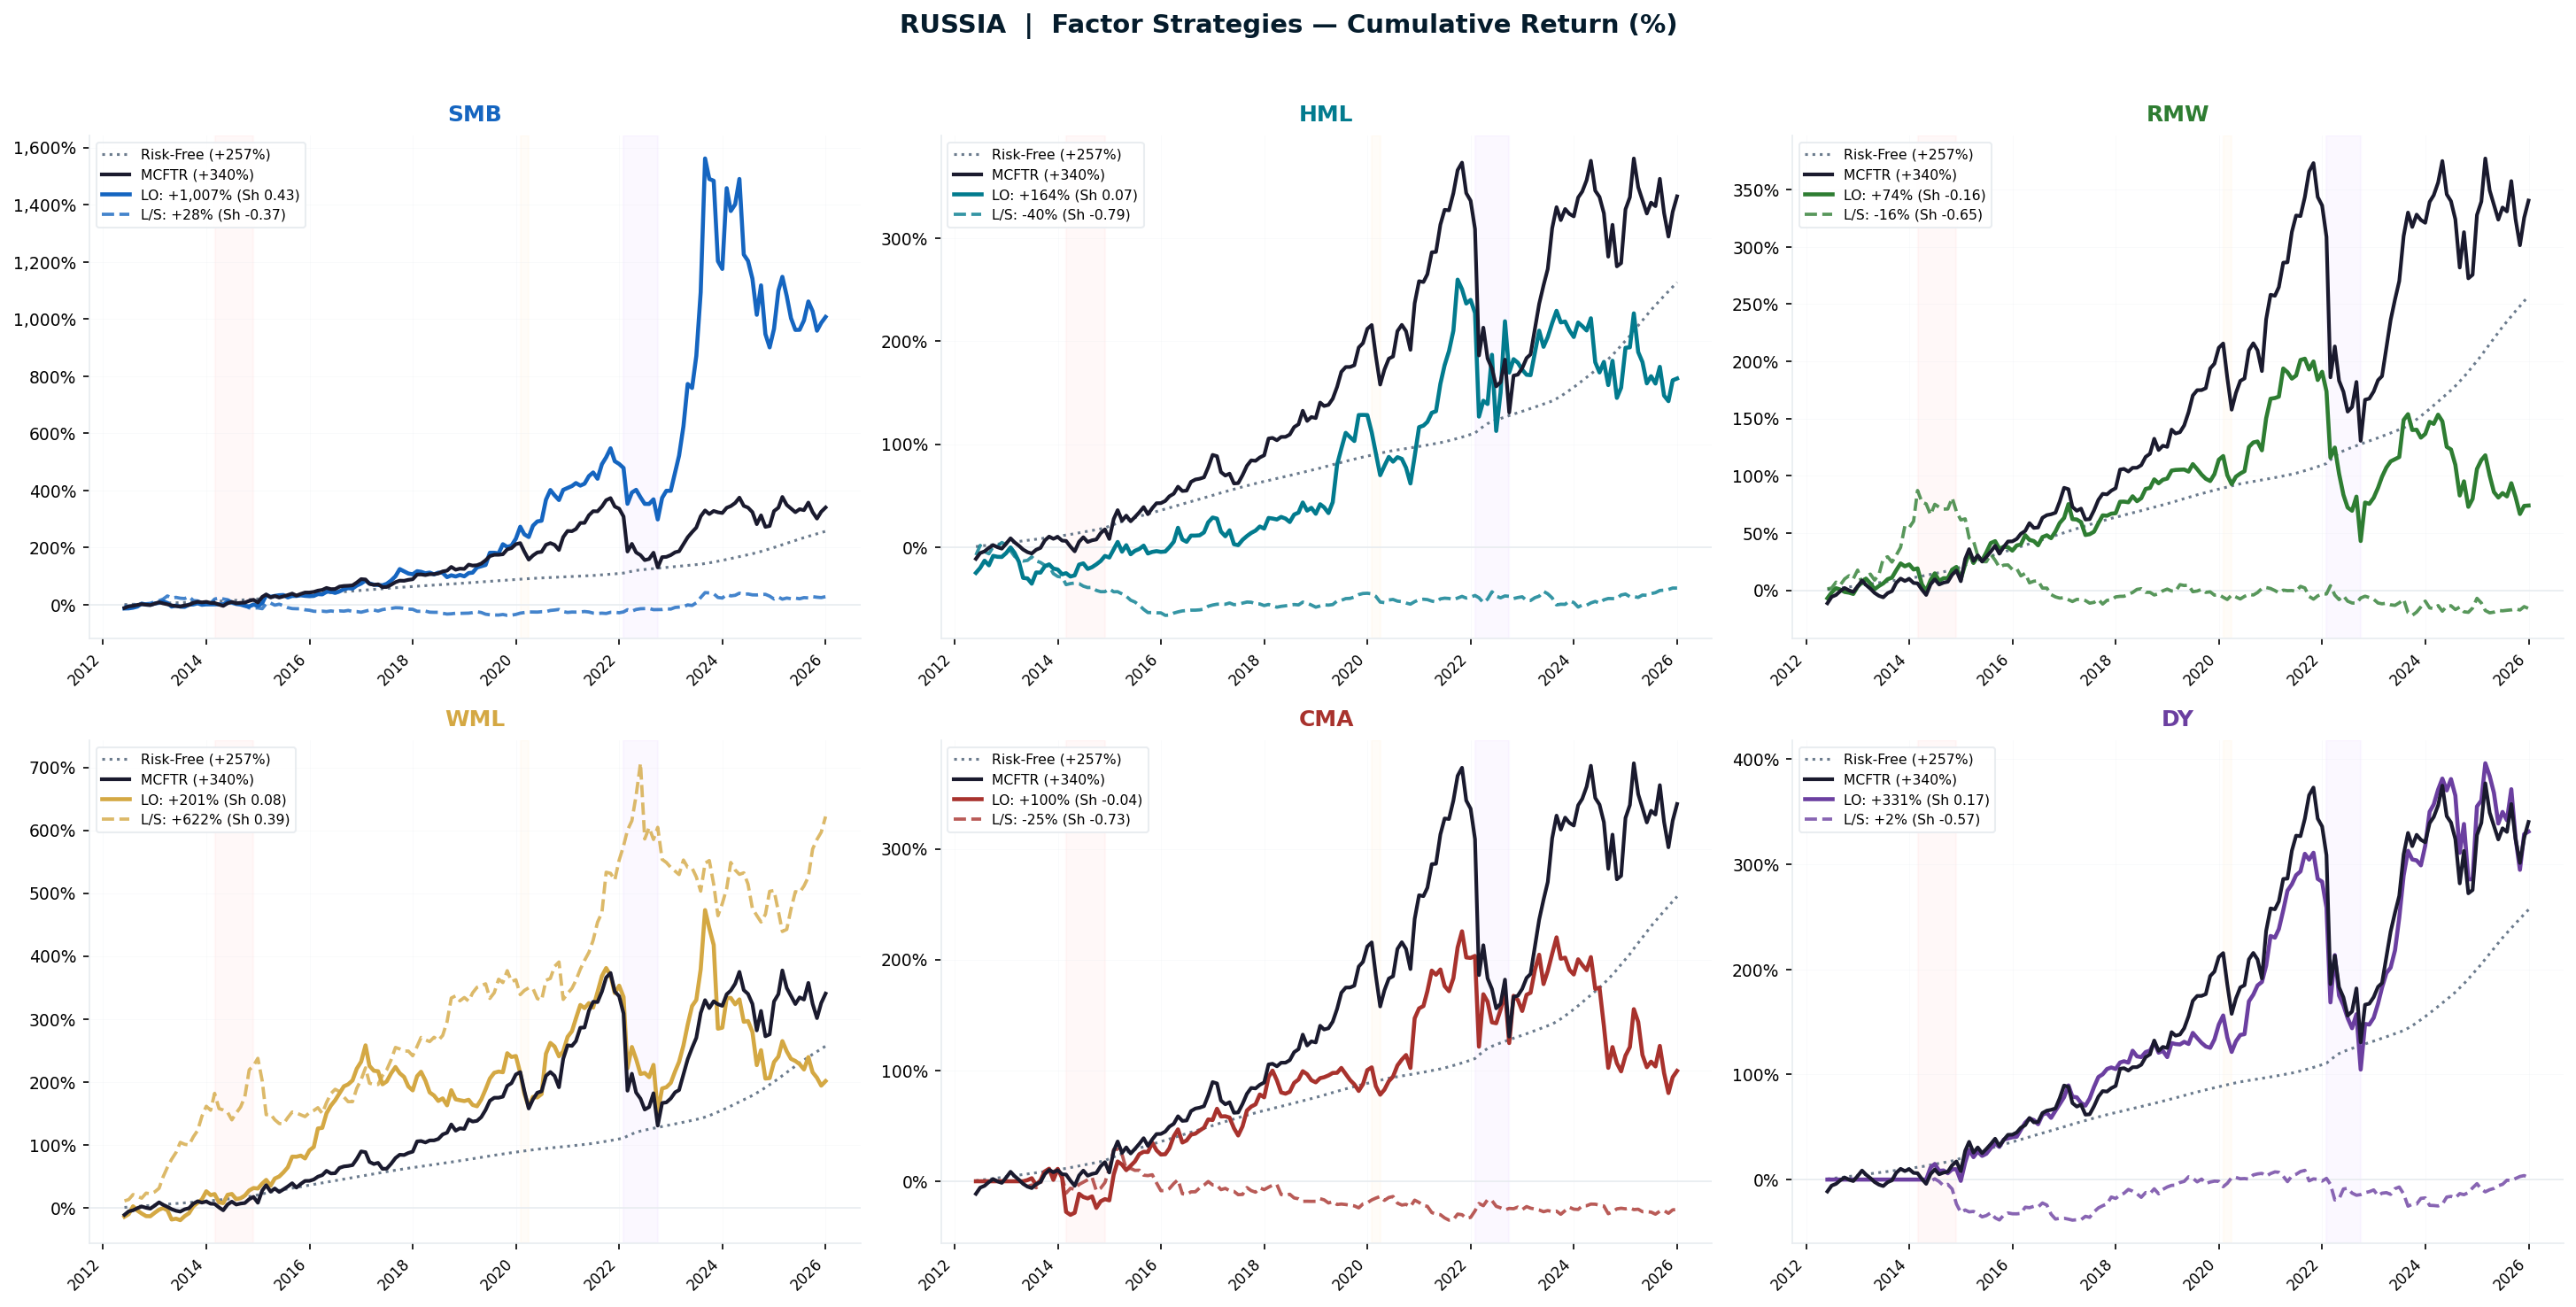

  -> /Users/dmitrijeremkin/Desktop/диплом созвон 5/output_factors/RF_fama_macbeth.png


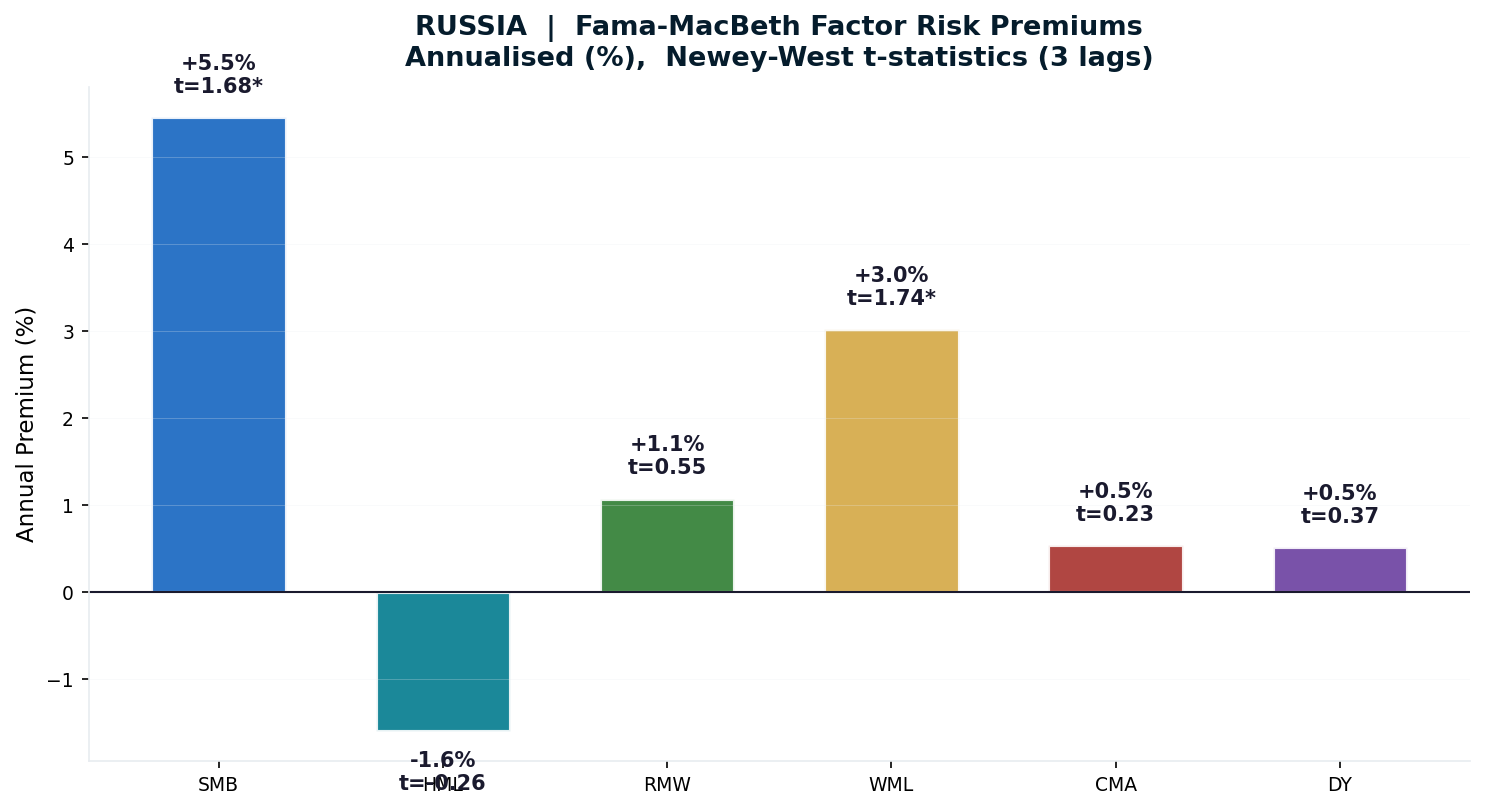

Strategy,Type,CAGR,Vol,Sharpe,MaxDD,HitRate,Cum
MCFTR,Benchmark,11.5%,20.2%,0.18,-51.3%,66%,4.40x
SMB,Long-Only,20.7%,27.8%,0.47,-39.8%,57%,12.45x
DY,Long-Only,13.6%,21.4%,0.24,-50.2%,62%,4.49x
WML,Long-Only,8.7%,24.7%,0.09,-48.7%,59%,3.15x
HML,Long-Only,7.6%,28.4%,0.07,-40.8%,56%,2.75x
CMA,Long-Only,5.8%,26.2%,-0.02,-44.8%,59%,2.05x
RMW,Long-Only,4.3%,19.9%,-0.16,-52.7%,60%,1.79x
WML,Long-Short,15.5%,16.8%,0.38,-33.2%,60%,7.22x
SMB,Long-Short,2.2%,16.7%,-0.35,-52.0%,50%,1.36x
DY,Long-Short,0.2%,15.5%,-0.54,-39.1%,59%,1.03x



  -> Saved alpha tests to RF_alpha_tests.xlsx

  RUSSIA BACKTEST COMPLETE


In [2]:
# все что ниже это 5факторная модель рф  и япония ═══════════════════════════════════════════════════════════════════
# FACTOR INVESTING BACKTEST — RUSSIA & JAPAN
# 
# 5 Factors: SMB, HML, RMW, WML, CMA
# - Annual rebalance: SMB, HML, RMW, CMA
# - Monthly rebalance: WML (Jegadeesh & Titman 1993)
# - Long-Only vs Risk-Free comparison with t-test
# - Long-Short vs Risk-Free comparison with t-test
# ═══════════════════════════════════════════════════════════════════

import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, os, sys, re
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter, PercentFormatter
import seaborn as sns
from dataclasses import dataclass, field
from IPython.display import display, HTML
from typing import Dict, List, Optional

# ═══════════════════════════════════════════════════════════════════
# McKINSEY STYLE
# ═══════════════════════════════════════════════════════════════════
MCKINSEY_NAVY    = '#051C2C'
MCKINSEY_TEAL    = '#027B8E'
MCKINSEY_GOLD    = '#D4A843'
MCKINSEY_RED     = '#A8322D'
MCKINSEY_GRAY    = '#6B7B8D'
MCKINSEY_LTGRAY  = '#E8ECF0'
MCKINSEY_BG      = '#FFFFFF'
MCKINSEY_BLACK   = '#1A1A2E'

FACTOR_PALETTE = {
    'SMB':  '#1565C0',   # royal blue   — Size
    'HML':  '#027B8E',   # teal         — Value
    'RMW':  '#2E7D32',   # forest green — Profitability
    'WML':  '#D4A843',   # gold         — Momentum
    'CMA':  '#A8322D',   # burgundy     — Investment
    'DY':   '#6B3FA0',   # purple       — Dividend Yield
}
FACTOR_ORDER = ['SMB', 'HML', 'RMW', 'WML', 'CMA', 'DY']

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'figure.dpi':        150,
    'figure.facecolor':  MCKINSEY_BG,
    'axes.facecolor':    '#FFFFFF',
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'axes.titleweight':  'bold',
    'axes.edgecolor':    MCKINSEY_LTGRAY,
    'axes.linewidth':    0.8,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'legend.fontsize':   9,
    'legend.framealpha':  0.95,
    'legend.edgecolor':  MCKINSEY_LTGRAY,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'grid.color':        MCKINSEY_LTGRAY,
    'grid.linewidth':    0.4,
    'grid.alpha':        0.5,
    'savefig.dpi':       300,
    'savefig.facecolor': '#FFFFFF',
    'figure.max_open_warning': 50,
})

BASE = str(DATA_DIR)
OUT  = str(PROJECT_ROOT / 'results' / 'factor_backtest')
os.makedirs(OUT, exist_ok=True)

def find_file(kw):
    try:
        for f in sorted(os.listdir(BASE)):
            if kw.lower() in f.lower():
                return os.path.join(BASE, f)
    except: pass
    return None

print("Setup OK")
print(f"  BASE = {BASE}")
print(f"  OUT  = {OUT}")

# ═══════════════════════════════════════════════════════════════════
# HELPERS
# ═══════════════════════════════════════════════════════════════════
def clean_tk(t):
    """Normalise ticker: upper-case, strip exchange suffixes."""
    if pd.isna(t): return None
    t = str(t).strip()
    if not t or t.lower() in ('nan', 'none', ''): return None
    t = t.upper()
    for sfx in ['.JP','.TYO','.T',' JP',' EQUITY','.ME',' RX',' RM','_RM',
                ' TOKYO',' TSE','.TSE','.OS','.NGY','.FKA','.SPE']:
        t = t.replace(sfx, '')
    t = t.strip()
    if t.isdigit():
        t = t.lstrip('0') or '0'
    return t if t else None

def find_col(df, candidates):
    """Return first column from candidates that exists with >=5 non-null."""
    for c in candidates:
        if c in df.columns and df[c].notna().sum() >= 5:
            return c
    return None

def safe_num(s):
    if s.dtype in ['float64','int64','float32','int32']:
        return s.replace([np.inf,-np.inf], np.nan)
    try:
        c = s.astype(str).str.replace(',','.').str.replace(r'\s+','',regex=True)
        c = c.replace(['','nan','None','NaN','-','#N/A','N/A',
                        '#VALUE!','#DIV/0!','null','inf','-inf'], np.nan)
        return pd.to_numeric(c, errors='coerce').replace([np.inf,-np.inf], np.nan)
    except: return pd.Series(np.nan, index=s.index)

def winz(s, lo=0.01, hi=0.99):
    s = s.copy()
    if s.notna().sum() < 5: return s
    return s.clip(lower=s.quantile(lo), upper=s.quantile(hi))

def zsc(s):
    std = s.std()
    return (s - s.mean()) / std if std > 1e-10 else s * 0.0

def sig_stars(p):
    if p < .01: return '***'
    if p < .05: return '**'
    if p < .10: return '*'
    return ''

def _ols(y, X):
    y, X = np.asarray(y, float), np.asarray(X, float)
    n, k = X.shape
    Xi = np.linalg.pinv(X.T @ X)
    b = Xi @ X.T @ y; e = y - X @ b; df = max(n-k, 1)
    s2 = (e@e)/df
    se = np.sqrt(np.maximum(np.diag(s2*Xi), 0))
    t  = b / np.where(se>1e-15, se, 1e-15)
    ss_r, ss_t = e@e, np.sum((y-y.mean())**2)
    r2 = 1 - ss_r/ss_t if ss_t > 1e-15 else 0.0
    p  = 2*(1-stats.t.cdf(np.abs(t), df))
    return dict(params=b, se=se, tvalues=t, pvalues=p, r2=r2, n=n)

def _ols_hac(y, X, lags=3):
    y, X = np.asarray(y, float), np.asarray(X, float)
    n, k = X.shape
    Xi = np.linalg.pinv(X.T @ X)
    b = Xi @ X.T @ y; e = y - X @ b; df = max(n-k,1)
    S = np.zeros((k,k))
    for t_ in range(n):
        xt = X[t_:t_+1].T; S += e[t_]**2 * (xt @ xt.T)
    for j in range(1, lags+1):
        w = 1-j/(lags+1); G = np.zeros((k,k))
        for t_ in range(j, n):
            G += e[t_]*e[t_-j] * (X[t_:t_+1].T @ X[t_-j:t_-j+1])
        S += w*(G+G.T)
    cov = Xi@S@Xi; se = np.sqrt(np.maximum(np.diag(cov),0))
    t = b/np.where(se>1e-15,se,1e-15)
    ss_r,ss_t = e@e, np.sum((y-y.mean())**2)
    r2 = 1-ss_r/ss_t if ss_t>1e-15 else 0.0
    p = 2*(1-stats.t.cdf(np.abs(t),df))
    return dict(params=b, se=se, tvalues=t, pvalues=p, r2=r2, n=n)

def nw_tstat(lam, lags=3):
    """Newey-West t-statistic for time series of lambdas."""
    lam = np.asarray(lam, float); lam = lam[~np.isnan(lam)]
    n = len(lam)
    if n < 3: return np.nan, np.nan, np.nan, np.nan
    mu = lam.mean(); e = lam - mu
    s2 = (e**2).mean()
    for j in range(1, min(lags, n-1)+1):
        s2 += 2*(1-j/(lags+1))*np.mean(e[j:]*e[:-j])
    se = np.sqrt(max(s2,0)/n)
    t = mu/se if se>1e-15 else 0.0
    p = 2*(1-stats.t.cdf(abs(t), max(n-1,1)))
    return mu, se, t, p

def metrics(r, rf_s=None):
    """Compute strategy metrics: CAGR, Vol, Sharpe, MaxDD, HitRate, Cum."""
    r = r.dropna()
    if len(r) < 6:
        return {k:np.nan for k in ['CAGR','Vol','Sharpe','MaxDD','HitRate','Cum']}
    cum = (1+r).cumprod(); yrs = len(r)/12
    cagr = cum.iloc[-1]**(1/max(yrs,0.1)) - 1
    vol = r.std()*np.sqrt(12)
    exc = r - rf_s.reindex(r.index).fillna(rf_s.mean()) if rf_s is not None else r
    shr = exc.mean()/exc.std()*np.sqrt(12) if exc.std()>1e-10 else 0.0
    dd = cum/cum.cummax()-1
    return {'CAGR':cagr, 'Vol':vol, 'Sharpe':shr,
            'MaxDD':dd.min(), 'HitRate':(r>0).mean(), 'Cum':cum.iloc[-1]}

print("Helpers OK")

# ═══════════════════════════════════════════════════════════════════
# RISK-FREE RATES
# ═══════════════════════════════════════════════════════════════════
# BOJ policy rate: 2025 added (0.25% Jan-Mar, 0.50% Apr-Dec after March 2025 hike)
_JP_RF = {
    '2010-01':0.12,'2010-02':0.12,'2010-03':0.13,'2010-04':0.12,'2010-05':0.12,'2010-06':0.11,
    '2010-07':0.11,'2010-08':0.11,'2010-09':0.11,'2010-10':0.11,'2010-11':0.11,'2010-12':0.10,
    '2011-01':0.10,'2011-02':0.10,'2011-03':0.10,'2011-04':0.10,'2011-05':0.10,'2011-06':0.10,
    '2011-07':0.10,'2011-08':0.10,'2011-09':0.10,'2011-10':0.10,'2011-11':0.10,'2011-12':0.10,
    '2012-01':0.10,'2012-02':0.10,'2012-03':0.10,'2012-04':0.10,'2012-05':0.10,'2012-06':0.10,
    '2012-07':0.10,'2012-08':0.10,'2012-09':0.10,'2012-10':0.09,'2012-11':0.09,'2012-12':0.09,
    '2013-01':0.09,'2013-02':0.09,'2013-03':0.08,'2013-04':0.06,'2013-05':0.06,'2013-06':0.06,
    '2013-07':0.06,'2013-08':0.06,'2013-09':0.06,'2013-10':0.06,'2013-11':0.06,'2013-12':0.06,
    '2014-01':0.05,'2014-02':0.05,'2014-03':0.05,'2014-04':0.04,'2014-05':0.04,'2014-06':0.04,
    '2014-07':0.04,'2014-08':0.04,'2014-09':0.03,'2014-10':0.03,'2014-11':0.02,'2014-12':0.02,
    '2015-01':0.02,'2015-02':0.02,'2015-03':0.02,'2015-04':0.01,'2015-05':0.01,'2015-06':0.01,
    '2015-07':0.01,'2015-08':0.01,'2015-09':0.00,'2015-10':0.00,'2015-11':0.00,'2015-12':0.00,
    '2016-01':0.00,'2016-02':-0.05,'2016-03':-0.09,'2016-04':-0.12,'2016-05':-0.14,'2016-06':-0.21,
    '2016-07':-0.24,'2016-08':-0.17,'2016-09':-0.20,'2016-10':-0.17,'2016-11':-0.16,'2016-12':-0.13,
    '2017-01':-0.14,'2017-02':-0.14,'2017-03':-0.13,'2017-04':-0.14,'2017-05':-0.15,'2017-06':-0.14,
    '2017-07':-0.14,'2017-08':-0.14,'2017-09':-0.14,'2017-10':-0.14,'2017-11':-0.14,'2017-12':-0.13,
    '2018-01':-0.14,'2018-02':-0.14,'2018-03':-0.14,'2018-04':-0.13,'2018-05':-0.13,'2018-06':-0.12,
    '2018-07':-0.12,'2018-08':-0.12,'2018-09':-0.12,'2018-10':-0.13,'2018-11':-0.13,'2018-12':-0.14,
    '2019-01':-0.13,'2019-02':-0.12,'2019-03':-0.11,'2019-04':-0.12,'2019-05':-0.12,'2019-06':-0.15,
    '2019-07':-0.16,'2019-08':-0.18,'2019-09':-0.19,'2019-10':-0.16,'2019-11':-0.15,'2019-12':-0.12,
    '2020-01':-0.10,'2020-02':-0.09,'2020-03':-0.05,'2020-04':-0.07,'2020-05':-0.09,'2020-06':-0.10,
    '2020-07':-0.10,'2020-08':-0.10,'2020-09':-0.10,'2020-10':-0.10,'2020-11':-0.11,'2020-12':-0.10,
    '2021-01':-0.10,'2021-02':-0.11,'2021-03':-0.10,'2021-04':-0.10,'2021-05':-0.10,'2021-06':-0.10,
    '2021-07':-0.10,'2021-08':-0.11,'2021-09':-0.10,'2021-10':-0.10,'2021-11':-0.10,'2021-12':-0.10,
    '2022-01':-0.09,'2022-02':-0.08,'2022-03':-0.08,'2022-04':-0.07,'2022-05':-0.06,'2022-06':-0.06,
    '2022-07':-0.08,'2022-08':-0.08,'2022-09':-0.08,'2022-10':-0.06,'2022-11':-0.05,'2022-12':-0.04,
    '2023-01':-0.04,'2023-02':-0.05,'2023-03':-0.07,'2023-04':-0.06,'2023-05':-0.06,'2023-06':-0.05,
    '2023-07':-0.05,'2023-08':-0.03,'2023-09':-0.03,'2023-10':-0.02,'2023-11':-0.02,'2023-12':-0.01,
    '2024-01':-0.02,'2024-02':-0.01,'2024-03':0.00,'2024-04':0.02,'2024-05':0.03,'2024-06':0.04,
    '2024-07':0.05,'2024-08':0.15,'2024-09':0.18,'2024-10':0.20,'2024-11':0.22,'2024-12':0.22,
    '2025-01':0.25,'2025-02':0.25,'2025-03':0.25,'2025-04':0.50,'2025-05':0.50,'2025-06':0.50,
    '2025-07':0.50,'2025-08':0.50,'2025-09':0.50,'2025-10':0.50,'2025-11':0.50,'2025-12':0.50,
    '2026-01':0.32,'2026-02':0.42,'2026-03':0.43,'2026-04':0.44,'2026-05':0.46,'2026-06':0.46,
    '2026-07':0.46,'2026-08':0.46,'2026-09':0.46,'2026-10':0.46,'2026-11':0.46,'2026-12':0.46,
}

def build_japan_rf():
    idx    = pd.to_datetime(list(_JP_RF.keys())) + pd.offsets.MonthEnd(0)
    annual = np.array(list(_JP_RF.values())) / 100.0
    monthly = np.sign(annual) * (np.abs(1 + annual) ** (1/12) - 1)
    rf = pd.Series(monthly, index=idx, name='rf_jp')
    print(f"  JP rf: {len(rf)} mths, avg annual = {rf.mean()*12:.3%}")
    return rf

def load_ruonia(path):
    print(f"  Loading RUONIA...")
    try:
        df = pd.read_excel(path)
        dc = df.columns[0]; rc = [c for c in df.columns if c != dc][0]
        df['_d'] = pd.to_datetime(df[dc], errors='coerce', dayfirst=True)
        df = df.dropna(subset=['_d'])
        raw = df[rc].copy()
        if raw.dtype == 'object':
            raw = raw.astype(str).str.replace(',','.').str.replace('%','').str.strip()
        df['_r'] = pd.to_numeric(raw, errors='coerce')
        df = df.dropna(subset=['_r'])
        df['_rf'] = (1 + df['_r'] / (100 if df['_r'].median() > 1 else 1)) ** (1/12) - 1
        rf = df.set_index('_d')['_rf'].resample('ME').last().dropna()
        print(f"  RUONIA: {len(rf)} mths, avg annual = {rf.mean()*12:.2%}")
        return rf
    except Exception as e:
        print(f"  RUONIA fallback ({e})")
        avgs = {2011:3.9,2012:6.1,2013:6.2,2014:8.3,2015:11.0,2016:10.5,
                2017:8.9,2018:7.4,2019:7.1,2020:4.4,2021:5.6,2022:9.0,
                2023:8.5,2024:15.0,2026:20.0}
        dates, rates = [], []
        for y, r in avgs.items():
            for m in range(1,13):
                dates.append(pd.Timestamp(y,m,1)+pd.offsets.MonthEnd(0))
                rates.append((1+r/100)**(1/12)-1)
        return pd.Series(rates, index=pd.DatetimeIndex(dates), name='rf_ru')

print("RF helpers OK")

# ═══════════════════════════════════════════════════════════════════
# CONFIG
# ═══════════════════════════════════════════════════════════════════
@dataclass
class Config:
    country:         str   = 'RF'
    flag:            str   = ''
    panel_path:      str   = ''
    prices_path:     str   = ''
    prices_format:   str   = 'wide'
    benchmark_path:  str   = ''
    rf_path:         str   = ''
    ticker_col:      str   = 'ticker'
    year_col:        str   = 'year'
    sector_col:      str   = 'sector'
    start_year:      int   = 2012
    max_year:        int   = 2026
    rebalance_month: int   = 7
    top_n:           int   = 20
    tc_bps:          float = 50.0
    min_market_cap:  float = 5000.0
    bank_sectors:    list  = field(default_factory=list)
    benchmark_name:  str   = 'Benchmark'
    crises:          list  = field(default_factory=list)

def cfg_rf():
    return Config(
        country='RF', flag='Russia',
        panel_path    = find_file('рф_ПАНЕЛЬ'),
        prices_path   = find_file('russian_stocks_adjusted'),
        prices_format = 'wide',
        benchmark_path= find_file('мосбиржи полн дох'),
        rf_path       = find_file('руония'),
        sector_col    = 'sector',
        start_year=2012, max_year=2026, rebalance_month=5,
        tc_bps=50.0, min_market_cap=5000,
        bank_sectors=['Финансы (Банки)','Финансы','Banks','Financials'],
        benchmark_name='MCFTR',
        crises=[
            {'s':'2014-03','e':'2014-12','n':'Crimea/Oil','c':'#FFD6D6'},
            {'s':'2020-02','e':'2020-04','n':'COVID',     'c':'#FFF0D6'},
            {'s':'2022-02','e':'2022-10','n':'Sanctions', 'c':'#E8D6FF'},
        ],
    )

def cfg_jp():
    return Config(
        country='JP', flag='Japan',
        panel_path    = find_file('JP_PANEL'),
        prices_path   = find_file('nikkei225_monthly_returns'),
        prices_format = 'long',
        benchmark_path= find_file('ИНДЕКС nikkei225'),
        sector_col    = 'super_sector',
        start_year=2012, max_year=2026, rebalance_month=7,
        tc_bps=30.0, min_market_cap=30000,
        bank_sectors=['Banks','Diversified Financials','Regional Banks',
                      'Insurance','Financial Services'],
        benchmark_name='Nikkei 225 TR',
        crises=[
            {'s':'2011-03','e':'2011-06','n':'Fukushima','c':'#FFD6D6'},
            {'s':'2020-02','e':'2020-04','n':'COVID',    'c':'#FFF0D6'},
            {'s':'2022-03','e':'2022-10','n':'Yen Crash','c':'#E8D6FF'},
        ],
    )

print("Config OK")

# ═══════════════════════════════════════════════════════════════════
# DATA MANAGER
# ═══════════════════════════════════════════════════════════════════
class DataManager:
    def __init__(self, cfg):
        self.cfg = cfg
        self.panel = self.prices = self.benchmark = self.rf = None

    def load(self):
        c = self.cfg
        print(f"\n{'='*65}")
        print(f"  {c.flag} — LOADING DATA")
        print(f"{'='*65}")
        self.rf = load_ruonia(c.rf_path) if c.country == 'RF' else build_japan_rf()
        self._load_panel()
        self._load_prices()
        self._reconcile_tickers()
        self._load_benchmark()
        self._fill_momentum()

    def _load_panel(self):
        c = self.cfg
        basename = os.path.basename(str(c.panel_path))
        if basename.startswith('~$'):
            raise ValueError(f"Path points to Excel lock file: {basename}\n"
                           f"Close Excel and use the actual file.")
        print(f"  Panel: {basename}")
        p = pd.read_excel(c.panel_path)
        p.columns = [col.strip() for col in p.columns]
        p[c.ticker_col] = p[c.ticker_col].apply(clean_tk)
        p = p[p[c.ticker_col].notna()].copy()

        if c.sector_col in p.columns:
            p['is_bank'] = p[c.sector_col].apply(
                lambda x: str(x).strip() in c.bank_sectors)
        else:
            p['is_bank'] = False

        p['trading_year'] = p[c.year_col] + 1

        hints = ['_pct','_mln','_ratio','pe','pb','ps','ev_','mom_','vol_','beta',
                 'roe','roa','margin','debt','yield','return','turnover','amihud',
                 'accruals','cash','payout','market_cap','log_market','nim','npl',
                 'buyback','shareholder','div','gross','assets','book','profit',
                 'revenue','investment','asset_growth','capex']
        for col in p.columns:
            if any(h in col.lower() for h in hints) and p[col].dtype == 'object':
                p[col] = safe_num(p[col])

        p = p.sort_values([c.ticker_col, c.year_col])
        self.panel = p
        sample_tks = sorted(p[c.ticker_col].unique()[:10])
        print(f"    {len(p):,} rows | {p[c.ticker_col].nunique()} tickers "
              f"| years {p[c.year_col].min()}-{p[c.year_col].max()}")
        print(f"    Sample panel tickers: {sample_tks}")

    def _load_prices(self):
        c = self.cfg
        path = c.prices_path
        print(f"  Prices: {os.path.basename(str(path))}")

        if c.prices_format == 'wide':
            df = pd.read_excel(path, index_col=0, parse_dates=True)
            df.index = pd.to_datetime(df.index, errors='coerce')
            df = df[df.index.notna()]
            melt = df.reset_index().melt(
                id_vars=df.index.name or 'index',
                var_name='ticker', value_name='close')
            melt.columns = ['date','ticker','close']
            melt['ticker'] = melt['ticker'].apply(clean_tk)
            melt['close']  = pd.to_numeric(melt['close'], errors='coerce')
            melt = melt.dropna(subset=['date','ticker','close']).sort_values(['ticker','date'])
            melt['ret'] = melt.groupby('ticker')['close'].pct_change()
            pr = melt[['date','ticker','ret']].copy()
        else:
            ext = str(path).split('.')[-1].lower()
            df = pd.read_csv(path) if ext == 'csv' else pd.read_excel(path, index_col=0).reset_index()
            df.columns = [str(x).strip().lower() for x in df.columns]
            print(f"    Columns: {list(df.columns[:15])}")

            date_col = None
            for dc in ['date','month','period','ym','year_month']:
                if dc in df.columns:
                    date_col = dc; break
            if date_col is None:
                date_col = df.columns[0]

            tk_col = None
            for tc in ['ticker','symbol','code','stock','security','name']:
                if tc in df.columns:
                    tk_col = tc; break
            if tk_col is None:
                tk_col = [c for c in df.columns if c != date_col][0] if len(df.columns) > 1 else df.columns[0]

            df['date']   = pd.to_datetime(df[date_col], errors='coerce')
            df['ticker'] = df[tk_col].apply(clean_tk)

            ret_found = False
            for rc in ['return_1mo','ret_month_tr','ret','monthly_return','return','price_return',
                        'total_return','tr_1m','ret_1m']:
                if rc in df.columns:
                    df['ret'] = pd.to_numeric(df[rc], errors='coerce')
                    ret_found = True
                    print(f"    Return column: {rc}")
                    break
            if not ret_found:
                if 'close' in df.columns or 'price' in df.columns:
                    pc = 'close' if 'close' in df.columns else 'price'
                    df[pc] = pd.to_numeric(df[pc], errors='coerce')
                    df = df.sort_values(['ticker','date'])
                    df['ret'] = df.groupby('ticker')[pc].pct_change()
                    print(f"    Return computed from {pc}")
                else:
                    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
                    print(f"    WARNING: No return/close column found. Numeric cols: {num_cols[:10]}")
                    if num_cols:
                        df['ret'] = df[num_cols[0]]
                    else:
                        df['ret'] = np.nan

            pr = df[['date','ticker','ret']].copy()

        pr['date'] = pd.to_datetime(pr['date'], errors='coerce')
        pr = pr.dropna(subset=['date'])
        pr['ret'] = pd.to_numeric(pr['ret'], errors='coerce')
        pr.loc[pr['ret'].abs() > 2.5, 'ret'] = np.nan
        pr = pr.sort_values(['ticker','date'])
        pr.set_index('date', inplace=True)
        self.prices = pr

        sample_tks = sorted(pr['ticker'].dropna().unique()[:10])
        print(f"    {pr['ticker'].nunique()} tickers | "
              f"{pr.index.min().date()} – {pr.index.max().date()}")
        print(f"    Sample price tickers: {sample_tks}")

    def _reconcile_tickers(self):
        c = self.cfg
        pan_tks = set(self.panel[c.ticker_col].unique())
        pri_tks = set(self.prices['ticker'].dropna().unique())

        overlap = pan_tks & pri_tks
        print(f"\n  TICKER RECONCILIATION:")
        print(f"    Panel tickers:  {len(pan_tks)}")
        print(f"    Price tickers:  {len(pri_tks)}")
        print(f"    Direct overlap: {len(overlap)}")

        if len(overlap) >= 10:
            print(f"    OK — {len(overlap)} matched directly")
            return

        def normalize(t):
            return re.sub(r'[^A-Z0-9]', '', str(t).upper())

        pan_norm = {normalize(t): t for t in pan_tks}
        pri_norm = {normalize(t): t for t in pri_tks}
        norm_overlap = set(pan_norm.keys()) & set(pri_norm.keys())

        if len(norm_overlap) > len(overlap):
            print(f"    Strategy 1 (strip non-alnum): {len(norm_overlap)} matches")
            rename_map = {}
            for nk in norm_overlap:
                if pan_norm[nk] != pri_norm[nk]:
                    rename_map[pri_norm[nk]] = pan_norm[nk]
            if rename_map:
                self.prices['ticker'] = self.prices['ticker'].replace(rename_map)
                print(f"    Renamed {len(rename_map)} price tickers to match panel")

        pan_digits = {t.lstrip('0') or '0': t for t in pan_tks if t.isdigit()}
        pri_digits = {t.lstrip('0') or '0': t for t in pri_tks if t.isdigit()}
        digit_overlap = set(pan_digits.keys()) & set(pri_digits.keys())

        remaining = digit_overlap - set(normalize(t) for t in (pan_tks & pri_tks))
        if remaining:
            rename2 = {}
            for dk in remaining:
                if pan_digits[dk] != pri_digits[dk]:
                    rename2[pri_digits[dk]] = pan_digits[dk]
            if rename2:
                self.prices['ticker'] = self.prices['ticker'].replace(rename2)
                print(f"    Strategy 2 (digit normalize): {len(rename2)} additional matches")

        final_overlap = (set(self.panel[c.ticker_col].unique()) &
                         set(self.prices['ticker'].dropna().unique()))
        print(f"    FINAL overlap: {len(final_overlap)}")

        if len(final_overlap) < 5:
            print("\n    *** WARNING: Very low overlap! ***")
            print("    Panel sample:", sorted(list(pan_tks))[:8])
            print("    Price sample:", sorted(list(pri_tks))[:8])

    def _load_benchmark(self):
        c = self.cfg
        path = c.benchmark_path
        if path and os.path.exists(str(path)):
            try:
                if str(path).endswith('.csv'):
                    df = pd.read_csv(path, sep=';', decimal=',',
                                     names=['ID','date','open','close'], skiprows=1)
                else:
                    df = pd.read_excel(path)
                    df = df.rename(columns={df.columns[0]:'date', df.columns[1]:'close'})
                df['date']  = pd.to_datetime(df['date'], errors='coerce')
                df['close'] = pd.to_numeric(
                    df['close'].astype(str).str.replace(r'[^\d.\-]','',regex=True),
                    errors='coerce')
                df = df.dropna(subset=['date','close']).sort_values('date')
                bm = df.set_index('date')[['close']].resample('ME').last()
                bm['ret'] = bm['close'].pct_change()
                self.benchmark = bm[['ret']].dropna()
                print(f"  Benchmark ({c.benchmark_name}): {len(self.benchmark)} mths")
                return
            except Exception as e:
                print(f"  Benchmark error: {e}")
        pr = self.prices.copy()
        pr['ym'] = pr.index.to_period('M')
        bm = (pr.groupby(['ym','ticker'])['ret']
                .apply(lambda x: (1+x.dropna()).prod()-1 if len(x.dropna())>0 else np.nan)
                .groupby(level=0).mean())
        bm.index = bm.index.to_timestamp('M') + pd.offsets.MonthEnd(0)
        self.benchmark = bm.to_frame('ret').dropna()
        self.benchmark = self.benchmark[self.benchmark.index >= pd.Timestamp(c.start_year,1,1)]
        print(f"  Benchmark (EW fallback): {len(self.benchmark)} mths")

    def _fill_momentum(self):
        c = self.cfg; p = self.panel
        col12, col6 = 'mom_12_1_pct', 'mom_6_1_pct'
        for col in [col12, col6]:
            if col not in p.columns: p[col] = np.nan

        pr = self.prices.copy()
        pr['ym'] = pr.index.to_period('M')
        monthly = (pr.groupby(['ym','ticker'])['ret']
                     .apply(lambda x: (1+x.dropna()).prod()-1 if len(x.dropna())>0 else np.nan)
                     .reset_index())
        monthly.columns = ['ym','ticker','mret']
        monthly['date'] = monthly['ym'].dt.to_timestamp('M') + pd.offsets.MonthEnd(0)
        monthly = monthly.dropna(subset=['mret']).sort_values(['ticker','date'])
        mret_tk = {tk: grp.set_index('date')['mret'].sort_index()
                   for tk, grp in monthly.groupby('ticker')}

        need = p[col12].isna() | p[col6].isna()
        f12 = f6 = 0
        for idx in p[need].index:
            tk = p.loc[idx, c.ticker_col]
            yr = int(p.loc[idx, c.year_col])
            ts = mret_tk.get(tk)
            if ts is None or len(ts) < 3: continue
            ref = pd.Timestamp(yr+1, c.rebalance_month, 1) + pd.offsets.MonthEnd(0)
            end = ref - pd.offsets.MonthEnd(1)
            if pd.isna(p.loc[idx, col12]):
                s12 = ref - pd.offsets.MonthEnd(12)
                r12 = ts[(ts.index > s12) & (ts.index <= end)]
                if len(r12) >= 6:
                    p.loc[idx, col12] = ((1+r12).prod()-1)*100; f12 += 1
            if pd.isna(p.loc[idx, col6]):
                s6  = ref - pd.offsets.MonthEnd(6)
                r6  = ts[(ts.index > s6) & (ts.index <= end)]
                if len(r6) >= 3:
                    p.loc[idx, col6] = ((1+r6).prod()-1)*100; f6 += 1
        self.panel = p
        print(f"  Momentum fill: 12-1={f12}, 6-1={f6}")

print("DataManager OK")

# ═══════════════════════════════════════════════════════════════════
# FACTOR DEFINITIONS
# ═══════════════════════════════════════════════════════════════════
FACTOR_DEFS = {
    'SMB': (
        ['log_market_cap', 'market_cap_mln', 'market_cap'],
        -1,
        'Fama-French Size factor (Small Minus Big)'),
    'HML': (
        ['book_to_market', 'pbv', 'pb', 'price_to_book'],
        +1,
        'Fama-French Value factor (High Minus Low)'),
    'RMW': (
        ['_gpa_computed', 'gross_profit_margin_pct', 'ebitda_margin_pct',
         'roe_pct', 'roa_pct', 'net_margin_pct'],
        +1,
        'Profitability factor (Robust Minus Weak)'),
    'WML': (
        ['mom_12_1_pct', 'mom12_1', 'momentum'],
        +1,
        'Carhart Momentum factor (Winners Minus Losers)'),
    'CMA': (
        ['assets_growth_pct', 'asset_growth_pct', '_asset_growth_computed',
         'investment', 'total_assets_growth', 'capex_to_revenue'],
        -1,
        'Fama-French Investment factor (Conservative Minus Aggressive)'),
    'DY': (
        ['div_yield_pct', 'dividend_yield', 'dy', 'div_yield',
         'total_shareholder_yield_pct'],
        +1,
        'Dividend Yield factor (High Minus Low)'),
}

_PBV_COLS = {'pbv', 'pb', 'price_to_book', 'p_b', 'pb_ratio'}

def compute_signals(panel, cfg, penny_pct=0.01):
    """
    Add sig_SMB, sig_HML, sig_RMW, sig_WML, sig_CMA to panel.
    Signals are winsorised 1-99%, then z-scored cross-sectionally per year.
    """
    c = cfg
    p = panel.copy()
    mc_col = find_col(p, ['market_cap_mln', 'market_cap', 'mktcap'])

    # ── PRE-COMPUTE: Asset Growth (CMA) ────────────────────────────────
    inv_col = find_col(p, ['assets_growth_pct', 'asset_growth_pct'])
    if inv_col is None:
        ta_col = find_col(p, ['assets_mln', 'total_assets', 'total_assets_mln', 'ta_mln'])
        if ta_col:
            p = p.sort_values([c.ticker_col, c.year_col])
            p['_ta_lag'] = p.groupby(c.ticker_col)[ta_col].shift(1)
            # FIX: handle negative assets
            ta_lag_safe = p['_ta_lag'].where(p['_ta_lag'] > 0)
            p['_asset_growth_computed'] = (p[ta_col] / ta_lag_safe - 1) * 100
            p.drop(columns=['_ta_lag'], inplace=True)
            nn = p['_asset_growth_computed'].notna().sum()
            print(f"  [CMA] Computed _asset_growth_computed from {ta_col} ({nn} non-null)")
        else:
            print("  [CMA] WARNING: no assets column found")

    # ── PRE-COMPUTE: Gross Profitability proxy (RMW) ───────────────────
    gpa_col = find_col(p, ['gross_profit_margin_pct'])
    if gpa_col is None:
        ebitda_col = find_col(p, ['ebitda_mln', 'ebitda'])
        ta_col2    = find_col(p, ['assets_mln', 'total_assets', 'total_assets_mln'])
        if ebitda_col and ta_col2:
            # FIX: handle negative assets
            ta_safe = p[ta_col2].where(p[ta_col2] > 0)
            p['_gpa_computed'] = p[ebitda_col] / ta_safe * 100
            nn = p['_gpa_computed'].notna().sum()
            print(f"  [RMW] Computed _gpa_computed = EBITDA/Assets proxy ({nn} non-null)")
        else:
            print(f"  [RMW] Will try ROE/ROA/net_margin as profitability proxy")

    # ── COMPUTE EACH SIGNAL ────────────────────────────────────────────
    out_cols = []
    for fname, (candidates, direction, desc) in FACTOR_DEFS.items():
        sig_col = f'sig_{fname}'
        raw_col = find_col(p, candidates)
        p[sig_col] = np.nan

        if raw_col is None:
            print(f"  [{fname:4s}] SKIP — no column found among {candidates[:3]}...")
            continue

        # FIX: use 'trading_year' consistently (created in DataManager)
        for yr in sorted(p['trading_year'].unique()):
            mask = p['trading_year'] == yr
            if mc_col and penny_pct > 0:
                mc_vals = p.loc[mask, mc_col].dropna()
                if len(mc_vals) > 10:
                    mask = mask & (p[mc_col] >= mc_vals.quantile(penny_pct))

            sub = p.loc[mask, raw_col].copy()
            if sub.notna().sum() < 5:
                continue

            raw = winz(sub)

            # Special transforms
            if raw_col.lower() in _PBV_COLS:
                raw = 1.0 / raw.clip(lower=0.01)
                eff_dir = +1
            elif raw_col == 'log_market_cap':
                eff_dir = direction
            elif raw_col in ['market_cap_mln', 'market_cap']:
                raw = np.log(raw.clip(lower=0.01))
                eff_dir = direction
            else:
                eff_dir = direction

            raw = raw * eff_dir
            z = zsc(raw)
            p.loc[z.index, sig_col] = z.values

        n_ok = p[sig_col].notna().sum()
        if n_ok > 0:
            out_cols.append(sig_col)
        print(f"  [{fname:4s}] col={str(raw_col):30s} | {n_ok:>5} non-null "
              f"({n_ok/len(p):.0%}) | {desc}")

    return p, out_cols

print("Signal functions OK:", list(FACTOR_DEFS.keys()))

# ═══════════════════════════════════════════════════════════════════
# LONG-ONLY PORTFOLIOS
# ═══════════════════════════════════════════════════════════════════
def run_longonly(panel, prices, cfg, signal_col, top_n=20, vw=True, factor_label='F'):
    """
    Long-only top-N factor portfolio.
    - WML: MONTHLY rebalance (Jegadeesh & Titman 1993)
    - Others: ANNUAL rebalance (Fama-French)
    """
    c = cfg
    mc_col = find_col(panel, ['market_cap_mln', 'market_cap', 'mktcap'])

    is_momentum = (factor_label.upper() in ('WML', 'MOM', 'MOMENTUM')
                   or 'wml' in signal_col.lower()
                   or 'mom' in signal_col.lower())

    if is_momentum:
        return _run_lo_momentum_monthly(panel, prices, c, top_n, vw, factor_label, mc_col)

    # ═══════════════════════════════════════════════════════════════
    # ANNUAL REBALANCING (SMB / HML / RMW / CMA)
    # ═══════════════════════════════════════════════════════════════
    rets = []
    for year in range(c.start_year, c.max_year + 1):
        mask = panel['trading_year'] == year
        if mc_col and c.min_market_cap > 0:
            mask &= (panel[mc_col] >= c.min_market_cap)
        uni = panel[mask].dropna(subset=[signal_col]).copy()
        if len(uni) < top_n:
            continue

        sel = uni.nlargest(top_n, signal_col)
        tickers = sel[c.ticker_col].tolist()

        if vw and mc_col:
            w_raw = sel.set_index(c.ticker_col)[mc_col].clip(lower=0.01)
            wt = (w_raw / w_raw.sum()).to_dict()
        else:
            wt = {tk: 1.0 / len(tickers) for tk in tickers}

        start = pd.Timestamp(year, c.rebalance_month, 1)
        for mo in range(12):
            dt = start + pd.DateOffset(months=mo)
            pm = ((prices.index.year == dt.year) & (prices.index.month == dt.month))
            md = prices[pm & prices['ticker'].isin(tickers)]
            if md.empty:
                continue
            tk_ret = (md.groupby('ticker')['ret']
                        .apply(lambda x: (1 + x.dropna()).prod() - 1
                               if len(x.dropna()) > 0 else np.nan)
                        .dropna())
            avail = tk_ret.index.intersection(tickers)
            if len(avail) == 0:
                continue
            w = pd.Series({tk: wt.get(tk, 0) for tk in avail})
            w /= w.sum()
            port_ret = (tk_ret[avail] * w).sum()
            tc = c.tc_bps / 10000 if mo == 0 else 0
            rets.append({'date': dt + pd.offsets.MonthEnd(0), 'ret': port_ret - tc})

    if len(rets) < 6:
        print(f"    {factor_label} LO: INSUFFICIENT DATA ({len(rets)} mths)")
        return None

    r = (pd.DataFrame(rets).set_index('date').sort_index()
         .groupby(level=0).mean()['ret'])
    return r

def _run_lo_momentum_monthly(panel, prices, c, top_n, vw, factor_label, mc_col,
                              form_months=11, skip_months=1, min_months=8):
    """Monthly-rebalanced momentum (Jegadeesh & Titman 1993)."""
    
    _ym = prices.index.to_period('M')
    mret = (prices.assign(_ym=_ym)
            .groupby(['_ym', 'ticker'])['ret']
            .apply(lambda x: (1 + x.dropna()).prod() - 1
                   if x.dropna().shape[0] > 0 else np.nan)
            .rename('mret')
            .reset_index()
            .dropna(subset=['mret']))
    print(f"    [{factor_label}] Pre-computed {len(mret):,} ticker-month returns")

    elig_map, mc_map = {}, {}
    for year in range(c.start_year, c.max_year + 1):
        m = panel['trading_year'] == year
        if mc_col and c.min_market_cap > 0:
            m &= panel[mc_col] >= c.min_market_cap
        sub = panel.loc[m]
        elig_map[year] = set(sub[c.ticker_col])
        if vw and mc_col:
            mc_map[year] = (sub.dropna(subset=[mc_col])
                            .set_index(c.ticker_col)[mc_col].to_dict())

    all_periods = sorted(mret['_ym'].unique())
    rets = []
    prev_set = set()

    for period in all_periods:
        dt = period.to_timestamp()
        panel_yr = dt.year if dt.month >= c.rebalance_month else dt.year - 1
        elig = elig_map.get(panel_yr)
        if not elig or len(elig) < top_n:
            continue

        form_start = period - (skip_months + form_months)
        form_end = period - (skip_months + 1)

        fmask = ((mret['_ym'] >= form_start) & (mret['_ym'] <= form_end) &
                 mret['ticker'].isin(elig))
        formation = mret.loc[fmask]
        if formation.empty:
            continue

        grp = formation.groupby('ticker')['mret']
        n_mo = grp.count()
        cum_ret = grp.apply(lambda x: (1 + x).prod() - 1)
        mom = pd.DataFrame({'n_mo': n_mo, 'cum_ret': cum_ret})
        mom = mom.loc[mom['n_mo'] >= min_months, 'cum_ret'].dropna()

        if len(mom) < top_n:
            continue

        top = mom.nlargest(top_n)
        holdings = top.index.tolist()

        if vw and mc_col and panel_yr in mc_map:
            mcd = mc_map[panel_yr]
            wr = pd.Series({t: mcd.get(t, np.nan) for t in holdings}).dropna().clip(lower=0.01)
            if len(wr) >= max(1, top_n // 2):
                w = wr / wr.sum()
            else:
                w = pd.Series(1.0 / len(holdings), index=holdings)
        else:
            w = pd.Series(1.0 / len(holdings), index=holdings)

        hmask = (mret['_ym'] == period) & mret['ticker'].isin(holdings)
        hret = mret.loc[hmask].set_index('ticker')['mret'].dropna()
        avail = hret.index.intersection(w.index)
        if len(avail) == 0:
            continue

        wa = w[avail]
        wa /= wa.sum()
        port_ret = (hret[avail] * wa).sum()

        cur = set(holdings)
        turnover = len(cur - prev_set) / len(cur) if prev_set else 1.0
        tc = turnover * c.tc_bps / 10000
        prev_set = cur

        rets.append({'date': period.to_timestamp() + pd.offsets.MonthEnd(0), 'ret': port_ret - tc})

    if len(rets) < 6:
        print(f"    {factor_label} LO: INSUFFICIENT DATA ({len(rets)} mths)")
        return None

    r = (pd.DataFrame(rets).set_index('date').sort_index()
         .groupby(level=0).mean()['ret'])
    print(f"    {factor_label} LO: {len(r)} months, MONTHLY rebalanced")
    return r

print("Long-Only OK")

# ═══════════════════════════════════════════════════════════════════
# LONG-SHORT 2×3 PORTFOLIOS
# ═══════════════════════════════════════════════════════════════════
def run_longshort_2x3(panel, prices, cfg, signal_col, size_col='sig_SMB', factor_label='F'):
    """
    Fama-French style 2×3 Long-Short portfolio.
    - WML: MONTHLY rebalance
    - Others: ANNUAL rebalance
    """
    c = cfg
    mc_col = find_col(panel, ['market_cap_mln', 'market_cap', 'mktcap'])

    is_momentum = (factor_label.upper() in ('WML', 'MOM', 'MOMENTUM')
                   or 'wml' in signal_col.lower()
                   or 'mom' in signal_col.lower())

    if is_momentum:
        return _run_ls_momentum_monthly_2x3(panel, prices, c, size_col, factor_label, mc_col)

    # ═══════════════════════════════════════════════════════════════
    # ANNUAL REBALANCING
    # ═══════════════════════════════════════════════════════════════
    port_rets = {p: [] for p in ['SL', 'SM', 'SH', 'BL', 'BM', 'BH']}

    for year in range(c.start_year, c.max_year + 1):
        mask = panel['trading_year'] == year
        if mc_col and c.min_market_cap > 0:
            mask &= (panel[mc_col] >= c.min_market_cap)
        uni = panel[mask].dropna(subset=[signal_col, size_col]).copy()
        if len(uni) < 20:
            continue

        size_med = uni[size_col].median()
        uni['sg'] = np.where(uni[size_col] >= size_med, 'S', 'B')

        lo_bp = uni[signal_col].quantile(0.30)
        hi_bp = uni[signal_col].quantile(0.70)
        uni['fg'] = 'M'
        uni.loc[uni[signal_col] <= lo_bp, 'fg'] = 'L'
        uni.loc[uni[signal_col] >= hi_bp, 'fg'] = 'H'
        uni['port'] = uni['sg'] + uni['fg']

        start = pd.Timestamp(year, c.rebalance_month, 1)
        for mo in range(12):
            dt = start + pd.DateOffset(months=mo)
            pm = ((prices.index.year == dt.year) & (prices.index.month == dt.month))
            pmo = prices[pm]
            if len(pmo) == 0:
                continue
            tk_ret = (pmo.groupby('ticker')['ret']
                        .apply(lambda x: (1 + x.dropna()).prod() - 1
                               if len(x.dropna()) > 0 else np.nan)
                        .dropna())
            date_out = dt + pd.offsets.MonthEnd(0)

            for pname in ['SL', 'SM', 'SH', 'BL', 'BM', 'BH']:
                ptk = uni.loc[(uni['sg'] == pname[0]) & (uni['fg'] == pname[1]),
                              c.ticker_col].values
                avail = tk_ret.index.intersection(ptk)
                if len(avail) == 0:
                    continue
                if mc_col:
                    w = (uni.set_index(c.ticker_col)[mc_col]
                         .reindex(avail).clip(lower=0.01))
                    w = w / w.sum()
                    pr_ = (tk_ret[avail] * w).sum()
                else:
                    pr_ = tk_ret[avail].mean()
                port_rets[pname].append({'date': date_out, 'ret': pr_})

    return _assemble_ls_result(port_rets, factor_label)

def _run_ls_momentum_monthly_2x3(panel, prices, c, size_col, factor_label, mc_col,
                                  form_months=11, skip_months=1, min_months=8):
    """Monthly-rebalanced 2×3 momentum L/S portfolio."""

    _ym = prices.index.to_period('M')
    mret = (prices.assign(_ym=_ym)
            .groupby(['_ym', 'ticker'])['ret']
            .apply(lambda x: (1 + x.dropna()).prod() - 1
                   if x.dropna().shape[0] > 0 else np.nan)
            .rename('mret')
            .reset_index()
            .dropna(subset=['mret']))
    print(f"    [{factor_label}] Pre-computed {len(mret):,} ticker-month returns")

    elig_map, size_map, mc_map = {}, {}, {}
    for year in range(c.start_year, c.max_year + 1):
        m = panel['trading_year'] == year
        if mc_col and c.min_market_cap > 0:
            m &= panel[mc_col] >= c.min_market_cap
        sub = panel.loc[m].dropna(subset=[size_col])
        elig_map[year] = set(sub[c.ticker_col])
        size_map[year] = sub.set_index(c.ticker_col)[size_col].to_dict()
        if mc_col:
            mc_map[year] = (sub.dropna(subset=[mc_col])
                            .set_index(c.ticker_col)[mc_col].to_dict())

    all_periods = sorted(mret['_ym'].unique())
    port_rets = {p: [] for p in ['SL', 'SM', 'SH', 'BL', 'BM', 'BH']}
    prev_ports = {p: set() for p in port_rets}

    for period in all_periods:
        dt = period.to_timestamp()
        panel_yr = dt.year if dt.month >= c.rebalance_month else dt.year - 1
        elig = elig_map.get(panel_yr)
        sizes = size_map.get(panel_yr, {})
        mcs = mc_map.get(panel_yr, {})

        if not elig or len(elig) < 20:
            continue

        form_start = period - (skip_months + form_months)
        form_end = period - (skip_months + 1)

        fmask = ((mret['_ym'] >= form_start) & (mret['_ym'] <= form_end) &
                 mret['ticker'].isin(elig))
        formation = mret.loc[fmask]
        if formation.empty:
            continue

        grp = formation.groupby('ticker')['mret']
        n_mo = grp.count()
        cum_ret = grp.apply(lambda x: (1 + x).prod() - 1)
        mom = pd.DataFrame({'n_mo': n_mo, 'mom': cum_ret})
        mom = mom.loc[mom['n_mo'] >= min_months].dropna(subset=['mom'])

        mom['size'] = mom.index.map(sizes)
        mom = mom.dropna(subset=['size'])

        if len(mom) < 20:
            continue

        size_med = mom['size'].median()
        mom['sg'] = np.where(mom['size'] >= size_med, 'S', 'B')

        lo_bp = mom['mom'].quantile(0.30)
        hi_bp = mom['mom'].quantile(0.70)
        mom['fg'] = 'M'
        mom.loc[mom['mom'] <= lo_bp, 'fg'] = 'L'
        mom.loc[mom['mom'] >= hi_bp, 'fg'] = 'H'
        mom['port'] = mom['sg'] + mom['fg']

        hmask = (mret['_ym'] == period) & mret['ticker'].isin(mom.index)
        hret = mret.loc[hmask].set_index('ticker')['mret'].dropna()

        date_out = period.to_timestamp() + pd.offsets.MonthEnd(0)

        for pname in ['SL', 'SM', 'SH', 'BL', 'BM', 'BH']:
            ptk = mom.loc[mom['port'] == pname].index.tolist()
            avail = hret.index.intersection(ptk)
            if len(avail) == 0:
                continue

            if mc_col and mcs:
                w = pd.Series({t: mcs.get(t, np.nan) for t in avail})
                w = w.dropna().clip(lower=0.01)
                if len(w) >= 1:
                    w = w / w.sum()
                else:
                    w = pd.Series(1.0 / len(avail), index=avail)
            else:
                w = pd.Series(1.0 / len(avail), index=avail)

            pr_ = (hret[avail] * w.reindex(avail, fill_value=0)).sum()

            cur = set(avail)
            prev = prev_ports[pname]
            turnover = len(cur - prev) / max(len(cur), 1) if prev else 1.0
            tc = turnover * c.tc_bps / 10000
            prev_ports[pname] = cur

            port_rets[pname].append({'date': date_out, 'ret': pr_ - tc})

    return _assemble_ls_result(port_rets, factor_label, monthly=True)

def _assemble_ls_result(port_rets, factor_label, monthly=False):
    """Assemble L/S result from 6 portfolio return lists."""
    ps = {}
    for pn, lst in port_rets.items():
        if lst:
            s = (pd.DataFrame(lst).set_index('date').sort_index()
                 .groupby(level=0).mean()['ret'])
            ps[pn] = s

    all_dates = sorted(set().union(*[s.index.tolist() for s in ps.values()])) if ps else []

    ls_list = []
    for dt in all_dates:
        longs = [ps[p][dt] for p in ['SH', 'BH'] if p in ps and dt in ps[p].index]
        shorts = [ps[p][dt] for p in ['SL', 'BL'] if p in ps and dt in ps[p].index]
        if longs and shorts:
            ls_list.append({'date': dt, 'ret': np.mean(longs) - np.mean(shorts)})

    if len(ls_list) < 6:
        print(f"    {factor_label} L/S: INSUFFICIENT ({len(ls_list)} mths)")
        return None, ps

    ls = (pd.DataFrame(ls_list).set_index('date').sort_index()
          .groupby(level=0).mean()['ret'])

    rebal = "MONTHLY" if monthly else "ANNUAL"
    print(f"    {factor_label} L/S: {len(ls)} months, {rebal} rebalanced")

    return ls, ps

print("Long-Short 2x3 OK")

# ═══════════════════════════════════════════════════════════════════
# ALPHA TEST vs RISK-FREE (NEW!)
# ═══════════════════════════════════════════════════════════════════
def test_alpha_vs_rf(returns_dict, rf, strategy_type='Long-Only'):
    """
    Test if strategy returns significantly exceed risk-free rate.
    
    H₀: α = 0 (no excess return over RF)
    H₁: α ≠ 0
    
    Uses Newey-West HAC standard errors.
    """
    results = []
    
    for sig, r in returns_dict.items():
        if r is None:
            continue
        
        fname = sig.replace('sig_', '')
        
        # Align returns with RF
        r_aligned = r.dropna()
        rf_aligned = rf.reindex(r_aligned.index).fillna(rf.mean())
        
        # Excess returns
        excess = r_aligned - rf_aligned
        
        if len(excess) < 12:
            continue
        
        # Newey-West t-test
        mu, se, t_stat, p_val = nw_tstat(excess.values, lags=3)
        
        # Additional stats
        ann_excess = mu * 12
        pct_positive = (excess > 0).mean()
        
        results.append({
            'Factor': fname,
            'Type': strategy_type,
            'Months': len(excess),
            'Excess_Monthly': mu,
            'Excess_Annual': ann_excess,
            'SE_NW': se,
            't_stat': t_stat,
            'p_value': p_val,
            'Sig': sig_stars(p_val),
            'Pct_Positive': pct_positive,
        })
    
    return pd.DataFrame(results)

def print_alpha_test(df, title="Alpha Test vs Risk-Free"):
    """Pretty print alpha test results."""
    if df is None or len(df) == 0:
        print(f"\n  {title}: No data")
        return
    
    print(f"\n  {title}")
    print(f"  {'='*70}")
    print(f"  {'Factor':<8} {'Type':<12} {'α(ann)':<10} {'t-stat':<8} {'p-val':<8} {'Sig':<5} {'%>RF':<6}")
    print(f"  {'-'*70}")
    
    for _, row in df.iterrows():
        print(f"  {row['Factor']:<8} {row['Type']:<12} "
              f"{row['Excess_Annual']:>+8.2%}  "
              f"{row['t_stat']:>7.2f}  "
              f"{row['p_value']:>7.4f}  "
              f"{row['Sig']:<5} "
              f"{row['Pct_Positive']:>5.0%}")
    
    print(f"  {'='*70}")
    print(f"  *** p<0.01, ** p<0.05, * p<0.10")

print("Alpha Test OK")

# ═══════════════════════════════════════════════════════════════════
# FAMA-MACBETH
# ═══════════════════════════════════════════════════════════════════
def run_fama_macbeth(panel, prices, cfg, signal_cols, hac_lags=3):
    c = cfg
    mc_col = find_col(panel, ['market_cap_mln','market_cap','mktcap'])

    def get_ty(yr, mo, rm):
        return yr if mo >= rm else yr - 1

    price_months = sorted(prices.index.to_period('M').unique())
    lam_records = []

    for pm in price_months:
        ty = get_ty(pm.year, pm.month, c.rebalance_month)
        fund = panel[panel['trading_year'] == ty].copy()
        if mc_col and c.min_market_cap > 0:
            fund = fund[fund[mc_col] >= c.min_market_cap]
        valid_sigs = [s for s in signal_cols if s in fund.columns and fund[s].notna().sum() >= 5]
        if len(valid_sigs) < 1: continue
        fund = fund.dropna(subset=valid_sigs)
        if len(fund) < len(valid_sigs) + 5: continue

        nm = pm + 1
        nm_f = ((prices.index.year == nm.year) & (prices.index.month == nm.month))
        nm_ret = (prices[nm_f].groupby('ticker')['ret']
                    .apply(lambda x: (1+x.dropna()).prod()-1
                           if len(x.dropna())>0 else np.nan).dropna())
        if len(nm_ret) == 0: continue

        fund_idx = fund.set_index(c.ticker_col)[valid_sigs]
        merged = pd.DataFrame({'ret': nm_ret}).join(fund_idx, how='inner').dropna()
        if len(merged) < len(valid_sigs) + 5: continue

        y = merged['ret'].values
        X = np.column_stack([np.ones(len(merged))] + [merged[s].values for s in valid_sigs])
        try:
            res = _ols(y, X)
        except: continue

        rec = {'date': pm.to_timestamp('M') + pd.offsets.MonthEnd(0), 'n': len(merged)}
        for i, nm_ in enumerate(['intercept'] + valid_sigs):
            rec[f'lam_{nm_}'] = res['params'][i]
        lam_records.append(rec)

    if len(lam_records) < 12:
        print(f"  FM: INSUFFICIENT ({len(lam_records)} mths)")
        return None, None

    ldf = pd.DataFrame(lam_records).set_index('date').sort_index()
    results = []
    for nm_ in ['intercept'] + signal_cols:
        col = f'lam_{nm_}'
        if col not in ldf.columns: continue
        mu, se, t, p = nw_tstat(ldf[col].dropna().values, lags=hac_lags)
        results.append({
            'Factor': nm_.replace('sig_',''),
            'mean_monthly': mu, 'mean_annual': mu*12,
            'SE_NW': se, 't_stat': t, 'p_value': p, 'sig': sig_stars(p),
            'N_months': ldf[col].notna().sum(),
        })
    return pd.DataFrame(results), ldf

print("Fama-MacBeth OK")

# ═══════════════════════════════════════════════════════════════════
# VISUALISATION — FIXED
# ═══════════════════════════════════════════════════════════════════

def _shade(ax, crises, xmin, xmax):
    for cr in crises:
        s, e = pd.Timestamp(cr['s']), pd.Timestamp(cr['e'])
        if s <= xmax and e >= xmin:
            ax.axvspan(max(s, xmin), min(e, xmax), color=cr['c'], alpha=0.15, zorder=0)

def _annotate_final(ax, label, cum_series, color, used_y, fontsize=9):
    """Annotate final cumulative value with anti-overlap."""
    if len(cum_series) == 0:
        return
    last_date = cum_series.index[-1]
    fv = cum_series.iloc[-1]

    # Anti-overlap: push up/down if too close
    offset_y = 0
    for uy in used_y:
        if abs(fv - uy) < max(abs(fv) * 0.04, 25):
            offset_y += 16
    used_y.append(fv)

    ax.annotate(f'{label}: {fv:+,.0f}%',
                xy=(last_date, fv), xytext=(12, offset_y),
                textcoords='offset points', fontsize=fontsize, fontweight='bold',
                color=color, va='center',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=color,
                          alpha=0.9, lw=0.6),
                arrowprops=dict(arrowstyle='-', color=color, lw=0.5)
                if abs(offset_y) > 10 else None)

def plot_individual_factors(lo_rets, ls_rets, benchmark, rf, cfg, save=True):
    """Individual subplot per factor: LO + L/S + Benchmark + RF with final values."""
    factors = [f for f in (FACTOR_ORDER if 'FACTOR_ORDER' in dir() else FACTOR_DEFS) if f'sig_{f}' in
               set(k for k, v in lo_rets.items() if v is not None) |
               set(k for k, v in ls_rets.items() if v is not None)]
    n = len(factors)
    if n == 0:
        print("  No factor data to plot.")
        return

    ncols = min(n, 3)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(6.5 * ncols, 4.8 * nrows), squeeze=False)

    cidx = benchmark.index
    bm_cum = ((1 + benchmark['ret'].reindex(cidx).fillna(0)).cumprod() - 1) * 100
    rf_cum = ((1 + rf.reindex(cidx).fillna(rf.mean())).cumprod() - 1) * 100

    for i, fname in enumerate(factors):
        ax = axes[i // ncols][i % ncols]
        sig = f'sig_{fname}'
        clr = FACTOR_PALETTE.get(fname, MCKINSEY_GRAY)
        used_y = []

        # Risk-Free
        ax.plot(rf_cum.index, rf_cum.values, color=MCKINSEY_GRAY, lw=1.5, ls=':',
                label=f'Risk-Free ({rf_cum.iloc[-1]:+,.0f}%)', zorder=5)

        # Benchmark
        ax.plot(bm_cum.index, bm_cum.values, color=MCKINSEY_BLACK, lw=2, ls='-',
                label=f'{cfg.benchmark_name} ({bm_cum.iloc[-1]:+,.0f}%)', zorder=100)

        # Long-Only
        if sig in lo_rets and lo_rets[sig] is not None:
            r = lo_rets[sig].reindex(cidx).fillna(0)
            cum = ((1 + r).cumprod() - 1) * 100
            m = metrics(r, rf)
            ax.plot(cum.index, cum.values, color=clr, lw=2.2,
                    label=f'LO: {cum.iloc[-1]:+,.0f}% (Sh {m["Sharpe"]:.2f})', zorder=10)

        # Long-Short
        if sig in ls_rets and ls_rets[sig] is not None:
            r = ls_rets[sig].reindex(cidx).fillna(0)
            cum = ((1 + r).cumprod() - 1) * 100
            m = metrics(r, rf)
            ax.plot(cum.index, cum.values, color=clr, lw=1.8, ls='--', alpha=0.8,
                    label=f'L/S: {cum.iloc[-1]:+,.0f}% (Sh {m["Sharpe"]:.2f})', zorder=9)

        _shade(ax, cfg.crises, cidx.min(), cidx.max())
        ax.axhline(0, color=MCKINSEY_LTGRAY, lw=0.8)
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}%'))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.xaxis.set_major_locator(mdates.YearLocator(2))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8)
        ax.set_title(fname, fontsize=12, fontweight='bold', color=clr, pad=8)
        ax.legend(fontsize=7.5, loc='upper left', frameon=True)
        ax.grid(True, alpha=0.3)

    for j in range(n, nrows * ncols):
        axes[j // ncols][j % ncols].set_visible(False)

    country = cfg.flag.upper()
    fig.suptitle(f'{country}  |  Factor Strategies — Cumulative Return (%)',
                 fontsize=14, fontweight='bold', color=MCKINSEY_NAVY, y=1.02)
    plt.tight_layout()
    if save:
        fn = os.path.join(OUT, f'{cfg.country}_individual_factors.png')
        plt.savefig(fn, bbox_inches='tight', facecolor='white')
        print(f"  -> {fn}")
    plt.show()

def plot_combined(lo_rets, ls_rets, benchmark, rf, cfg, mode='LO', save=True):
    """
    All factor strategies on single chart.
    LO: + Benchmark + RF
    LS: + RF only (no benchmark — market-neutral strategy)
    """
    src = lo_rets if mode == 'LO' else ls_rets
    title_mode = 'Long-Only Top-20' if mode == 'LO' else 'Long-Short (2×3)'

    fig, ax = plt.subplots(figsize=(14, 7))
    cidx = benchmark.index
    used_y = []

    # RF cumulative
    rf_cum = ((1 + rf.reindex(cidx).fillna(rf.mean())).cumprod() - 1) * 100

    # ── Benchmark — ТОЛЬКО для LO ──
    bm_cum = None
    if mode == 'LO':
        bm_cum = ((1 + benchmark['ret'].reindex(cidx).fillna(0)).cumprod() - 1) * 100
        ax.plot(bm_cum.index, bm_cum.values, color='#37474F', lw=2.4, ls='-',
                label=cfg.benchmark_name, zorder=100)

    # ── RF ──
    rf_label = 'Risk-Free' if mode == 'LO' else 'Risk-Free (Baseline)'
    rf_lw = 2.0 if mode == 'LO' else 2.5
    ax.plot(rf_cum.index, rf_cum.values, color=MCKINSEY_GRAY, lw=rf_lw, ls=':',
            label=rf_label, zorder=5)

    # ── Zero line для LS ──
    if mode == 'LS':
        ax.axhline(0, color=MCKINSEY_BLACK, lw=1.2, ls='-', alpha=0.4, zorder=1)

    # ── Factor strategies ──
    data = []
    for sig, r in src.items():
        if r is None:
            continue
        fname = sig.replace('sig_', '')
        ret = r.reindex(cidx).fillna(0)
        cum = ((1 + ret).cumprod() - 1) * 100
        m = metrics(ret, rf)
        data.append((fname, cum, m))

    data.sort(key=lambda x: x[2].get('Cum', 0), reverse=True)

    for fname, cum, m in data:
        clr = FACTOR_PALETTE.get(fname, MCKINSEY_GRAY)
        ax.plot(cum.index, cum.values, color=clr, lw=2.2,
                label=f'{fname}  (CAGR {m["CAGR"]:+.1%}, Sh {m["Sharpe"]:.2f})')

    _shade(ax, cfg.crises, cidx.min(), cidx.max())
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}%'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

    # ── Annotate final values ──
    all_items = list(data)  # (name, cum_series, metrics)
    if mode == 'LO' and bm_cum is not None:
        all_items.append((cfg.benchmark_name, bm_cum, {}))
    all_items.append(('Risk-Free', rf_cum, {}))

    all_items.sort(key=lambda x: -x[1].iloc[-1])

    for fname, cum, _ in all_items:
        if fname == cfg.benchmark_name:
            clr = MCKINSEY_BLACK
        elif fname == 'Risk-Free':
            clr = MCKINSEY_GRAY
        else:
            clr = FACTOR_PALETTE.get(fname, MCKINSEY_GRAY)
        _annotate_final(ax, fname, cum, clr, used_y)

    country = cfg.flag.upper()
    if mode == 'LO':
        title = f'{country}  |  {title_mode} — All Factors vs {cfg.benchmark_name} vs RF'
    else:
        title = f'{country}  |  {title_mode} — All Factors vs Risk-Free'

    ax.set_title(title, fontsize=14, fontweight='bold', color=MCKINSEY_NAVY, pad=12)
    ax.set_ylabel('Cumulative Return (%)', fontsize=11)
    ax.legend(loc='upper left', fontsize=9, frameon=True)
    ax.grid(True, alpha=0.3)
    ax.margins(x=0.12)  # больше места справа для аннотаций
    plt.tight_layout()
    if save:
        fn = os.path.join(OUT, f'{cfg.country}_{mode}_combined.png')
        plt.savefig(fn, bbox_inches='tight', facecolor='white')
        print(f"  -> {fn}")
    plt.show()

def plot_fm(fm_df, cfg, save=True):
    """Fama-MacBeth bar chart with clear value labels."""
    if fm_df is None or len(fm_df) == 0:
        return
    df = fm_df[fm_df['Factor'] != 'intercept'].copy()
    if len(df) == 0:
        return

    fig, ax = plt.subplots(figsize=(10, 5.5))
    colors = [FACTOR_PALETTE.get(f, MCKINSEY_GRAY) for f in df['Factor']]
    bars = ax.bar(df['Factor'], df['mean_annual'] * 100,
                  color=colors, alpha=0.9, edgecolor='white', linewidth=1.5, width=0.6)
    ax.axhline(0, color=MCKINSEY_BLACK, lw=1)

    # ── Value labels above/below bars ──
    y_range = ax.get_ylim()[1] - ax.get_ylim()[0]
    pad = y_range * 0.03

    for bar, (_, row) in zip(bars, df.iterrows()):
        h = bar.get_height()
        lbl = f"{h:+.1f}%\nt={row['t_stat']:.2f}{row['sig']}"
        y_pos = h + pad if h >= 0 else h - pad
        va = 'bottom' if h >= 0 else 'top'
        ax.text(bar.get_x() + bar.get_width() / 2, y_pos, lbl,
                ha='center', va=va,
                fontsize=10, fontweight='bold', color=MCKINSEY_BLACK)

    country = cfg.flag.upper()
    ax.set_title(f'{country}  |  Fama-MacBeth Factor Risk Premiums\n'
                 f'Annualised (%),  Newey-West t-statistics (3 lags)',
                 fontsize=13, fontweight='bold', color=MCKINSEY_NAVY, pad=10)
    ax.set_ylabel('Annual Premium (%)', fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    if save:
        fn = os.path.join(OUT, f'{cfg.country}_fama_macbeth.png')
        plt.savefig(fn, bbox_inches='tight', facecolor='white')
        print(f"  -> {fn}")
    plt.show()

# ═══════════════════════════════════════════════════════════════════
# McKINSEY HTML TABLES (Presentation Quality)
# ═══════════════════════════════════════════════════════════════════
_MCK_CSS = (
    '<style>'
    '.mck{border-collapse:collapse;font-family:"Helvetica Neue",Arial,sans-serif;'
    'font-size:12px;width:100%;margin:10px 0 20px 0}'
    '.mck caption{font-size:14px;font-weight:700;color:#051C2C;'
    'text-align:left;padding:8px 0;letter-spacing:.5px}'
    '.mck th{background:#051C2C;color:#FFF;font-weight:600;'
    'padding:8px 12px;text-align:center;font-size:11px;letter-spacing:.3px;text-transform:uppercase}'
    '.mck td{padding:7px 12px;text-align:center;border-bottom:1px solid #E8ECF0}'
    '.mck tr:nth-child(even){background:#F7F9FB}'
    '.mck tr:hover{background:#EDF2F7}'
    '.mck td:first-child,.mck th:first-child{text-align:left;font-weight:600}'
    '.mck-pos{color:#2E7D32;font-weight:600}'
    '.mck-neg{color:#A8322D;font-weight:600}'
    '.mck-s3{background:#E8F5E9}'
    '.mck-s2{background:#FFF8E1}'
    '.mck-s1{background:#FFF3E0}'
    '</style>'
)

def mckinsey_table_html(df, title='', fmt_map=None):
    html = _MCK_CSS + f'<table class="mck"><caption>{title}</caption><thead><tr>'
    for col in df.columns:
        html += f'<th>{col}</th>'
    html += '</tr></thead><tbody>'
    for _, row in df.iterrows():
        html += '<tr>'
        for col in df.columns:
            val = row[col]
            cls = ''
            if fmt_map and col in fmt_map:
                try: cell_str = fmt_map[col].format(val)
                except: cell_str = str(val) if pd.notna(val) else '-'
            else:
                cell_str = str(val) if pd.notna(val) else '-'
            if isinstance(val, (int, float)) and pd.notna(val):
                if col in ['CAGR','Excess_Annual','mean_annual','Sharpe']:
                    cls = 'mck-pos' if val > 0 else ('mck-neg' if val < 0 else '')
            if isinstance(val, str):
                if '***' in val: cls = 'mck-s3'
                elif '**' in val: cls = 'mck-s2'
                elif '*' in val: cls = 'mck-s1'
            html += f'<td class="{cls}">{cell_str}</td>'
        html += '</tr>'
    html += '</tbody></table>'
    return html

def display_metrics(tbl, title):
    fmt_map = {'CAGR':'{:.1%}','Vol':'{:.1%}','Sharpe':'{:.2f}',
               'MaxDD':'{:.1%}','HitRate':'{:.0%}','Cum':'{:.2f}x'}
    display(HTML(mckinsey_table_html(tbl, title=title, fmt_map=fmt_map)))

def display_alpha(df, title):
    if df is None or len(df) == 0: return
    fmt_map = {'Excess_Annual':'{:.2%}','t_stat':'{:.2f}','p_value':'{:.4f}',
               'Pct_Positive':'{:.0%}','SE_NW':'{:.4f}','Excess_Monthly':'{:.4f}'}
    display(HTML(mckinsey_table_html(df, title=title, fmt_map=fmt_map)))

def display_fm(fm_df, title):
    if fm_df is None or len(fm_df) == 0: return
    fmt_map = {'mean_monthly':'{:.4f}','mean_annual':'{:.2%}',
               'SE_NW':'{:.4f}','t_stat':'{:.2f}','p_value':'{:.4f}'}
    display(HTML(mckinsey_table_html(fm_df, title=title, fmt_map=fmt_map)))

def metrics_table(lo_rets, ls_rets, benchmark, rf, cfg):
    """Summary metrics table with RF row."""
    rows = []

    # Benchmark
    bm_m = metrics(benchmark['ret'], rf)
    rows.append({'Strategy': cfg.benchmark_name, 'Type': 'Benchmark',
                 **{k: bm_m[k] for k in ['CAGR', 'Vol', 'Sharpe', 'MaxDD', 'HitRate', 'Cum']}})

    # Risk-Free (Sharpe = 0 by definition)
    rf_aligned = rf.reindex(benchmark.index).dropna()
    if len(rf_aligned) >= 6:
        rf_cum = (1 + rf_aligned).cumprod()
        rf_yrs = len(rf_aligned) / 12
        rf_cagr = rf_cum.iloc[-1] ** (1 / max(rf_yrs, 0.1)) - 1
        rows.append({'Strategy': 'Risk-Free', 'Type': 'RF',
                     'CAGR': rf_cagr, 'Vol': rf_aligned.std() * np.sqrt(12),
                     'Sharpe': 0.0, 'MaxDD': 0.0,
                     'HitRate': (rf_aligned > 0).mean(), 'Cum': rf_cum.iloc[-1]})

    # Factor strategies
    for src, stype in [(lo_rets, 'Long-Only'), (ls_rets, 'Long-Short')]:
        for col, r in src.items():
            if r is None:
                continue
            m = metrics(r, rf)
            rows.append({'Strategy': col.replace('sig_', ''), 'Type': stype,
                         **{k: m[k] for k in ['CAGR', 'Vol', 'Sharpe', 'MaxDD', 'HitRate', 'Cum']}})

    return pd.DataFrame(rows).sort_values(['Type', 'Sharpe'], ascending=[True, False])

print("Visualisation OK")

# ═══════════════════════════════════════════════════════════════════
# MAIN EXECUTION — RUSSIA
# ═══════════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("  RUNNING FACTOR BACKTEST — RUSSIA")
print("=" * 65)

cfg_r = cfg_rf()
dm_r = DataManager(cfg_r)
dm_r.load()

print("\n  Computing factor signals...")
panel_r, sig_cols_r = compute_signals(dm_r.panel, cfg_r)

# ── Long-Only Top-20 ──────────────────────────────────────────────
print("\n  Long-Only Top-20:")
lo_r = {}
for sig in sig_cols_r:
    fn = sig.replace('sig_', '')
    r = run_longonly(panel_r, dm_r.prices, cfg_r, sig, top_n=cfg_r.top_n, factor_label=fn)
    lo_r[sig] = r
    if r is not None:
        m = metrics(r, dm_r.rf)
        print(f"    {fn:12s} | CAGR={m['CAGR']:+.1%} | Sh={m['Sharpe']:+.2f} "
              f"| MaxDD={m['MaxDD']:.1%} | {len(r)} m")

# ── Long-Short 2x3 ────────────────────────────────────────────────
print("\n  Long-Short 2x3:")
ls_r = {}
ls_p_r = {}
size_sig = 'sig_SMB' if 'sig_SMB' in sig_cols_r else sig_cols_r[0]
for sig in sig_cols_r:
    fn = sig.replace('sig_', '')
    ctrl = size_sig if sig != size_sig else next((s for s in sig_cols_r if s != sig), sig)
    ls, ps = run_longshort_2x3(panel_r, dm_r.prices, cfg_r, sig, ctrl, fn)
    ls_r[sig] = ls
    ls_p_r[sig] = ps
    if ls is not None:
        m = metrics(ls, dm_r.rf)
        print(f"    {fn:12s} | CAGR={m['CAGR']:+.1%} | Sh={m['Sharpe']:+.2f} "
              f"| MaxDD={m['MaxDD']:.1%} | {len(ls)} m")

# ── Alpha Tests vs Risk-Free ──────────────────────────────────────
print("\n  Testing Alpha vs Risk-Free Rate...")
alpha_lo = test_alpha_vs_rf(lo_r, dm_r.rf, 'Long-Only')
alpha_ls = test_alpha_vs_rf(ls_r, dm_r.rf, 'Long-Short')

display_alpha(alpha_lo, "RUSSIA — Long-Only Alpha Test vs RUONIA")
display_alpha(alpha_ls, "RUSSIA — Long-Short Alpha Test vs RUONIA")

# ── Fama-MacBeth ──────────────────────────────────────────────────
print("\n  Fama-MacBeth:")
fm_r, fm_ts_r = run_fama_macbeth(panel_r, dm_r.prices, cfg_r, sig_cols_r)
display_fm(fm_r, "RUSSIA — Fama-MacBeth Risk Premiums")

# ── Plots ─────────────────────────────────────────────────────────
bm_start = pd.Timestamp(cfg_r.start_year, cfg_r.rebalance_month, 1)
bm_r = dm_r.benchmark[dm_r.benchmark.index >= bm_start]

plot_combined(lo_r, ls_r, bm_r, dm_r.rf, cfg_r, mode='LO')
plot_combined(lo_r, ls_r, bm_r, dm_r.rf, cfg_r, mode='LS')
plot_individual_factors(lo_r, ls_r, bm_r, dm_r.rf, cfg_r)
plot_fm(fm_r, cfg_r)

# ── Metrics Table ─────────────────────────────────────────────────
tbl_r = metrics_table(lo_r, ls_r, bm_r, dm_r.rf, cfg_r)
display_metrics(tbl_r, "RUSSIA — Performance Summary")

# ── Save Results ──────────────────────────────────────────────────
if alpha_lo is not None and len(alpha_lo) > 0:
    alpha_combined = pd.concat([alpha_lo, alpha_ls], ignore_index=True)
    alpha_combined.to_excel(os.path.join(OUT, f'{cfg_r.country}_alpha_tests.xlsx'), index=False)
    print(f"\n  -> Saved alpha tests to {cfg_r.country}_alpha_tests.xlsx")

print("\n" + "=" * 65)
print("  RUSSIA BACKTEST COMPLETE")
print("=" * 65)

### Согласованность данных по доходностям

Для обоих рынков используются доходности, скорректированные на дивидендные выплаты (total return):

- **Россия:** файл `russian_stocks_adjusted.xlsx` содержит цены, скорректированные методом обратной корректировки (backward-adjusted) — историческая цена уменьшается на величину дивиденда, что позволяет вычислить полную доходность через `pct_change()`. Верификация проведена сопоставлением с листом `Total_Returns_Matrix` из `moex_total_return_monthly.xlsx` (средняя абсолютная ошибка ~0.3%).
- **Япония:** файл `nikkei225_monthly_returns.csv` содержит доходности на основе adjusted close Yahoo Finance (скорректированы на сплиты и дивиденды).

Таким образом, методологическая согласованность обеспечена: на обоих рынках факторные портфели оцениваются на основе полной доходности с учётом дивидендных выплат.


  RUNNING FACTOR BACKTEST — JAPAN

  Japan — LOADING DATA
  JP rf: 192 mths, avg annual = 0.114%
  Panel: JP_PANEL.xlsx
    3,660 rows | 246 tickers | years 2010-2025
    Sample panel tickers: ['1332', '1333', '1605', '1721', '1801', '1802', '1803', '1808', '1812', '1925']
  Prices: nikkei225_monthly_returns.csv
    Columns: ['year', 'return_1mo', 'close', 'date', 'ticker', 'volume', 'month']
    Return column: return_1mo
    255 tickers | 2009-02-28 – 2026-01-31
    Sample price tickers: ['1332', '1333', '1605', '1721', '1801', '1802', '1803', '1808', '1812', '1925']

  TICKER RECONCILIATION:
    Panel tickers:  246
    Price tickers:  255
    Direct overlap: 244
    OK — 244 matched directly
  Benchmark (Nikkei 225 TR): 179 mths
  Momentum fill: 12-1=39, 6-1=35

  Computing factor signals...
  [SMB ] col=log_market_cap                 |  3585 non-null (98%) | Fama-French Size factor (Small Minus Big)
  [HML ] col=book_to_market                 |  3548 non-null (97%) | Fama-French Va

Factor,Type,Months,Excess_Monthly,Excess_Annual,SE_NW,t_stat,p_value,Sig,Pct_Positive
SMB,Long-Only,163,0.0174,20.85%,0.0047,3.69,0.0003,***,67%
HML,Long-Only,163,0.0159,19.05%,0.0052,3.06,0.0026,***,64%
RMW,Long-Only,163,0.0110,13.22%,0.0032,3.45,0.0007,***,66%
WML,Long-Only,163,0.0135,16.17%,0.0045,3.01,0.0031,***,62%
CMA,Long-Only,163,0.0112,13.41%,0.0043,2.62,0.0095,***,64%
DY,Long-Only,163,0.0134,16.13%,0.0038,3.51,0.0006,***,64%


Factor,Type,Months,Excess_Monthly,Excess_Annual,SE_NW,t_stat,p_value,Sig,Pct_Positive
SMB,Long-Short,163,0.0015,1.77%,0.0017,0.88,0.3777,,55%
HML,Long-Short,163,0.0026,3.17%,0.0033,0.80,0.4246,,56%
RMW,Long-Short,163,0.0001,0.15%,0.0025,0.05,0.9606,,53%
WML,Long-Short,163,0.0006,0.77%,0.0025,0.26,0.7939,,57%
CMA,Long-Short,163,0.0005,0.58%,0.0016,0.31,0.7553,,56%
DY,Long-Short,163,0.0022,2.66%,0.0024,0.93,0.3556,,52%



  Fama-MacBeth:


Factor,mean_monthly,mean_annual,SE_NW,t_stat,p_value,sig,N_months
intercept,0.0127,15.24%,0.0037,3.46,0.0007,***,174
SMB,0.0023,2.79%,0.0009,2.50,0.0133,**,174
HML,0.0012,1.49%,0.0012,1.05,0.2968,,174
RMW,0.0026,3.12%,0.0012,2.22,0.0277,**,174
WML,-0.0000,-0.02%,0.0009,-0.02,0.9839,,174
CMA,0.0013,1.54%,0.0007,1.91,0.0581,*,174
DY,-0.0013,-1.59%,0.0009,-1.42,0.1572,,174


  -> /Users/dmitrijeremkin/Desktop/диплом созвон 5/output_factors/JP_LO_combined.png


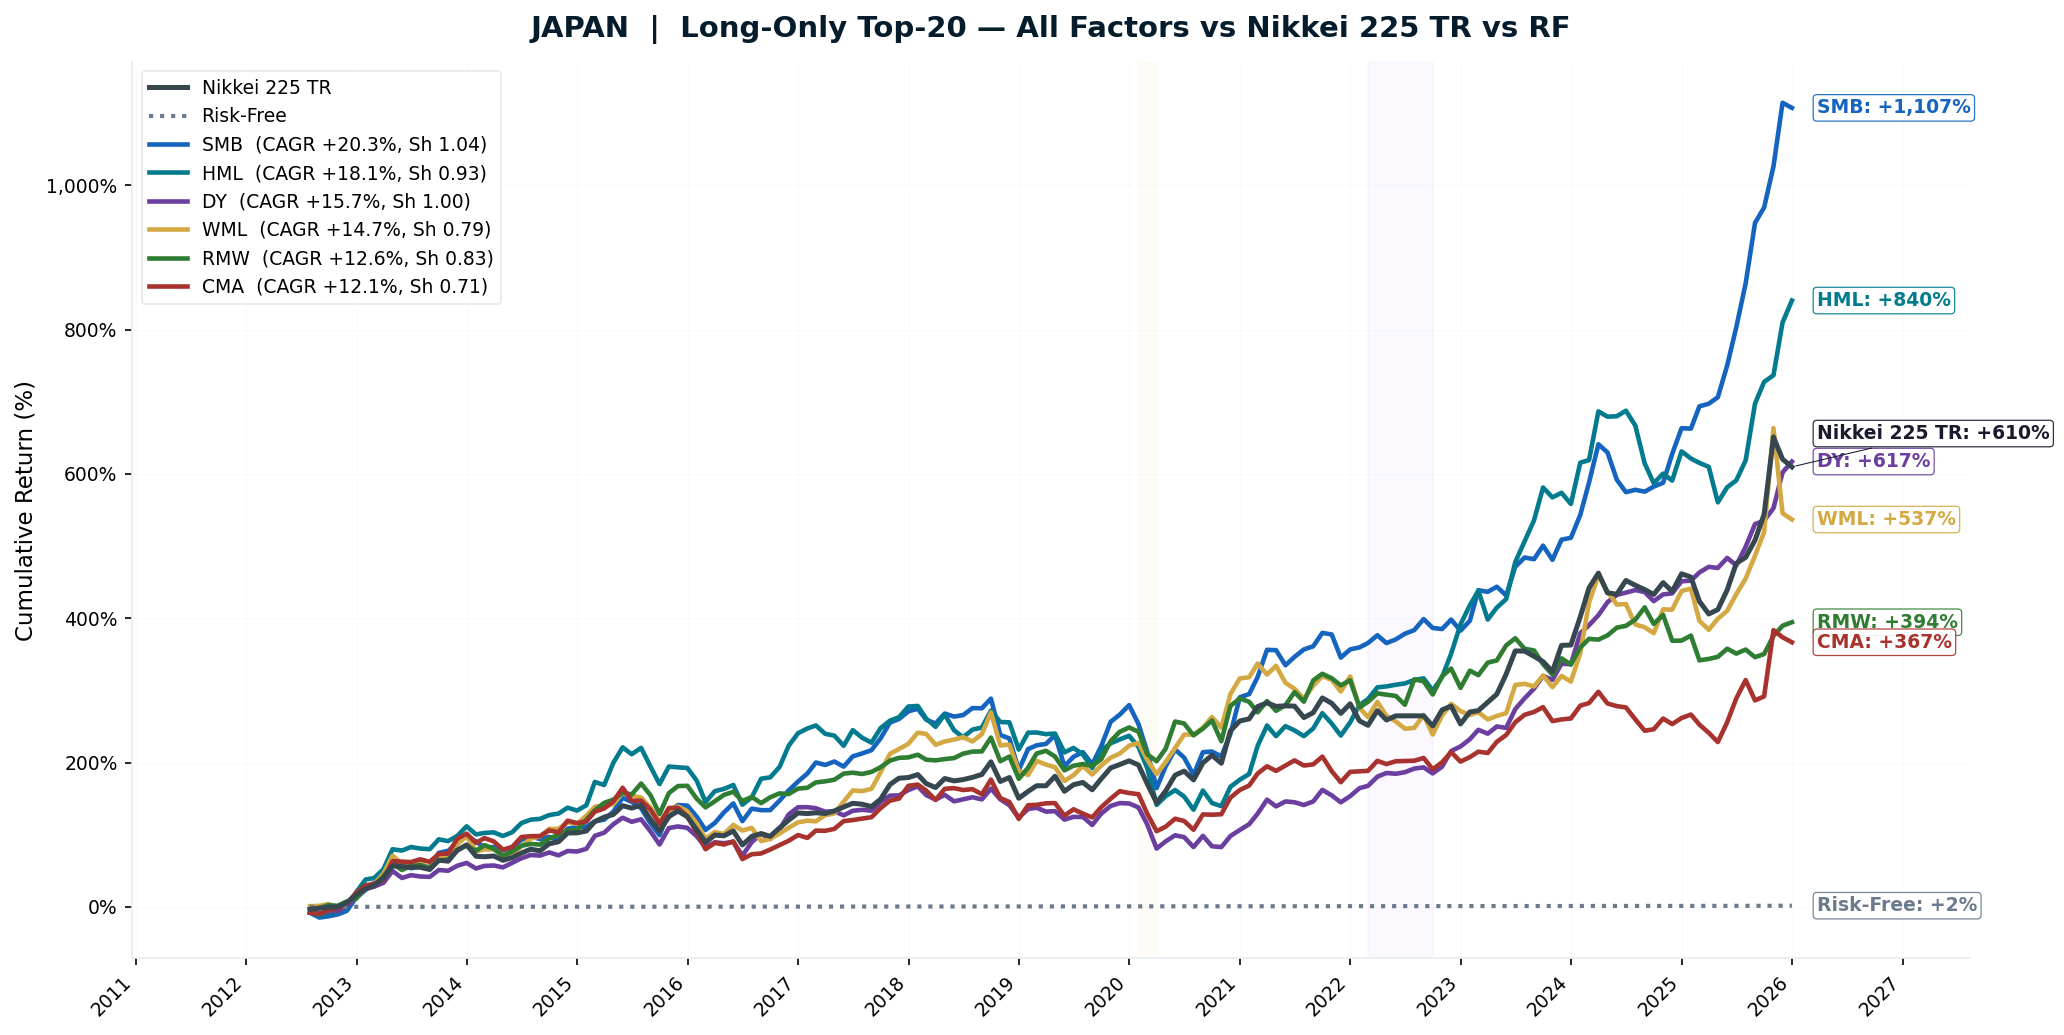

  -> /Users/dmitrijeremkin/Desktop/диплом созвон 5/output_factors/JP_LS_combined.png


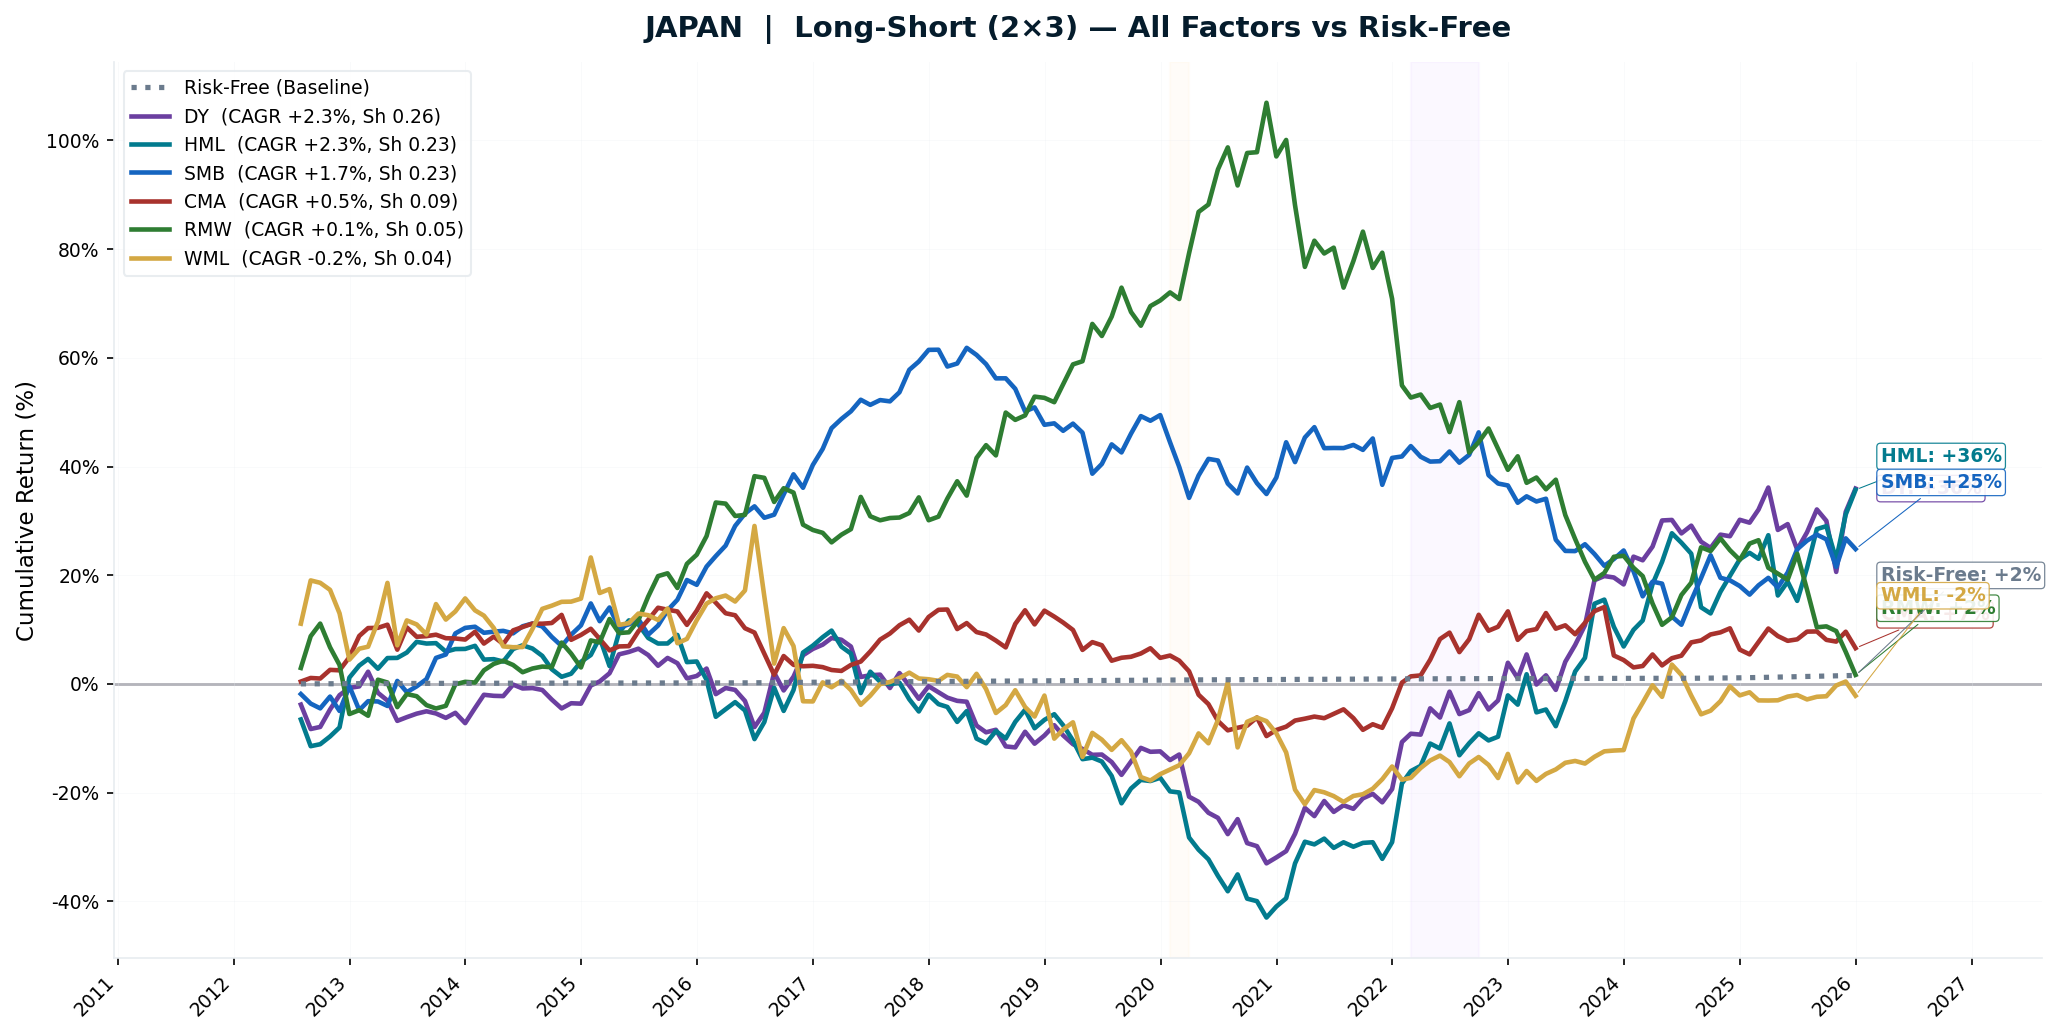

  -> /Users/dmitrijeremkin/Desktop/диплом созвон 5/output_factors/JP_individual_factors.png


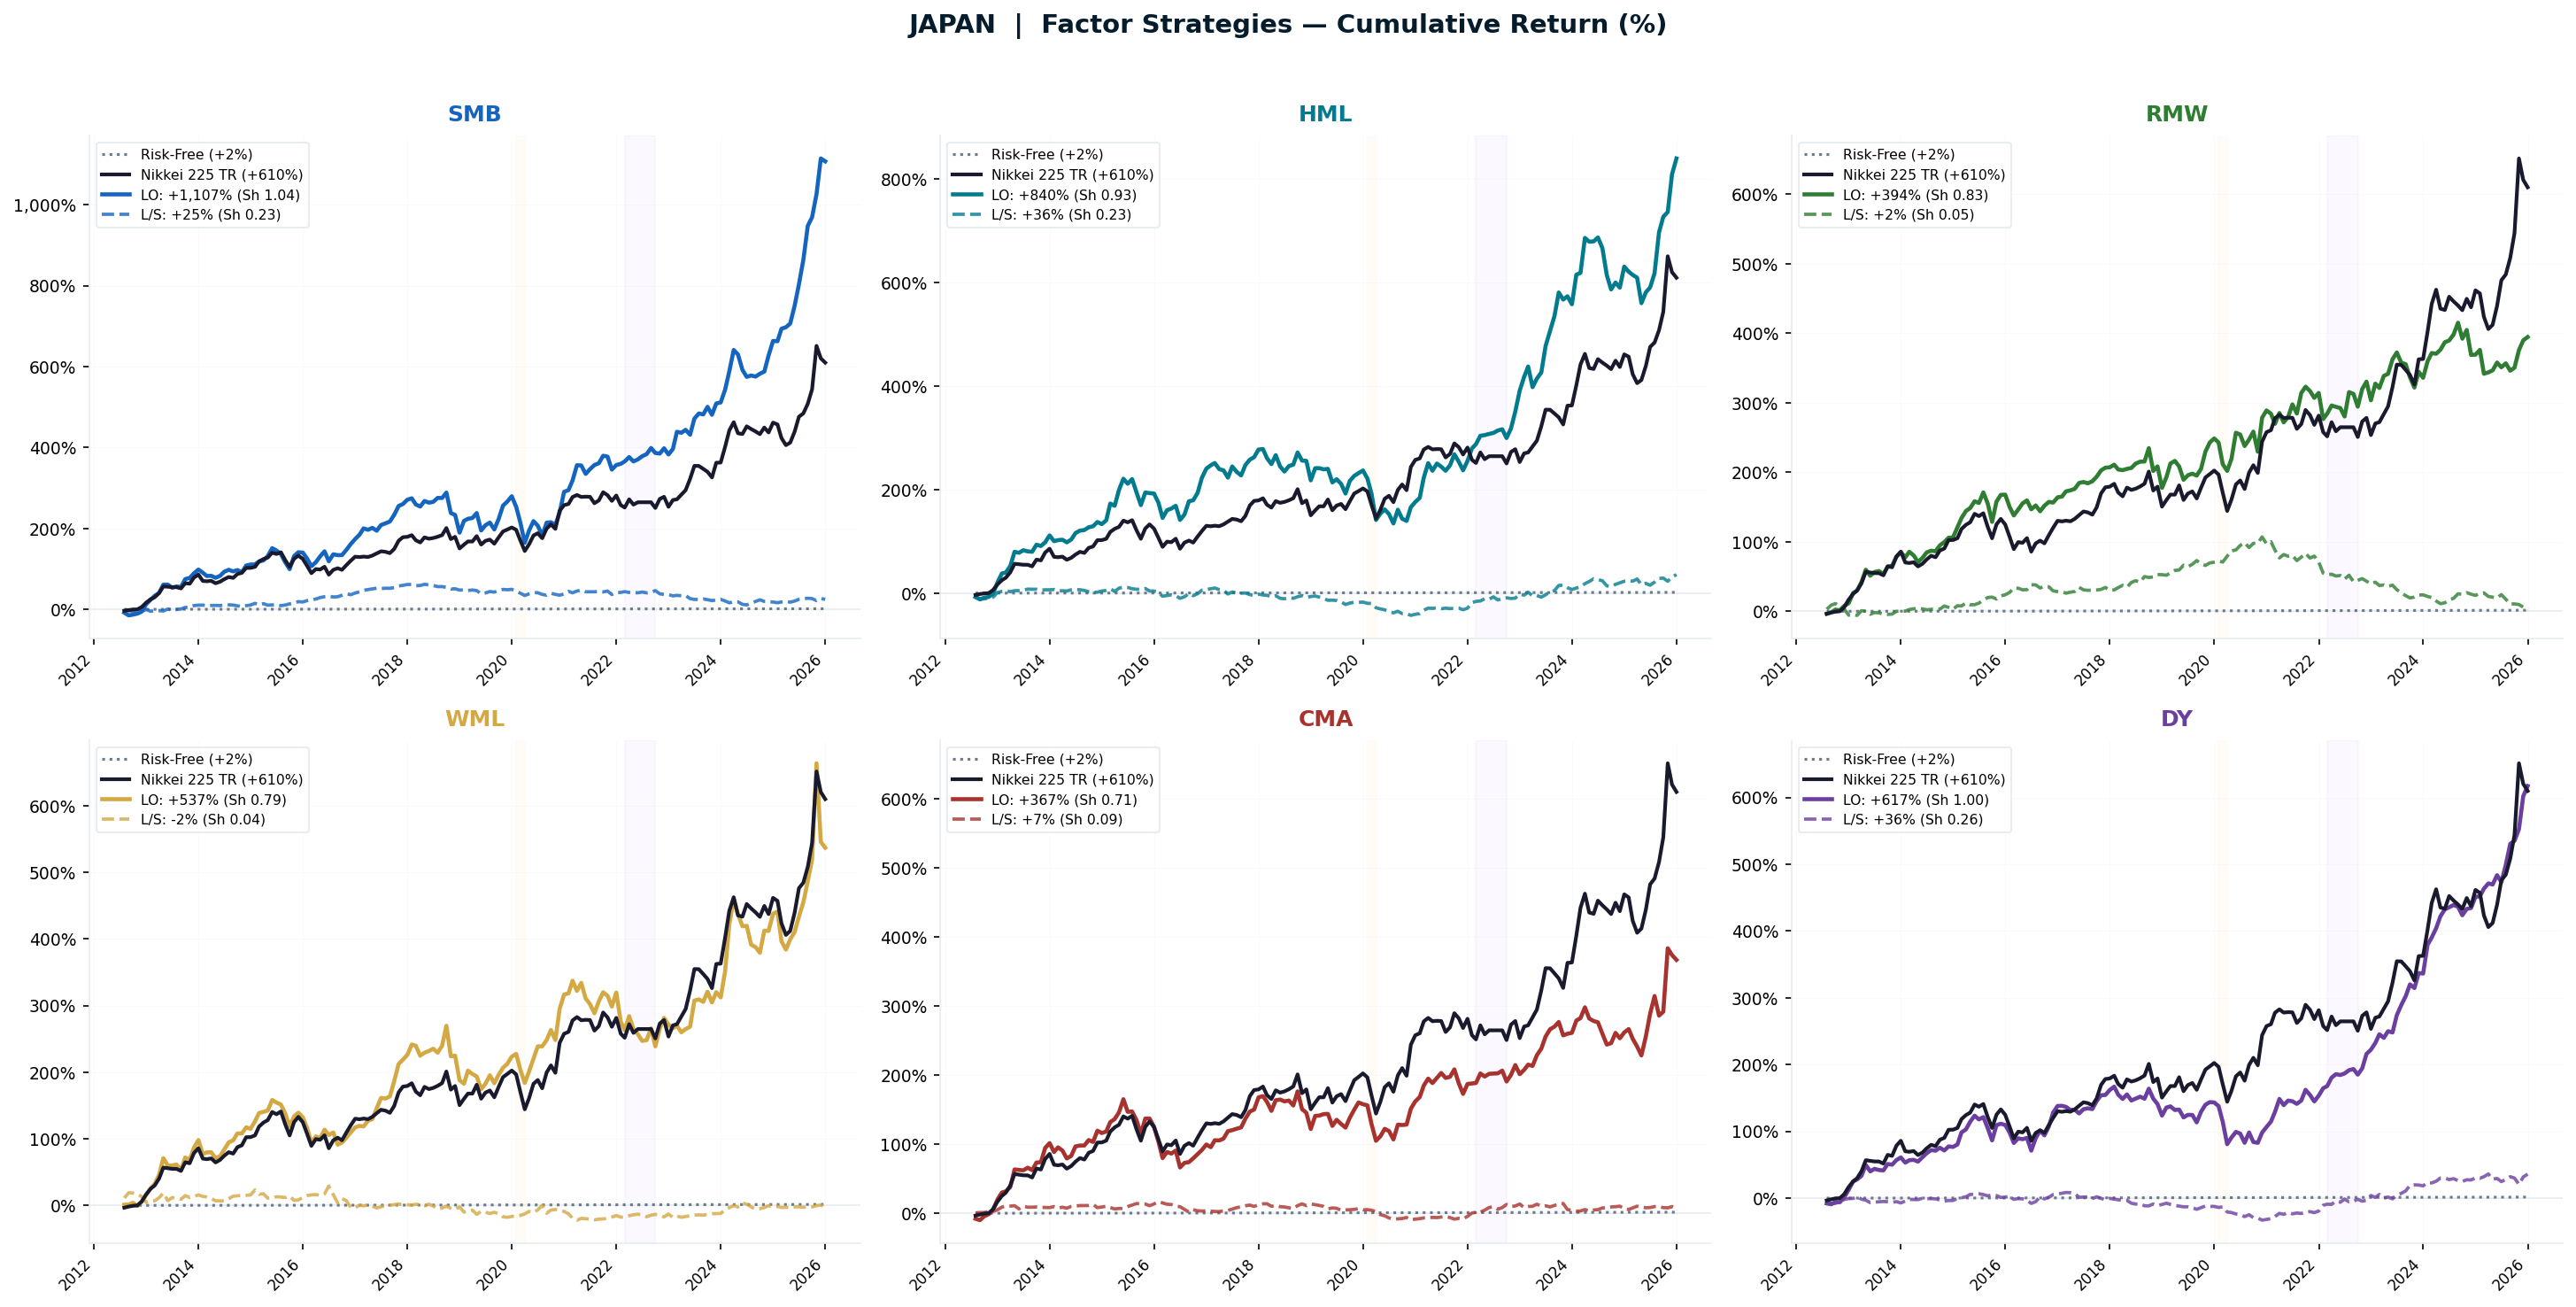

  -> /Users/dmitrijeremkin/Desktop/диплом созвон 5/output_factors/JP_fama_macbeth.png


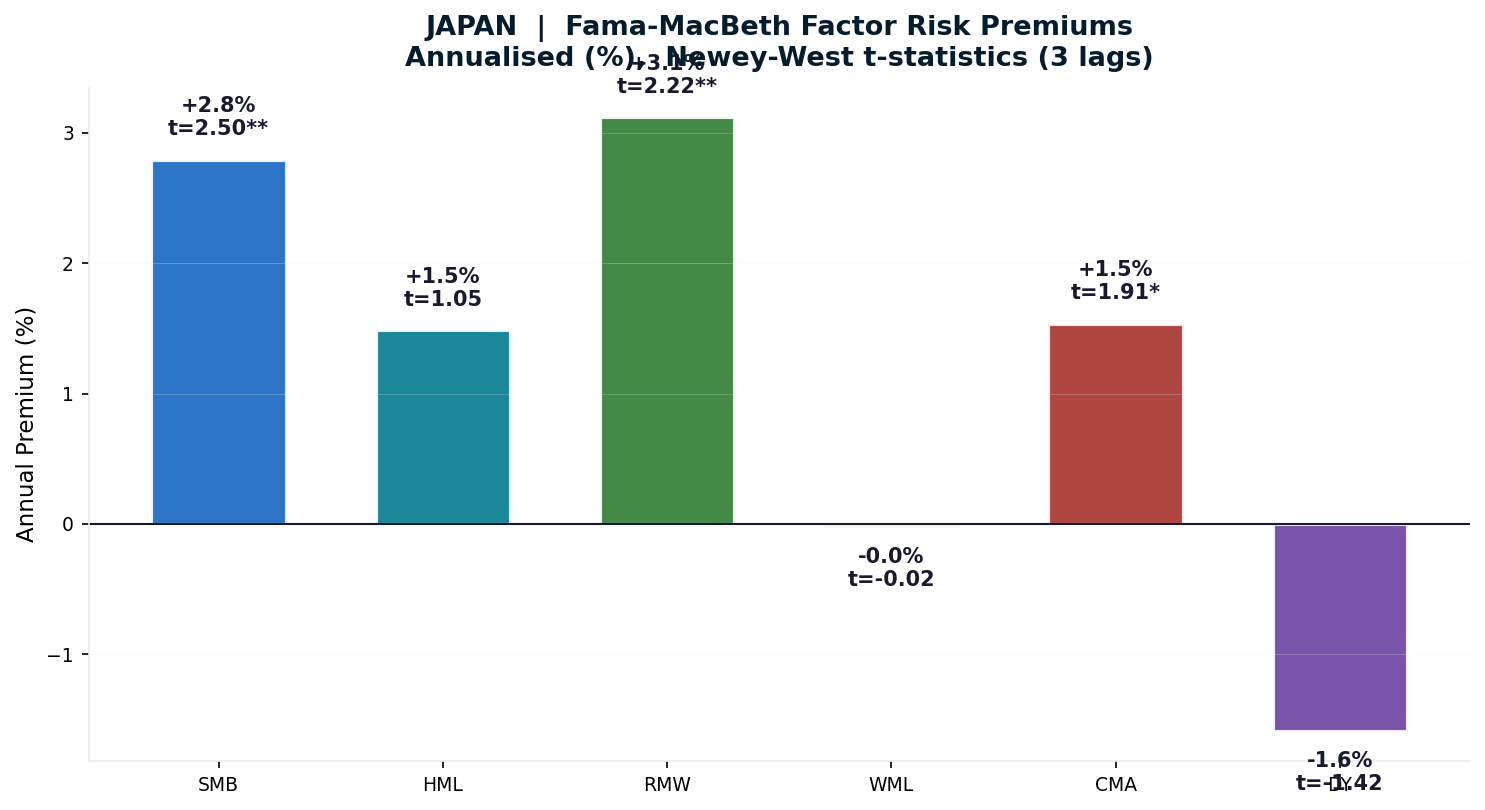

Strategy,Type,CAGR,Vol,Sharpe,MaxDD,HitRate,Cum
Nikkei 225 TR,Benchmark,15.6%,16.6%,0.95,-22.9%,60%,7.10x
SMB,Long-Only,20.8%,19.6%,1.06,-31.9%,67%,13.06x
DY,Long-Only,16.1%,15.9%,1.02,-32.3%,64%,7.56x
HML,Long-Only,18.6%,20.0%,0.95,-38.0%,64%,10.19x
RMW,Long-Only,12.8%,15.5%,0.85,-17.1%,66%,5.16x
WML,Long-Only,15.4%,19.7%,0.82,-26.0%,63%,6.97x
CMA,Long-Only,12.5%,18.4%,0.73,-37.3%,64%,4.97x
DY,Long-Short,2.2%,10.5%,0.25,-38.2%,52%,1.35x
HML,Long-Short,2.4%,13.4%,0.24,-49.0%,56%,1.38x
SMB,Long-Short,1.6%,7.8%,0.23,-31.5%,55%,1.24x



  -> Saved alpha tests to JP_alpha_tests.xlsx

  JAPAN BACKTEST COMPLETE

  CROSS-COUNTRY COMPARISON: RUSSIA vs JAPAN

  Fama-MacBeth Risk Premiums: Russia vs Japan
  Factor     Premium_RU     t_RU   Sig   Premium_JP     t_JP   Sig
  -----------------------------------------------------------------
  CMA           +0.54%     0.23            +1.54%     1.91     *
  DY            +0.52%     0.37            -1.59%    -1.42      
  HML           -1.59%    -0.26            +1.49%     1.05      
  RMW           +1.08%     0.55            +3.12%     2.22    **
  SMB           +5.46%     1.68     *      +2.79%     2.50    **
  WML           +3.02%     1.74     *      -0.02%    -0.02      


,Factor,mean_annual_RU,t_stat_RU,sig_RU,mean_annual_JP,t_stat_JP,sig_JP
0,CMA,0.54%,0.23,,1.54%,1.91,*
1,DY,0.52%,0.37,,-1.59%,-1.42,
2,HML,-1.59%,-0.26,,1.49%,1.05,
3,RMW,1.08%,0.55,,3.12%,2.22,**
4,SMB,5.46%,1.68,*,2.79%,2.50,**
5,WML,3.02%,1.74,*,-0.02%,-0.02,



  Alpha vs Risk-Free: Russia (RUONIA) vs Japan (T-Bill)
  Factor   Type               α_RU    t_RU       α_JP    t_JP   Winner
  ---------------------------------------------------------------------------
  CMA      LO              -0.50%   -0.08    +13.41%    2.62       JP
  DY       LO              +5.28%    0.87    +16.13%    3.51       JP
  HML      LO              +2.12%    0.30    +19.05%    3.06       JP
  RMW      LO              -3.13%   -0.58    +13.22%    3.45       JP
  SMB      LO             +13.19%    1.58    +20.85%    3.69       JP
  WML      LO              +2.15%    0.30    +16.17%    3.01       JP
  CMA      L/S            -10.74%   -2.59     +0.58%    0.31       JP
  DY       L/S             -8.43%   -1.85     +2.66%    0.93       JP
  HML      L/S            -11.95%   -2.82     +3.17%    0.80       JP
  RMW      L/S             -9.71%   -2.48     +0.15%    0.05       JP
  SMB      L/S             -5.78%   -1.14     +1.77%    0.88       JP
  WML      L/S          

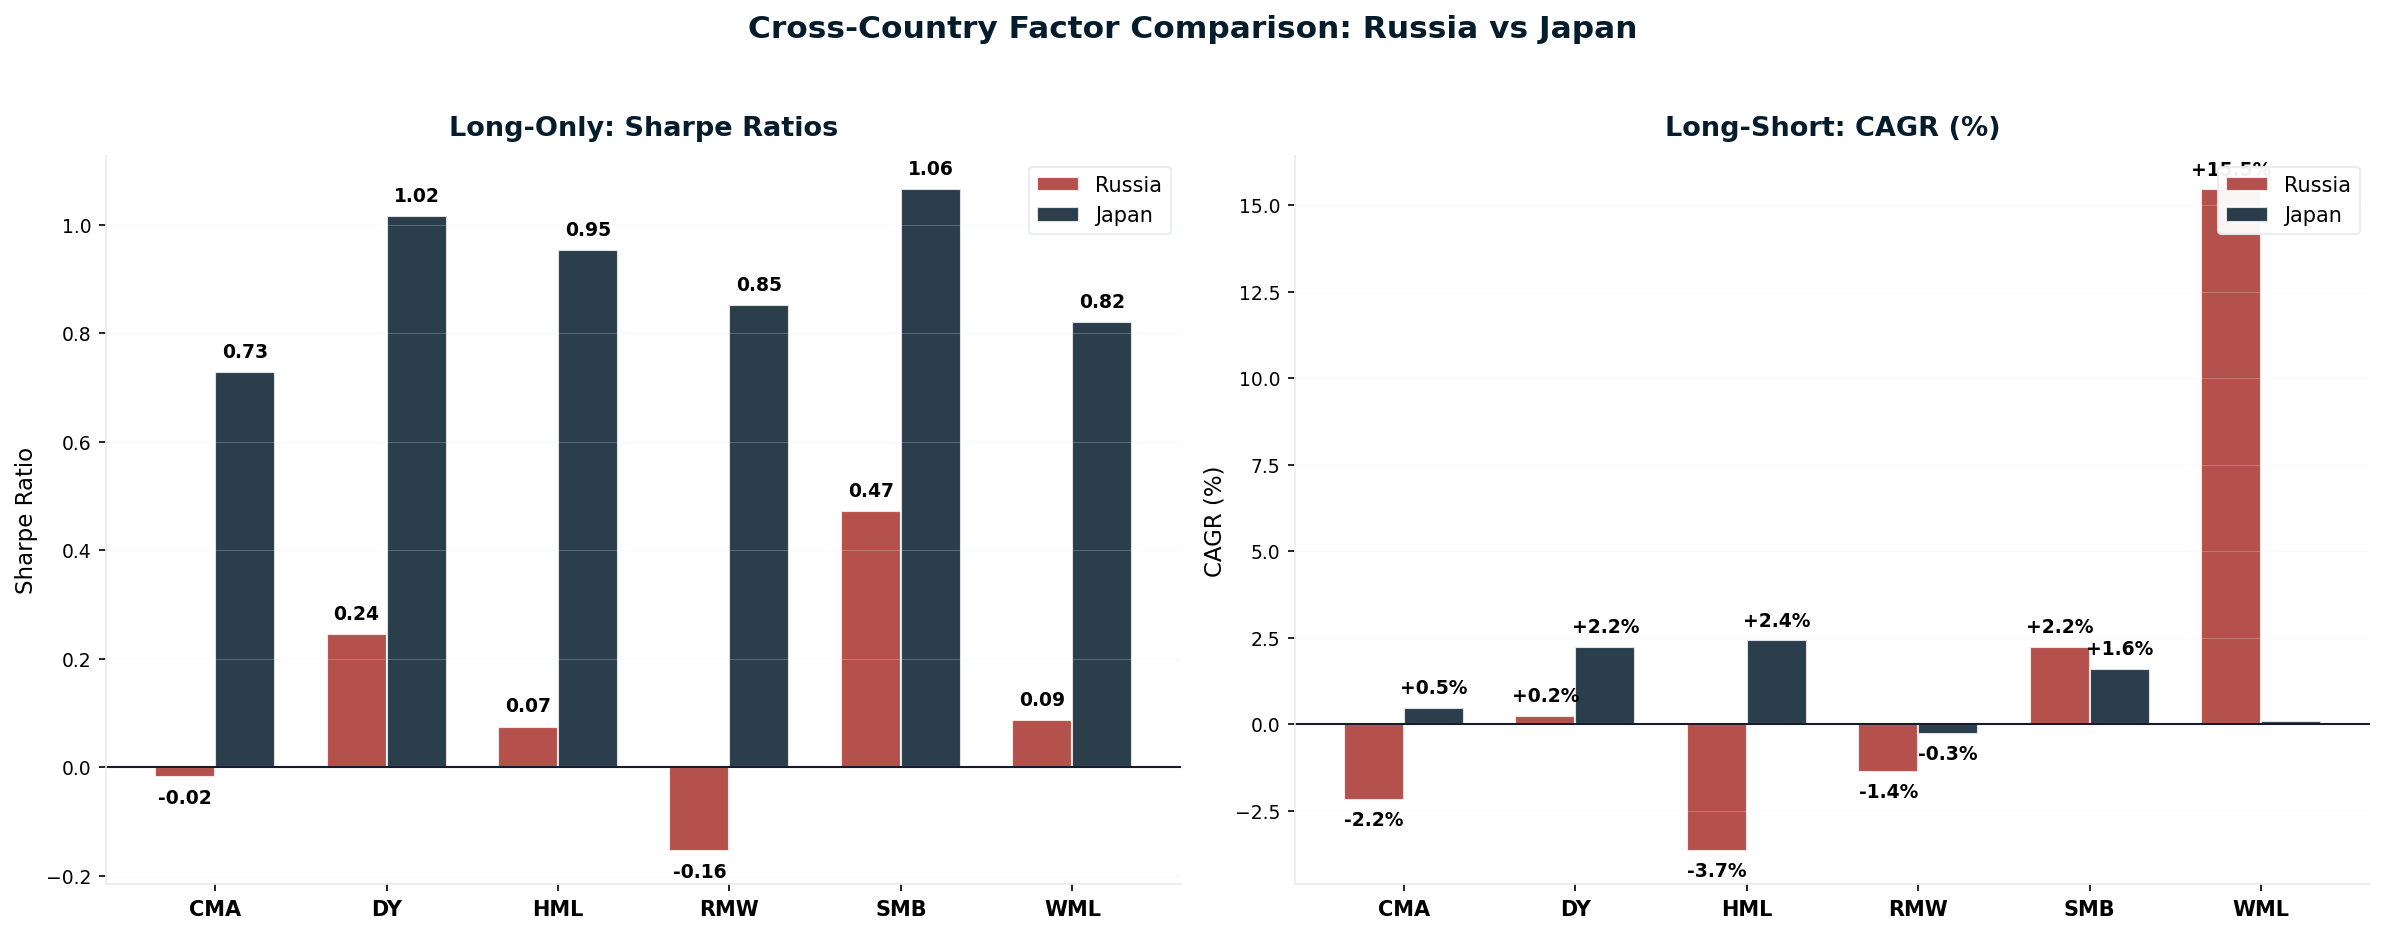


  Saving cross-country results...

  Cross-Country Performance Summary:


Country,Strategy,Type,CAGR,Vol,Sharpe,MaxDD,HitRate,Cum
Russia,MCFTR,Benchmark,11.5%,20.2%,0.18,-51.3%,66%,4.40x
Russia,SMB,Long-Only,20.7%,27.8%,0.47,-39.8%,57%,12.45x
Russia,DY,Long-Only,13.6%,21.4%,0.24,-50.2%,62%,4.49x
Russia,WML,Long-Only,8.7%,24.7%,0.09,-48.7%,59%,3.15x
Russia,HML,Long-Only,7.6%,28.4%,0.07,-40.8%,56%,2.75x
Russia,CMA,Long-Only,5.8%,26.2%,-0.02,-44.8%,59%,2.05x
Russia,RMW,Long-Only,4.3%,19.9%,-0.16,-52.7%,60%,1.79x
Russia,WML,Long-Short,15.5%,16.8%,0.38,-33.2%,60%,7.22x
Russia,SMB,Long-Short,2.2%,16.7%,-0.35,-52.0%,50%,1.36x
Russia,DY,Long-Short,0.2%,15.5%,-0.54,-39.1%,59%,1.03x



  -> Saved to /Users/dmitrijeremkin/Desktop/диплом созвон 5/output_factors/cross_country_metrics.xlsx

  ALL BACKTESTS COMPLETE


In [3]:
# ═══════════════════════════════════════════════════════════════════
# MAIN EXECUTION — JAPAN
# ═══════════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("  RUNNING FACTOR BACKTEST — JAPAN")
print("=" * 65)

cfg_j = cfg_jp()
dm_j = DataManager(cfg_j)
dm_j.load()

print("\n  Computing factor signals...")
panel_j, sig_cols_j = compute_signals(dm_j.panel, cfg_j)

# ── Long-Only Top-20 ──────────────────────────────────────────────
print("\n  Long-Only Top-20:")
lo_j = {}
for sig in sig_cols_j:
    fn = sig.replace('sig_', '')
    r = run_longonly(panel_j, dm_j.prices, cfg_j, sig, top_n=cfg_j.top_n, factor_label=fn)
    lo_j[sig] = r
    if r is not None:
        m = metrics(r, dm_j.rf)
        print(f"    {fn:12s} | CAGR={m['CAGR']:+.1%} | Sh={m['Sharpe']:+.2f} "
              f"| MaxDD={m['MaxDD']:.1%} | {len(r)} m")

# ── Long-Short 2x3 ────────────────────────────────────────────────
print("\n  Long-Short 2x3:")
ls_j = {}
ls_p_j = {}
# FIX: sig_SMB instead of sig_Size
size_sig_j = 'sig_SMB' if 'sig_SMB' in sig_cols_j else sig_cols_j[0]
for sig in sig_cols_j:
    fn = sig.replace('sig_', '')
    ctrl = size_sig_j if sig != size_sig_j else next((s for s in sig_cols_j if s != sig), sig)
    ls, ps = run_longshort_2x3(panel_j, dm_j.prices, cfg_j, sig, ctrl, fn)
    ls_j[sig] = ls
    ls_p_j[sig] = ps
    if ls is not None:
        m = metrics(ls, dm_j.rf)
        print(f"    {fn:12s} | CAGR={m['CAGR']:+.1%} | Sh={m['Sharpe']:+.2f} "
              f"| MaxDD={m['MaxDD']:.1%} | {len(ls)} m")

# ── Alpha Tests vs Risk-Free ──────────────────────────────────────
print("\n  Testing Alpha vs Risk-Free Rate...")
alpha_lo_j = test_alpha_vs_rf(lo_j, dm_j.rf, 'Long-Only')
alpha_ls_j = test_alpha_vs_rf(ls_j, dm_j.rf, 'Long-Short')

display_alpha(alpha_lo_j, "JAPAN — Long-Only Alpha Test vs JGB T-Bill")
display_alpha(alpha_ls_j, "JAPAN — Long-Short Alpha Test vs JGB T-Bill")

# ── Fama-MacBeth ──────────────────────────────────────────────────
print("\n  Fama-MacBeth:")
fm_j, fm_ts_j = run_fama_macbeth(panel_j, dm_j.prices, cfg_j, sig_cols_j)
display_fm(fm_j, "JAPAN — Fama-MacBeth Risk Premiums")

# ── Japan Plots ───────────────────────────────────────────────────
bm_start_j = pd.Timestamp(cfg_j.start_year, cfg_j.rebalance_month, 1)
bm_j = dm_j.benchmark[dm_j.benchmark.index >= bm_start_j]

plot_combined(lo_j, ls_j, bm_j, dm_j.rf, cfg_j, mode='LO')
plot_combined(lo_j, ls_j, bm_j, dm_j.rf, cfg_j, mode='LS')
plot_individual_factors(lo_j, ls_j, bm_j, dm_j.rf, cfg_j)
plot_fm(fm_j, cfg_j)

# ── Metrics Table ─────────────────────────────────────────────────
tbl_j = metrics_table(lo_j, ls_j, bm_j, dm_j.rf, cfg_j)
display_metrics(tbl_j, "JAPAN — Performance Summary")

# ── Save Alpha Test Results ───────────────────────────────────────
if alpha_lo_j is not None and len(alpha_lo_j) > 0:
    alpha_combined_j = pd.concat([alpha_lo_j, alpha_ls_j], ignore_index=True)
    alpha_combined_j.to_excel(os.path.join(OUT, f'{cfg_j.country}_alpha_tests.xlsx'), index=False)
    print(f"\n  -> Saved alpha tests to {cfg_j.country}_alpha_tests.xlsx")

print("\n" + "=" * 65)
print("  JAPAN BACKTEST COMPLETE")
print("=" * 65)

# ═══════════════════════════════════════════════════════════════════
# CROSS-COUNTRY COMPARISON — RUSSIA vs JAPAN
# ═══════════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("  CROSS-COUNTRY COMPARISON: RUSSIA vs JAPAN")
print("=" * 65)

# ── 1. Fama-MacBeth Comparison ────────────────────────────────────
if fm_r is not None and fm_j is not None:
    fm_comp = pd.merge(
        fm_r[fm_r['Factor'] != 'intercept'][['Factor', 'mean_annual', 't_stat', 'sig']],
        fm_j[fm_j['Factor'] != 'intercept'][['Factor', 'mean_annual', 't_stat', 'sig']],
        on='Factor', suffixes=('_RU', '_JP'), how='outer'
    ).sort_values('Factor')

    print("\n  Fama-MacBeth Risk Premiums: Russia vs Japan")
    print("  " + "=" * 65)
    print(f"  {'Factor':<8} {'Premium_RU':>12} {'t_RU':>8} {'Sig':>5} {'Premium_JP':>12} {'t_JP':>8} {'Sig':>5}")
    print("  " + "-" * 65)
    for _, row in fm_comp.iterrows():
        print(f"  {row['Factor']:<8} "
              f"{row.get('mean_annual_RU', np.nan):>+11.2%}  "
              f"{row.get('t_stat_RU', np.nan):>7.2f}  "
              f"{str(row.get('sig_RU', '')):>4} "
              f"{row.get('mean_annual_JP', np.nan):>+11.2%}  "
              f"{row.get('t_stat_JP', np.nan):>7.2f}  "
              f"{str(row.get('sig_JP', '')):>4}")
    print("  " + "=" * 65)

    try:
        display(fm_comp.style.format(
            {'mean_annual_RU': '{:.2%}', 'mean_annual_JP': '{:.2%}',
             't_stat_RU': '{:.2f}', 't_stat_JP': '{:.2f}'}, na_rep='-')
            .background_gradient(subset=['mean_annual_RU', 'mean_annual_JP'],
                                 cmap='RdYlGn', vmin=-0.05, vmax=0.15))
    except:
        pass

# ── 2. Alpha Tests Comparison ─────────────────────────────────────
print("\n  Alpha vs Risk-Free: Russia (RUONIA) vs Japan (T-Bill)")
print("  " + "=" * 75)
print(f"  {'Factor':<8} {'Type':<12} {'α_RU':>10} {'t_RU':>7} {'α_JP':>10} {'t_JP':>7} {'Winner':>8}")
print("  " + "-" * 75)

# Merge LO alpha tests
if alpha_lo is not None and len(alpha_lo) > 0 and alpha_lo_j is not None and len(alpha_lo_j) > 0:
    alpha_lo_comp = pd.merge(
        alpha_lo[['Factor', 'Excess_Annual', 't_stat', 'Sig']],
        alpha_lo_j[['Factor', 'Excess_Annual', 't_stat', 'Sig']],
        on='Factor', suffixes=('_RU', '_JP'), how='outer')

    for _, row in alpha_lo_comp.iterrows():
        ru_a = row.get('Excess_Annual_RU', np.nan)
        jp_a = row.get('Excess_Annual_JP', np.nan)
        winner = 'RU' if (not np.isnan(ru_a) and (np.isnan(jp_a) or ru_a > jp_a)) else 'JP'
        print(f"  {row['Factor']:<8} {'LO':<12} "
              f"{ru_a:>+9.2%}  {row.get('t_stat_RU', np.nan):>6.2f}  "
              f"{jp_a:>+9.2%}  {row.get('t_stat_JP', np.nan):>6.2f}  "
              f"{winner:>7}")

# Merge LS alpha tests
if alpha_ls is not None and len(alpha_ls) > 0 and alpha_ls_j is not None and len(alpha_ls_j) > 0:
    alpha_ls_comp = pd.merge(
        alpha_ls[['Factor', 'Excess_Annual', 't_stat', 'Sig']],
        alpha_ls_j[['Factor', 'Excess_Annual', 't_stat', 'Sig']],
        on='Factor', suffixes=('_RU', '_JP'), how='outer')

    for _, row in alpha_ls_comp.iterrows():
        ru_a = row.get('Excess_Annual_RU', np.nan)
        jp_a = row.get('Excess_Annual_JP', np.nan)
        winner = 'RU' if (not np.isnan(ru_a) and (np.isnan(jp_a) or ru_a > jp_a)) else 'JP'
        print(f"  {row['Factor']:<8} {'L/S':<12} "
              f"{ru_a:>+9.2%}  {row.get('t_stat_RU', np.nan):>6.2f}  "
              f"{jp_a:>+9.2%}  {row.get('t_stat_JP', np.nan):>6.2f}  "
              f"{winner:>7}")

print("  " + "=" * 75)

# ── 3. Combined Performance Chart ─────────────────────────────────
def plot_cross_country(lo_r, lo_j, ls_r, ls_j, cfg_r, cfg_j, save=True):
    """Side-by-side factor comparison: Russia vs Japan."""
    factors = sorted(set(
        [k.replace('sig_', '') for k, v in lo_r.items() if v is not None] +
        [k.replace('sig_', '') for k, v in lo_j.items() if v is not None]))

    if len(factors) == 0:
        print("  No cross-country data to plot.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # ── Panel A: Long-Only Sharpe Ratios ──
    ax = axes[0]
    x = np.arange(len(factors))
    width = 0.35

    ru_sharpes = []
    jp_sharpes = []
    for f in factors:
        sig = f'sig_{f}'
        # Russia
        r_ru = lo_r.get(sig)
        if r_ru is not None:
            m = metrics(r_ru, dm_r.rf)
            ru_sharpes.append(m['Sharpe'])
        else:
            ru_sharpes.append(0)
        # Japan
        r_jp = lo_j.get(sig)
        if r_jp is not None:
            m = metrics(r_jp, dm_j.rf)
            jp_sharpes.append(m['Sharpe'])
        else:
            jp_sharpes.append(0)

    bars1 = ax.bar(x - width / 2, ru_sharpes, width, label='Russia',
                   color=MCKINSEY_RED, alpha=0.85, edgecolor='white')
    bars2 = ax.bar(x + width / 2, jp_sharpes, width, label='Japan',
                   color=MCKINSEY_NAVY, alpha=0.85, edgecolor='white')

    # Value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            h = bar.get_height()
            if abs(h) > 0.01:
                ax.text(bar.get_x() + bar.get_width() / 2, h + 0.02 * (1 if h >= 0 else -1),
                        f'{h:.2f}', ha='center', va='bottom' if h >= 0 else 'top',
                        fontsize=9, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(factors, fontsize=10, fontweight='bold')
    ax.axhline(0, color=MCKINSEY_BLACK, lw=1)
    ax.set_title('Long-Only: Sharpe Ratios', fontsize=13, fontweight='bold',
                 color=MCKINSEY_NAVY, pad=10)
    ax.set_ylabel('Sharpe Ratio', fontsize=11)
    ax.legend(fontsize=10, loc='upper right')
    ax.grid(axis='y', alpha=0.3)

    # ── Panel B: Long-Short CAGR ──
    ax = axes[1]

    ru_cagrs = []
    jp_cagrs = []
    for f in factors:
        sig = f'sig_{f}'
        r_ru = ls_r.get(sig)
        if r_ru is not None:
            m = metrics(r_ru, dm_r.rf)
            ru_cagrs.append(m['CAGR'] * 100)
        else:
            ru_cagrs.append(0)
        r_jp = ls_j.get(sig)
        if r_jp is not None:
            m = metrics(r_jp, dm_j.rf)
            jp_cagrs.append(m['CAGR'] * 100)
        else:
            jp_cagrs.append(0)

    bars1 = ax.bar(x - width / 2, ru_cagrs, width, label='Russia',
                   color=MCKINSEY_RED, alpha=0.85, edgecolor='white')
    bars2 = ax.bar(x + width / 2, jp_cagrs, width, label='Japan',
                   color=MCKINSEY_NAVY, alpha=0.85, edgecolor='white')

    for bars in [bars1, bars2]:
        for bar in bars:
            h = bar.get_height()
            if abs(h) > 0.1:
                ax.text(bar.get_x() + bar.get_width() / 2, h + 0.3 * (1 if h >= 0 else -1),
                        f'{h:+.1f}%', ha='center', va='bottom' if h >= 0 else 'top',
                        fontsize=9, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(factors, fontsize=10, fontweight='bold')
    ax.axhline(0, color=MCKINSEY_BLACK, lw=1)
    ax.set_title('Long-Short: CAGR (%)', fontsize=13, fontweight='bold',
                 color=MCKINSEY_NAVY, pad=10)
    ax.set_ylabel('CAGR (%)', fontsize=11)
    ax.legend(fontsize=10, loc='upper right')
    ax.grid(axis='y', alpha=0.3)

    fig.suptitle('Cross-Country Factor Comparison: Russia vs Japan',
                 fontsize=15, fontweight='bold', color=MCKINSEY_NAVY, y=1.03)
    plt.tight_layout()
    if save:
        fn = os.path.join(OUT, 'cross_country_comparison.png')
        plt.savefig(fn, bbox_inches='tight', facecolor='white')
        print(f"  -> {fn}")
    plt.show()

# Run cross-country chart
plot_cross_country(lo_r, lo_j, ls_r, ls_j, cfg_r, cfg_j)

# ── 4. Save Cross-Country Tables ──────────────────────────────────
print("\n  Saving cross-country results...")

# Combined metrics table
tbl_r_labeled = tbl_r.copy()
tbl_r_labeled['Country'] = 'Russia'
tbl_j_labeled = tbl_j.copy()
tbl_j_labeled['Country'] = 'Japan'
tbl_combined = pd.concat([tbl_r_labeled, tbl_j_labeled], ignore_index=True)
tbl_combined = tbl_combined[['Country', 'Strategy', 'Type', 'CAGR', 'Vol', 'Sharpe',
                              'MaxDD', 'HitRate', 'Cum']]
tbl_combined.to_excel(os.path.join(OUT, 'cross_country_metrics.xlsx'), index=False)

print("\n  Cross-Country Performance Summary:")
display_metrics(tbl_combined, "Cross-Country Performance Summary")

print(f"\n  -> Saved to {OUT}/cross_country_metrics.xlsx")

print("\n" + "=" * 65)
print("  ALL BACKTESTS COMPLETE")
print("=" * 65)


  ADDITIONAL ANALYSIS

─── RUSSIA ──────────────────────────────────────────────────
  -> /Users/dmitrijeremkin/Desktop/диплом созвон 5/output_factors/RF_rolling_sharpe.png


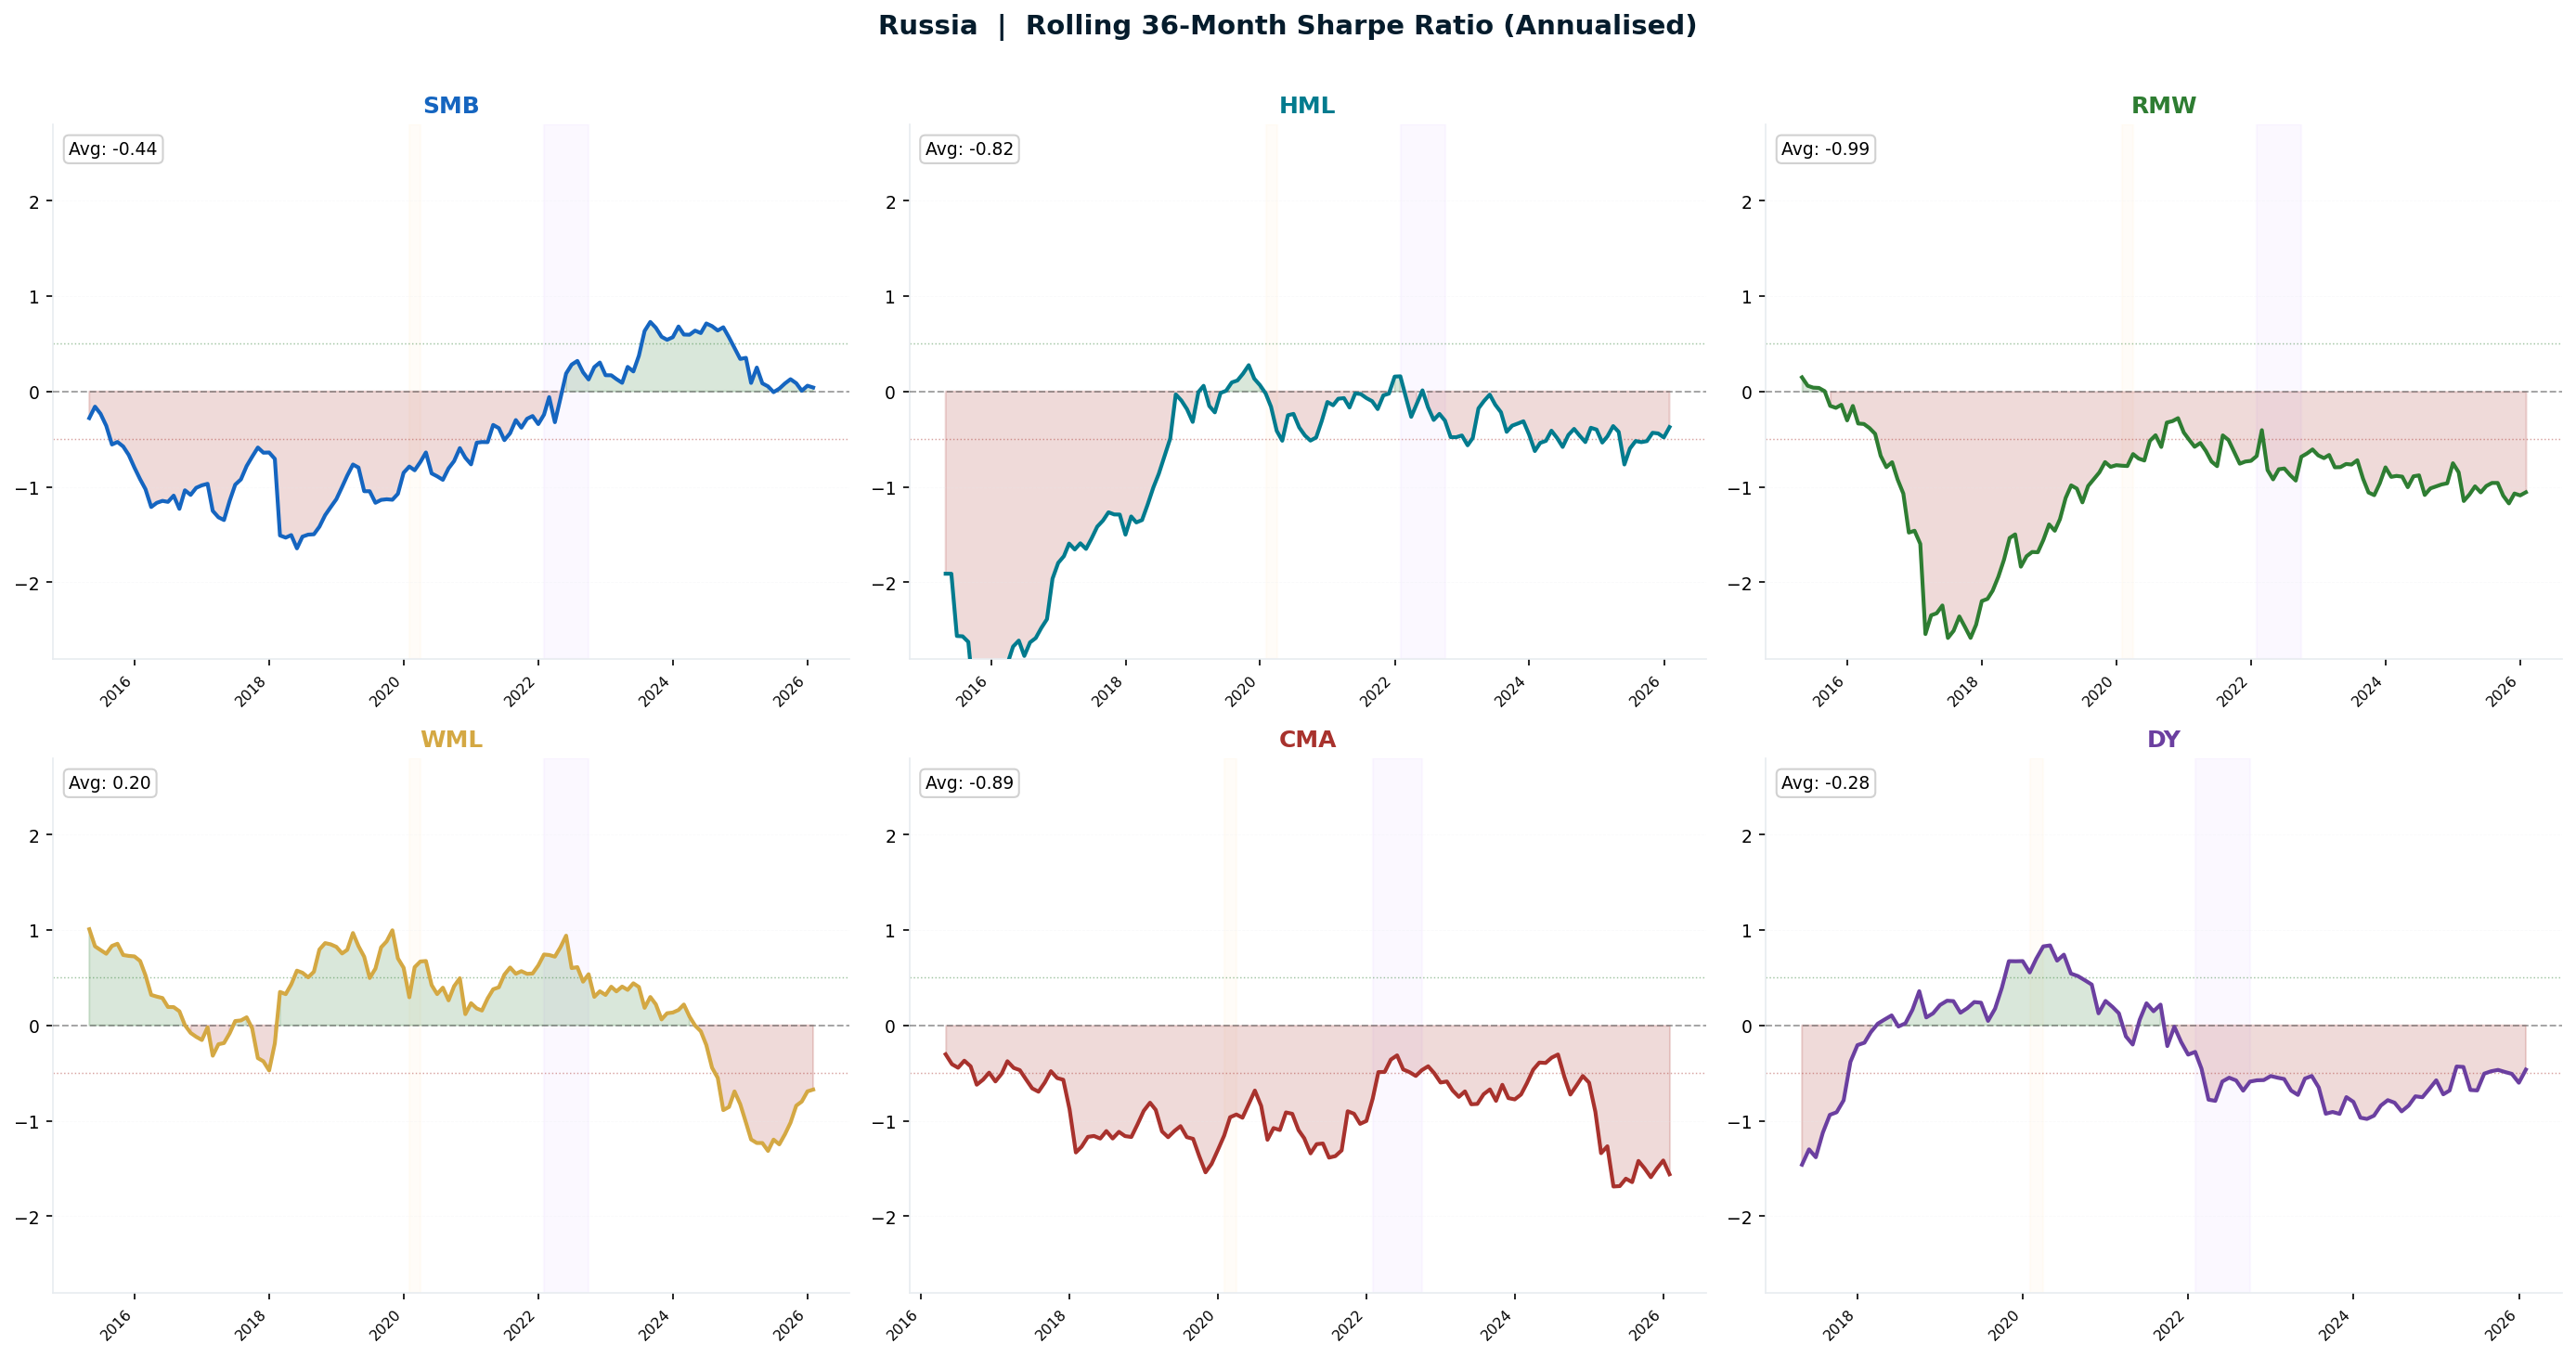

  -> /Users/dmitrijeremkin/Desktop/диплом созвон 5/output_factors/RF_drawdowns.png


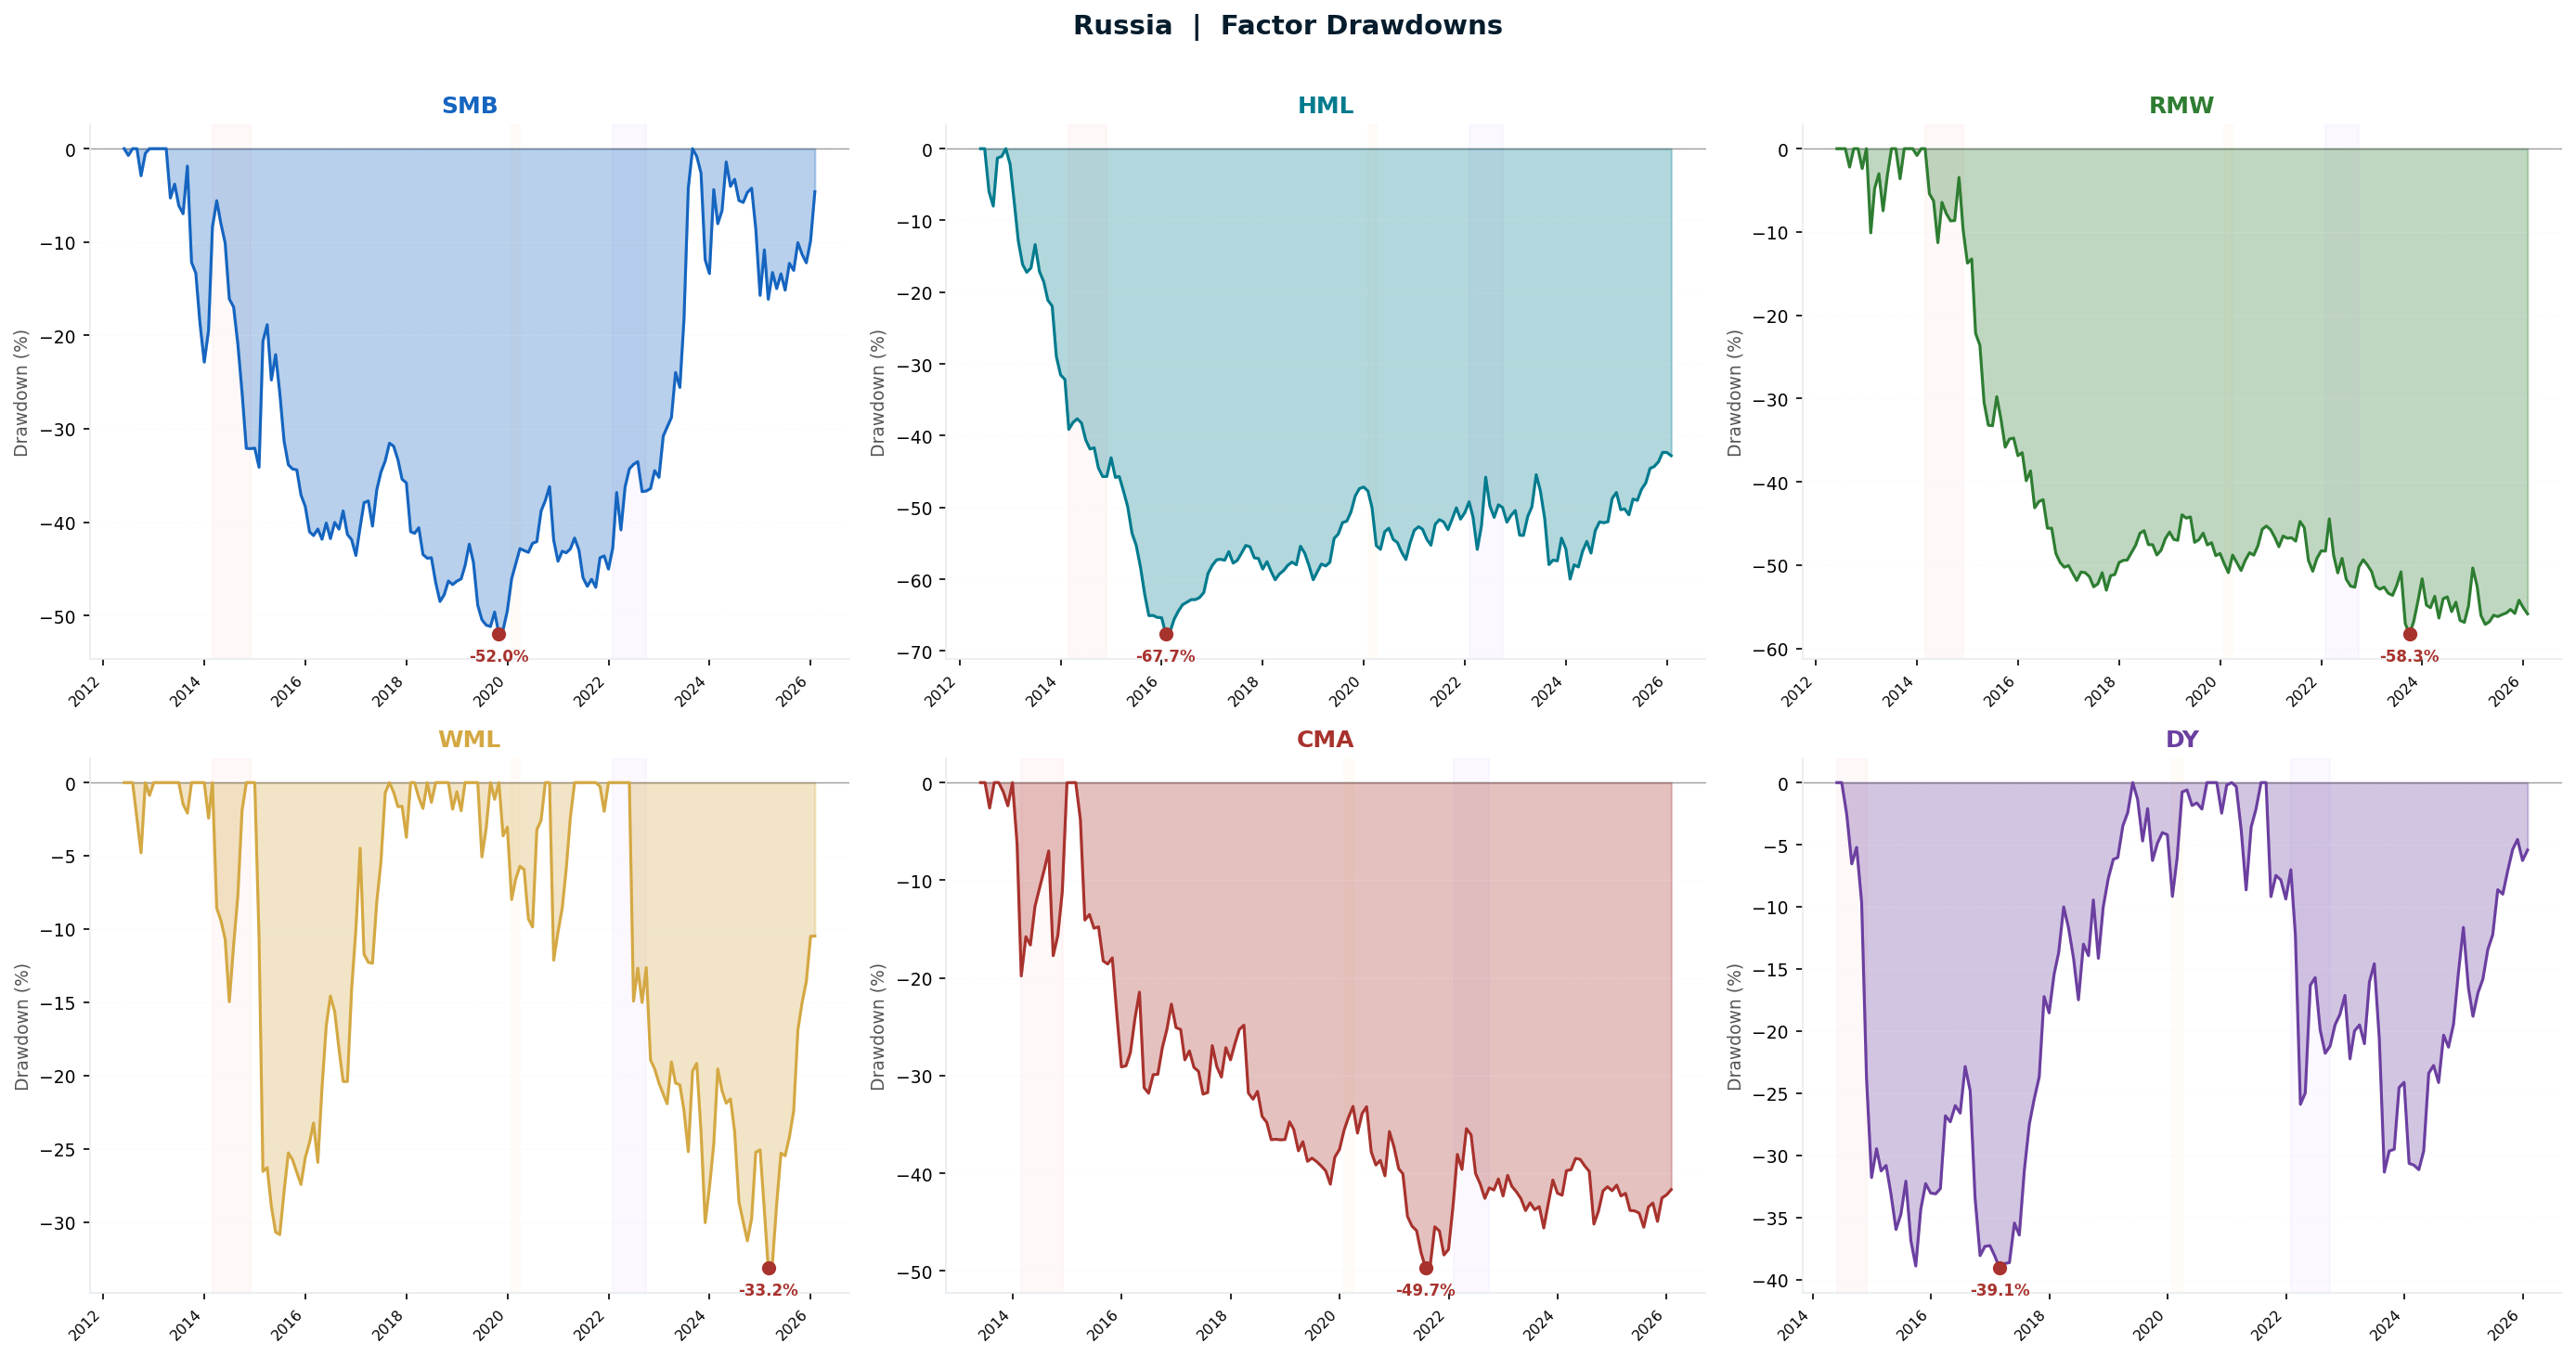

  -> /Users/dmitrijeremkin/Desktop/диплом созвон 5/output_factors/RF_annual_heatmap.png


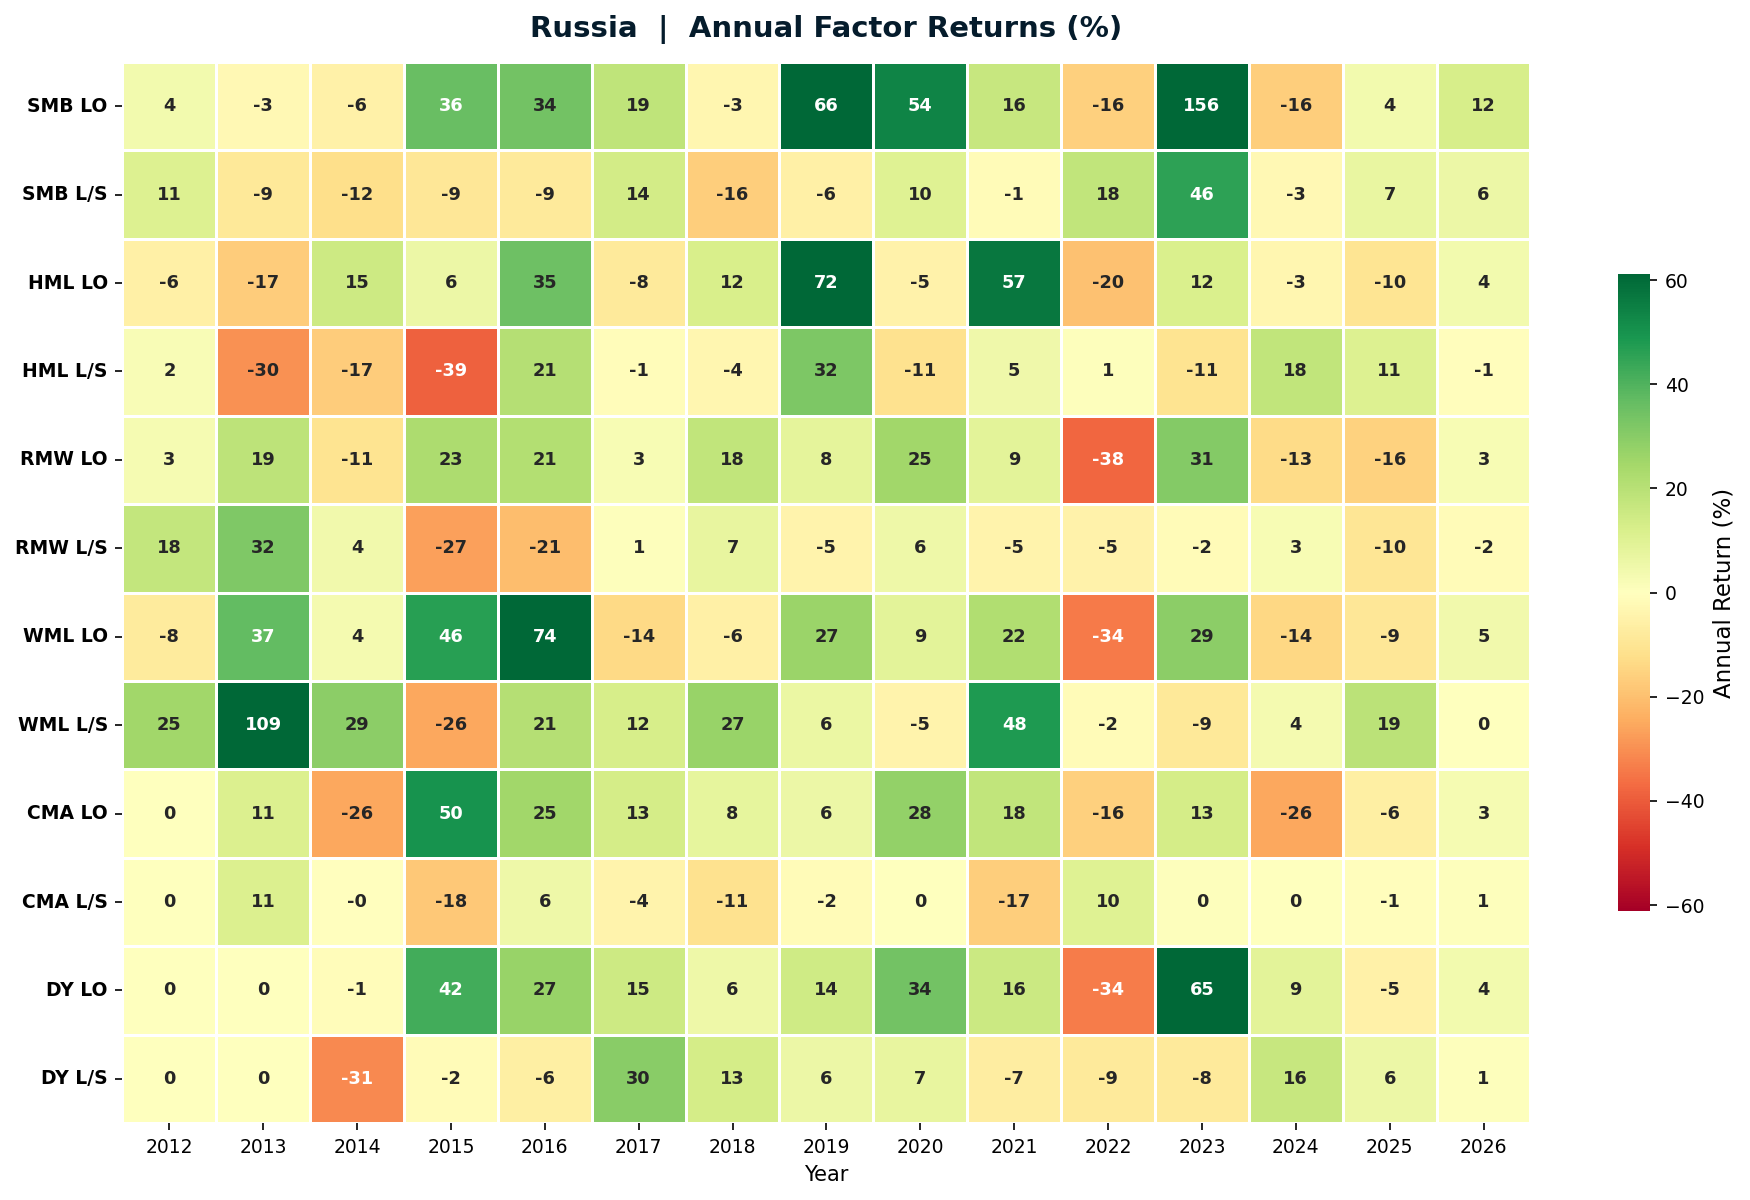

  -> /Users/dmitrijeremkin/Desktop/диплом созвон 5/output_factors/RF_correlations.png


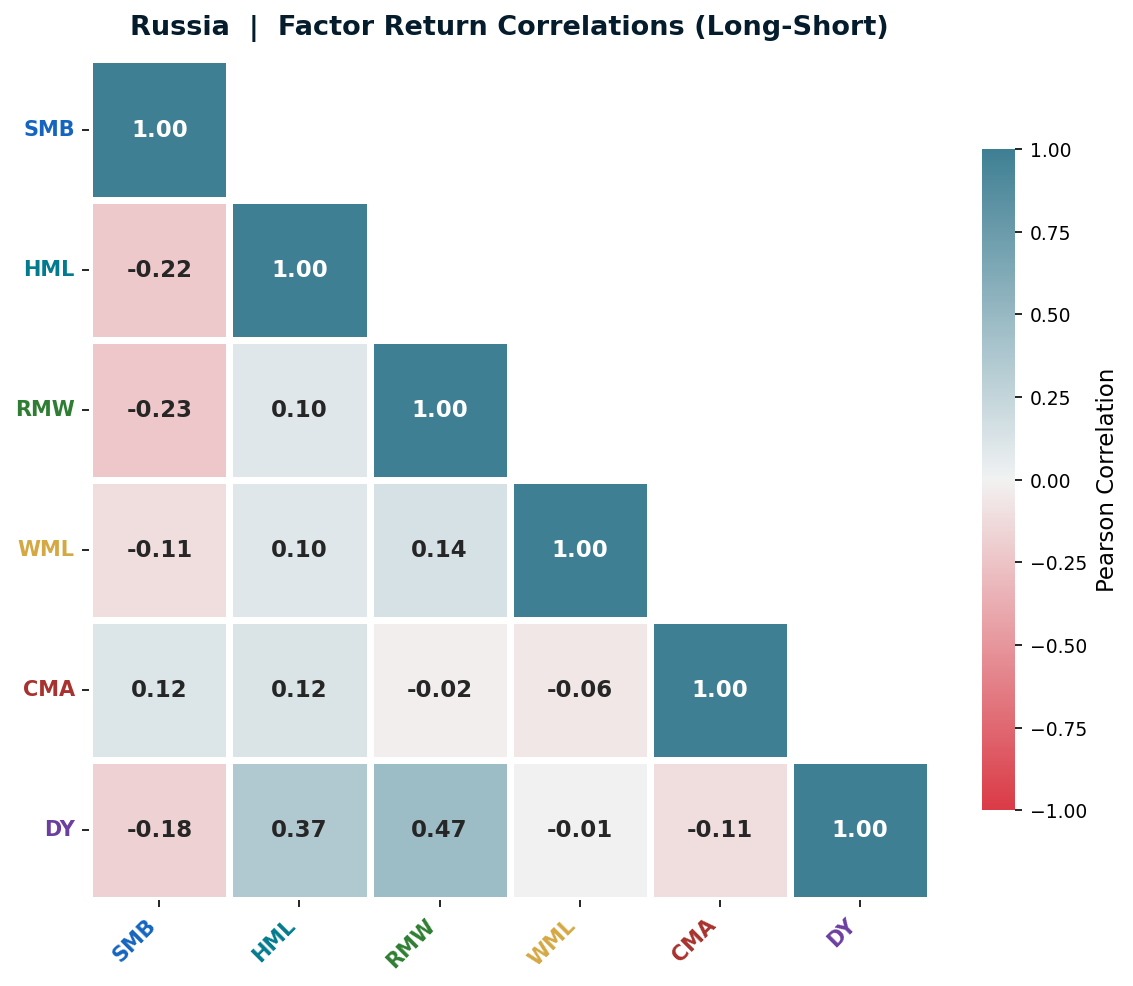

Period,SMB,HML,RMW,WML,CMA,DY
Full Period,2.2%,-3.7%,-1.4%,15.5%,-2.2%,0.2%
Pre-COVID (2012-19),-5.8%,-7.6%,-0.6%,22.3%,-3.4%,-0.3%
COVID Crash (2020),16.4%,-16.0%,7.0%,-7.3%,3.2%,5.5%
Post-COVID (2021-25),11.6%,4.3%,-3.4%,9.8%,-1.7%,-0.4%
Crimea/Oil 2014,-33.0%,-14.1%,-12.8%,21.2%,14.6%,-36.4%
Sanctions 2022,17.6%,-4.5%,-3.8%,-4.6%,5.6%,-14.8%



─── JAPAN ───────────────────────────────────────────────────
  -> /Users/dmitrijeremkin/Desktop/диплом созвон 5/output_factors/JP_rolling_sharpe.png


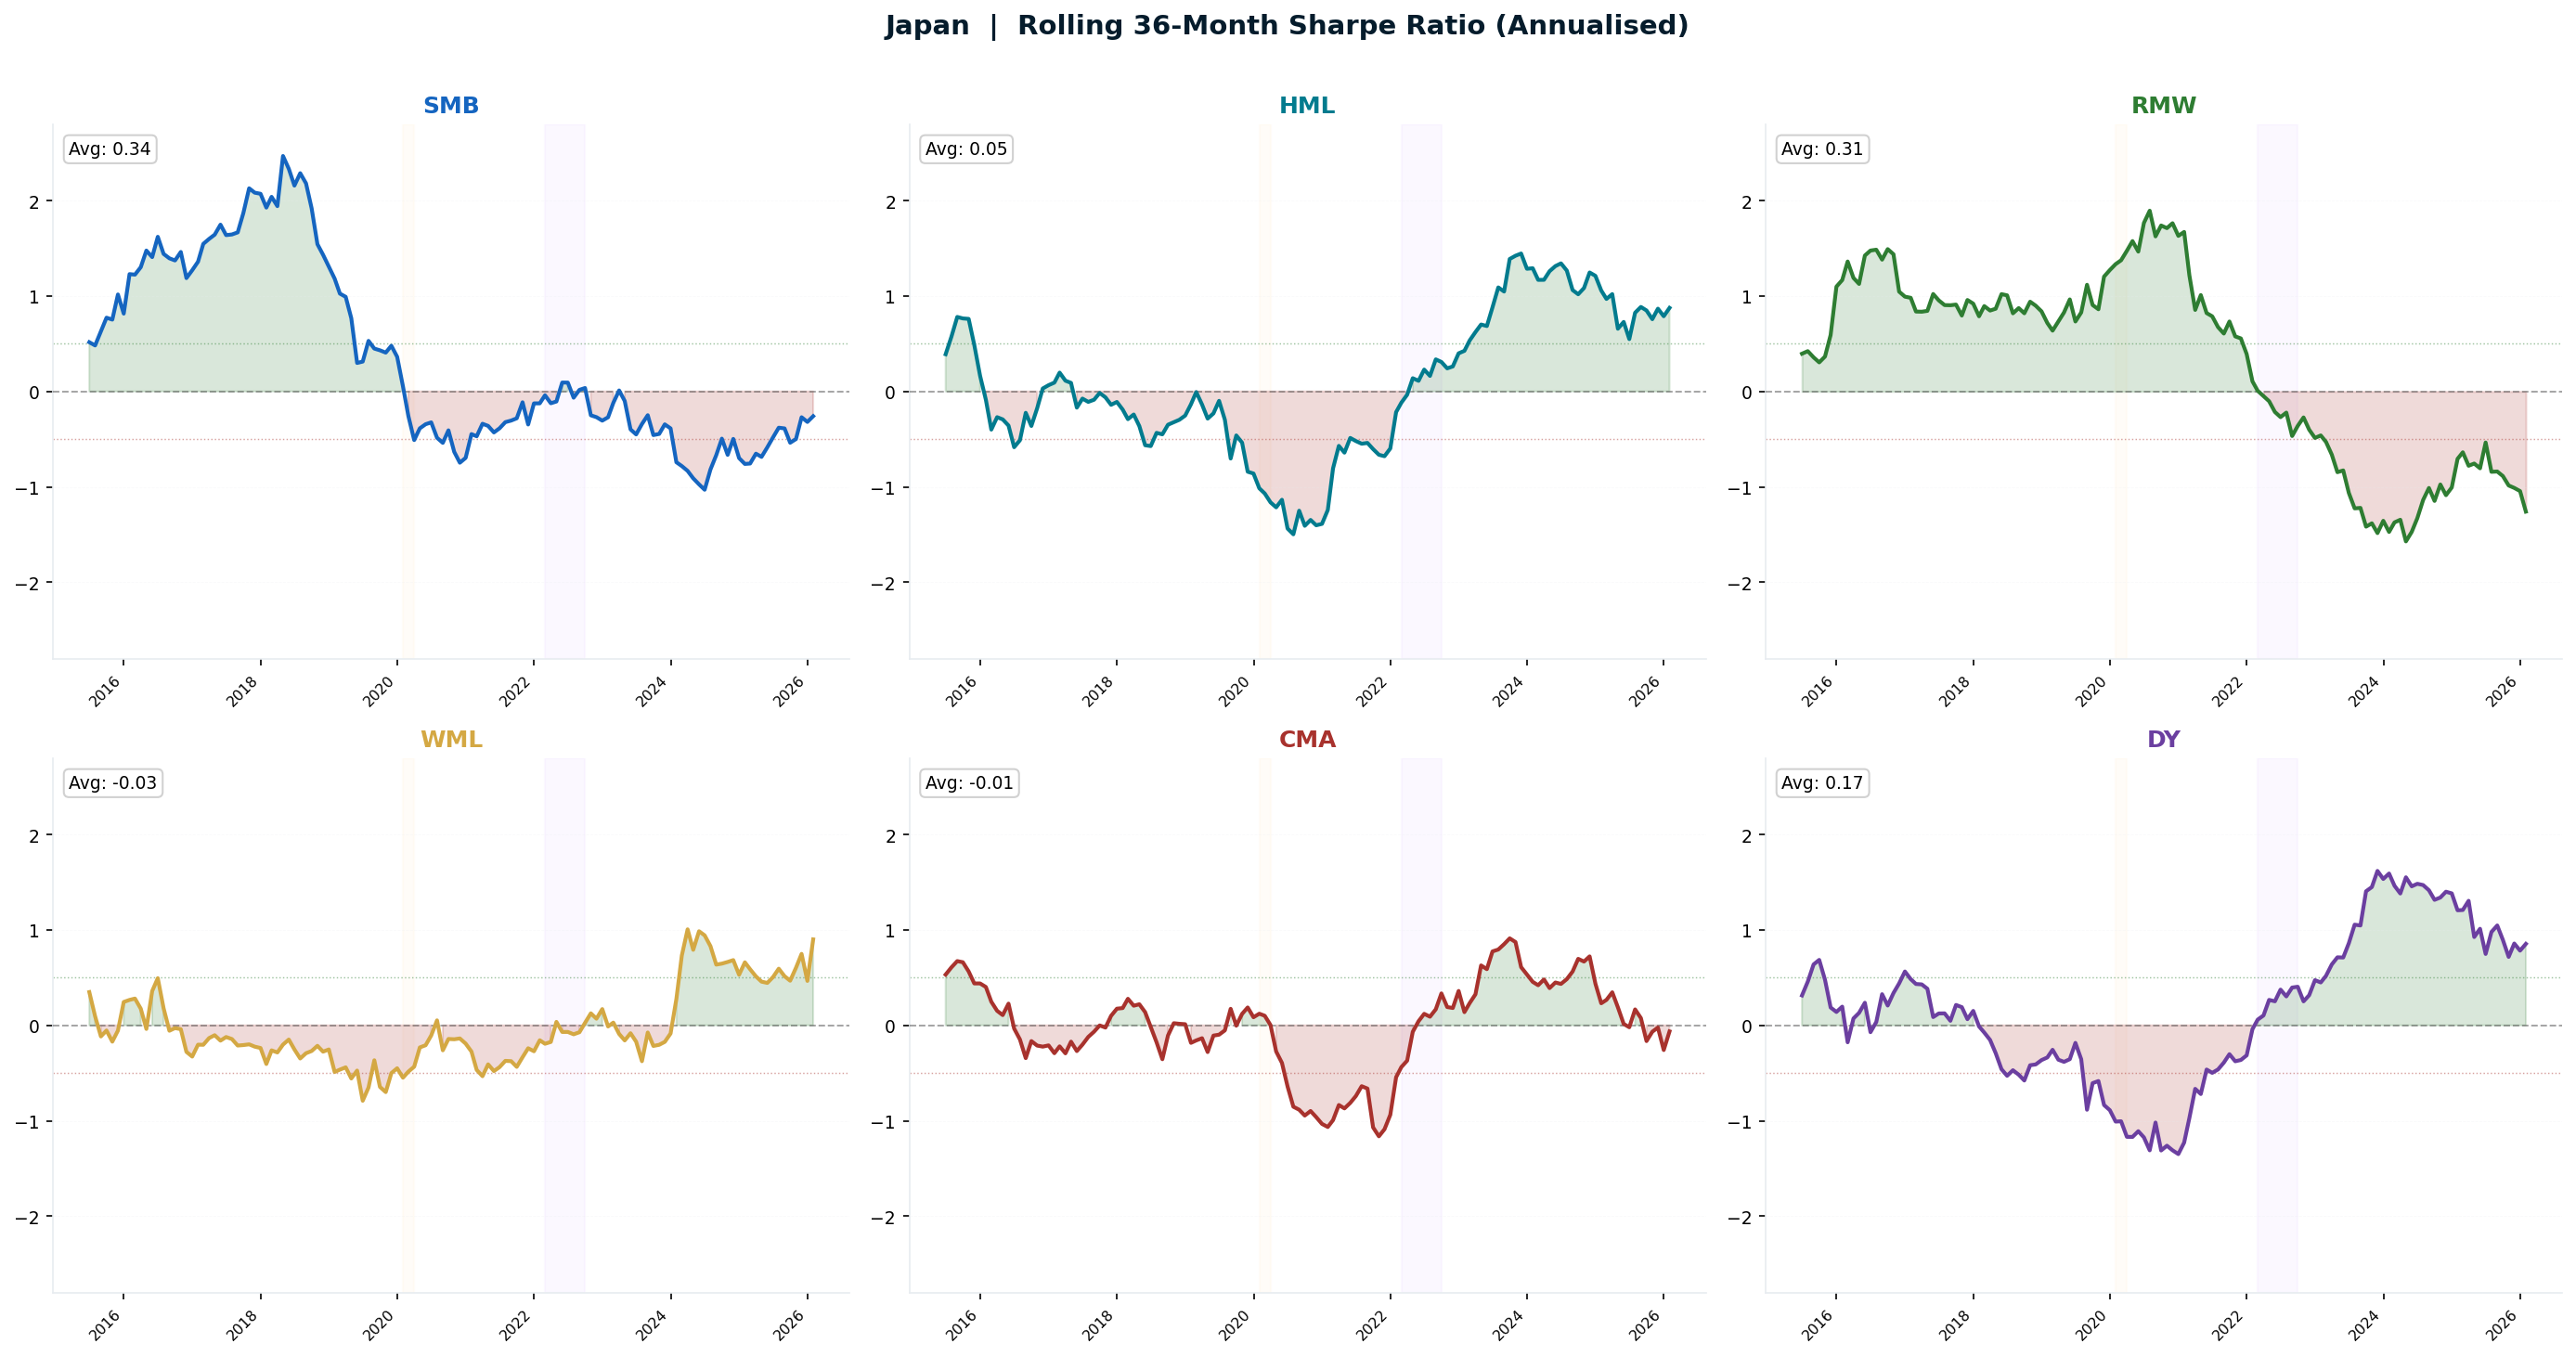

  -> /Users/dmitrijeremkin/Desktop/диплом созвон 5/output_factors/JP_drawdowns.png


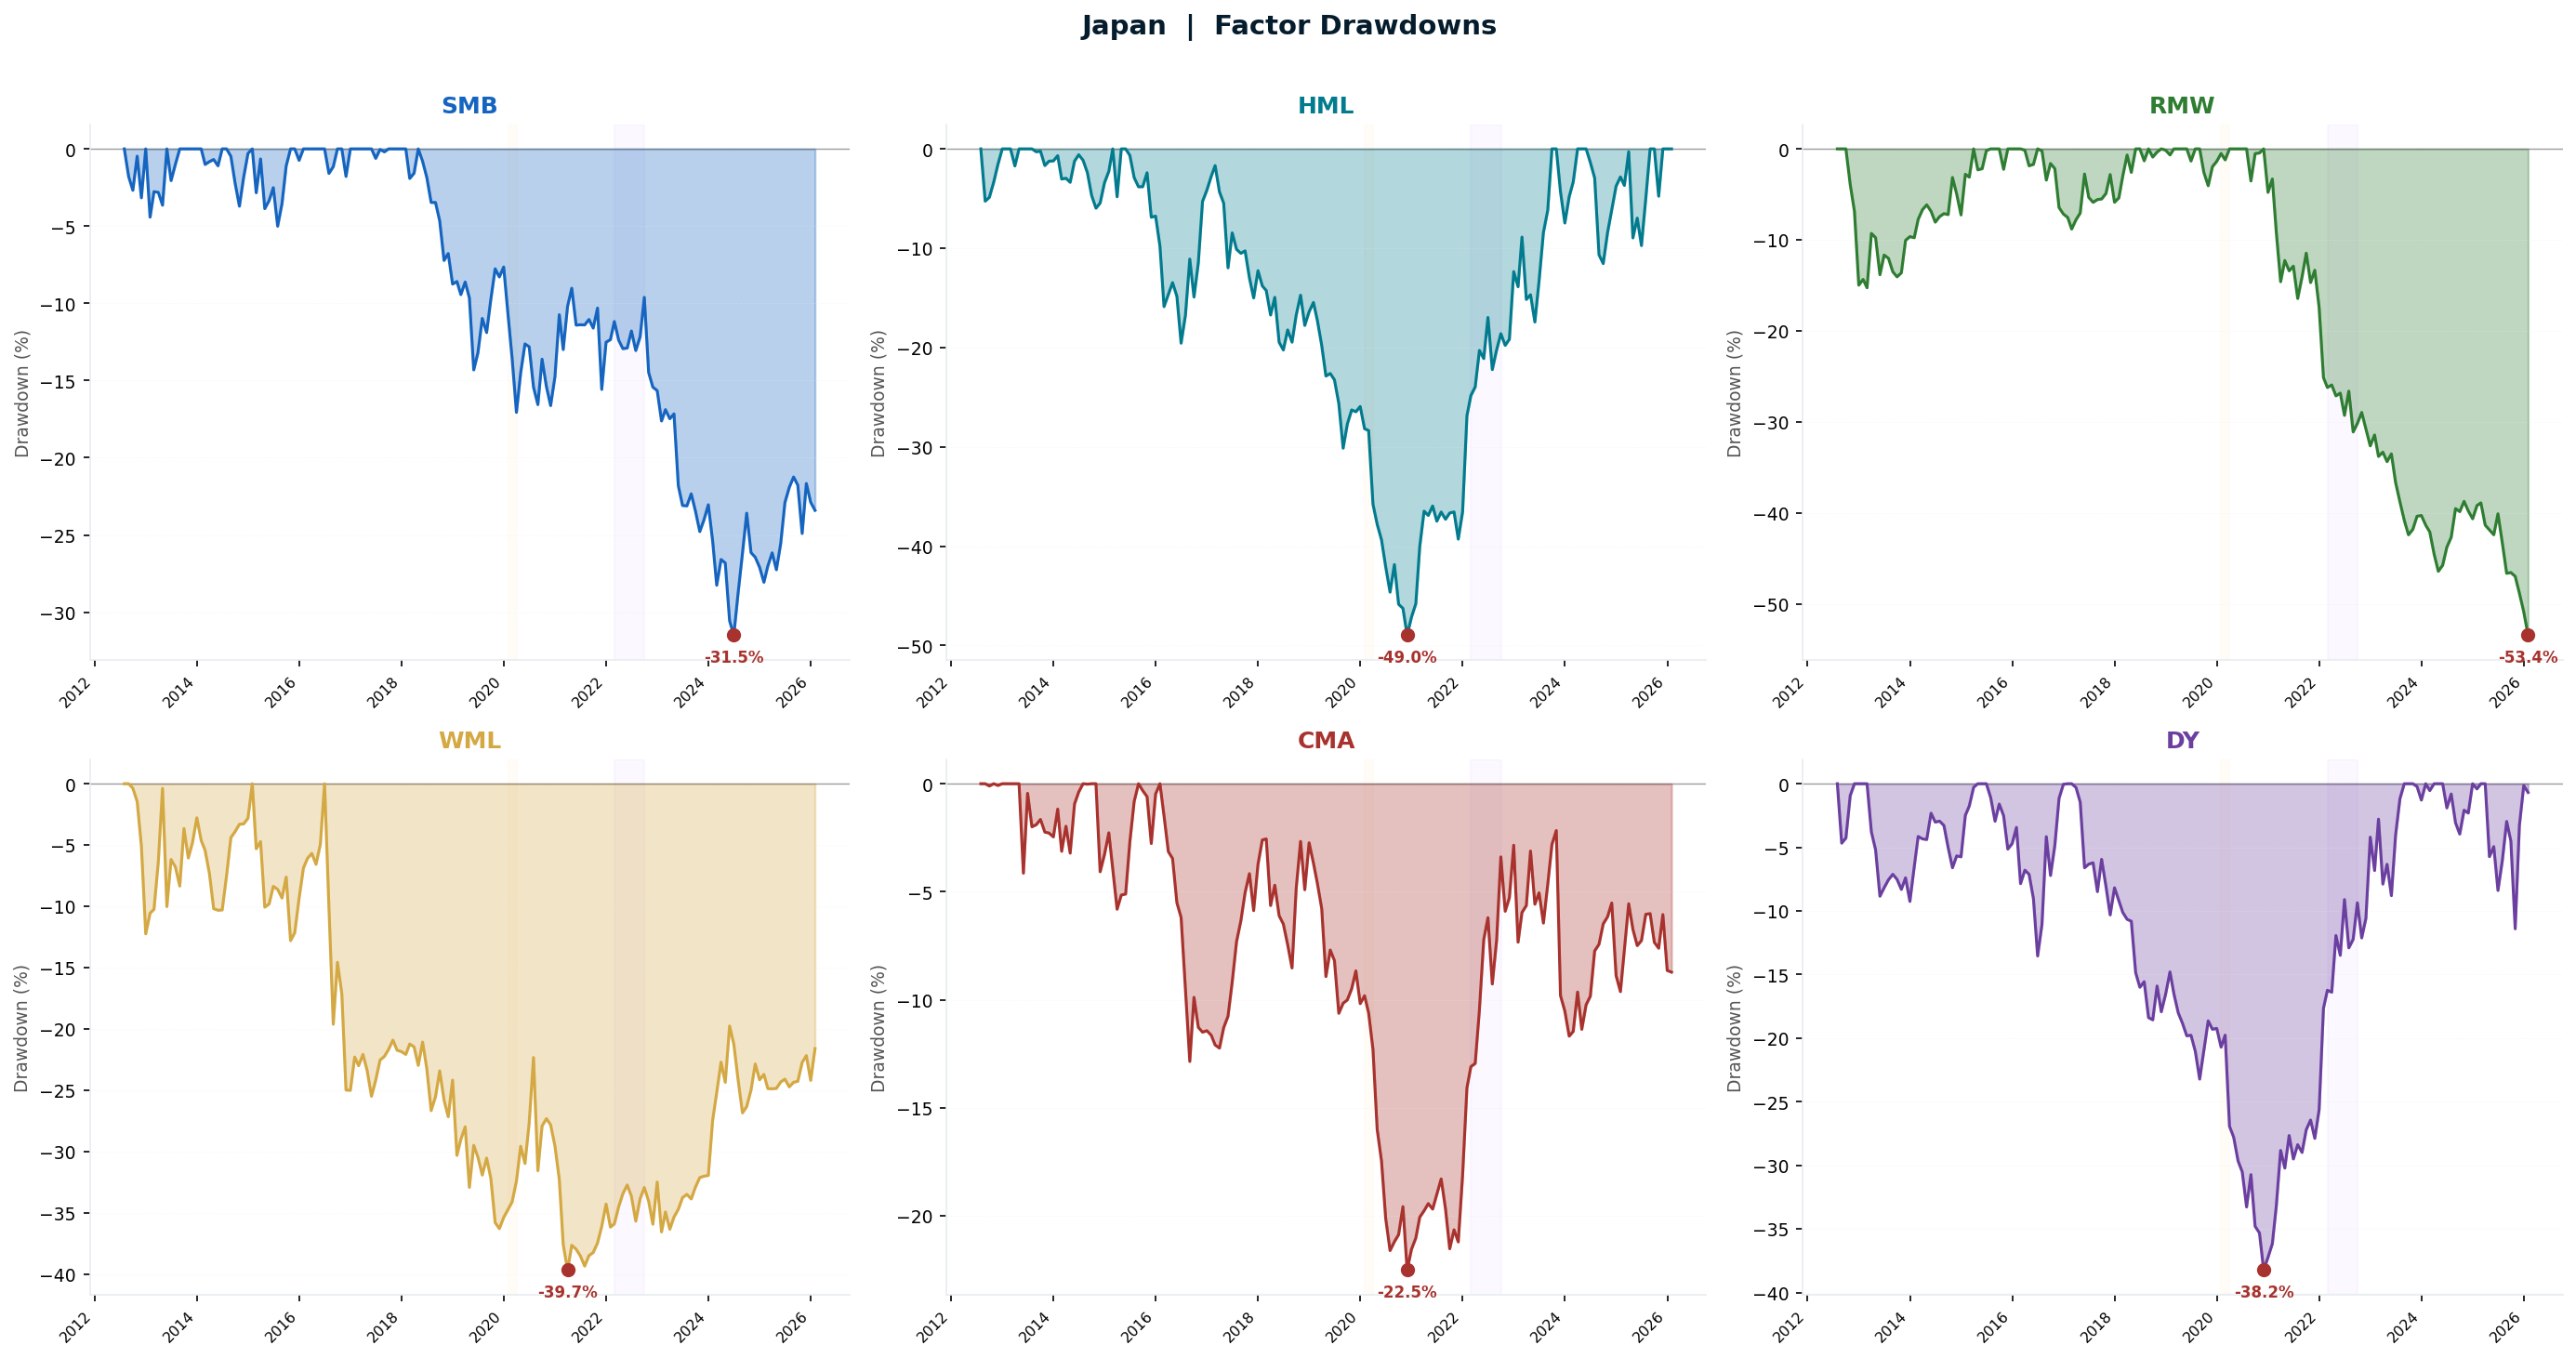

  -> /Users/dmitrijeremkin/Desktop/диплом созвон 5/output_factors/JP_annual_heatmap.png


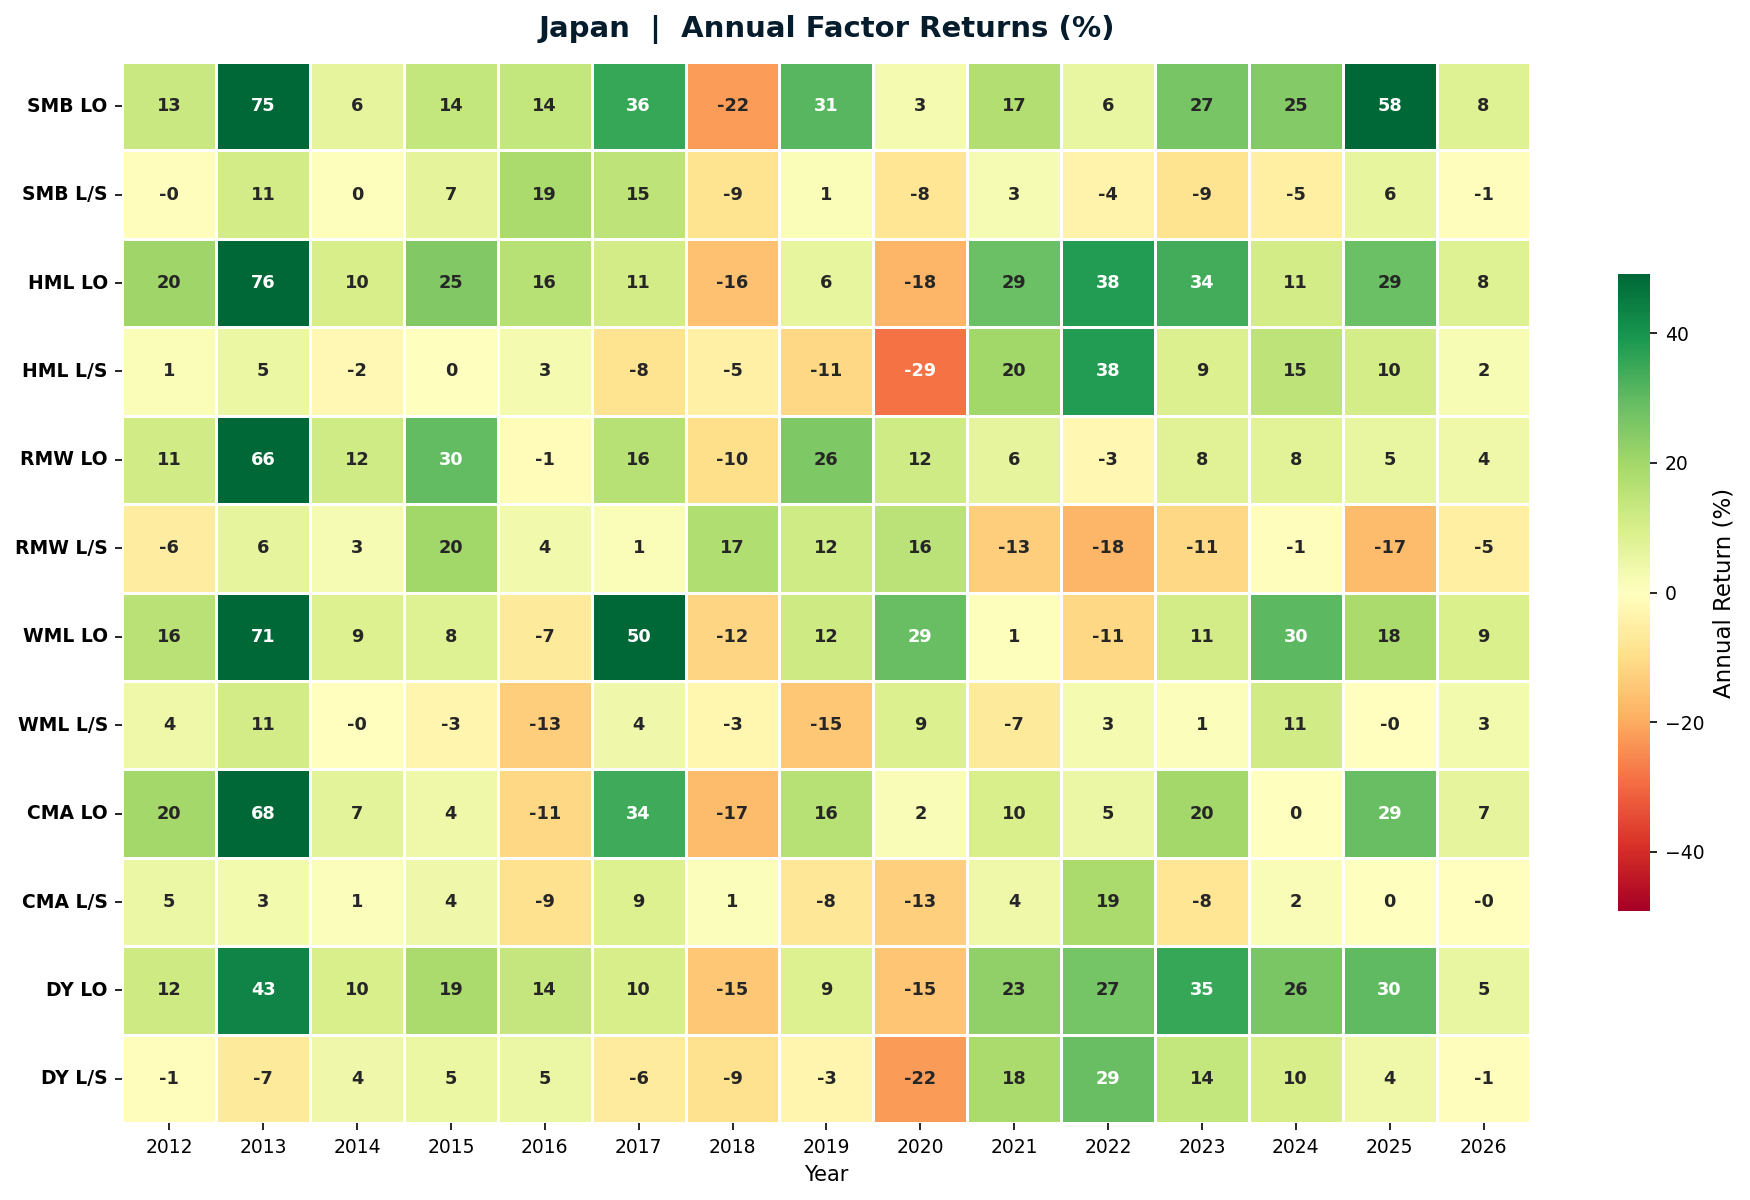

  -> /Users/dmitrijeremkin/Desktop/диплом созвон 5/output_factors/JP_correlations.png


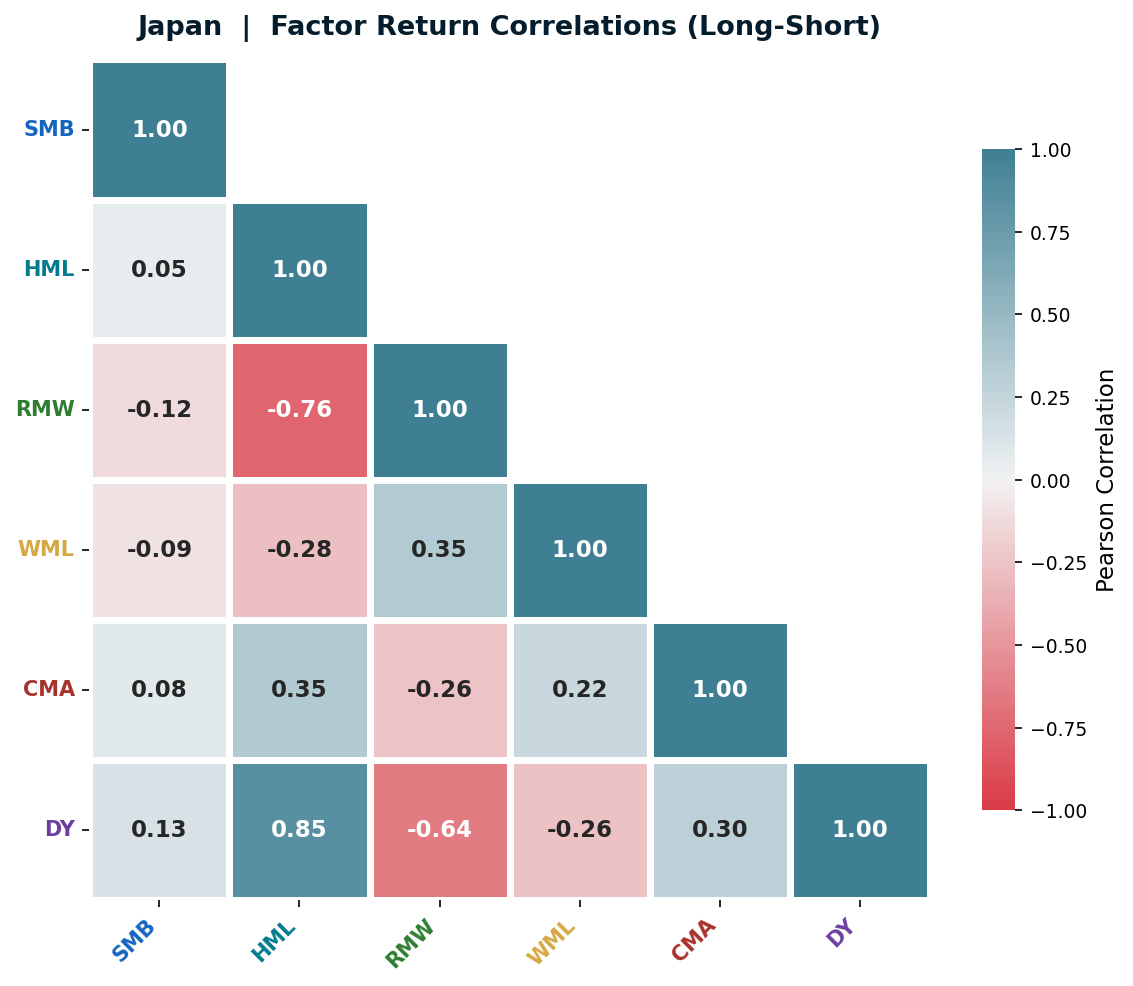

Period,SMB,HML,RMW,WML,CMA,DY
Full Period,1.6%,2.4%,-0.3%,0.1%,0.5%,2.2%
Pre-COVID (2012-19),5.5%,-2.6%,7.4%,-2.6%,0.9%,-1.8%
COVID Crash (2020),-10.6%,-33.4%,23.5%,12.8%,-14.9%,-25.4%
Post-COVID (2021-25),-1.7%,17.6%,-11.9%,2.0%,3.7%,14.4%
Abenomics 2013-19,5.9%,-3.0%,8.8%,-3.4%,0.2%,-1.8%
Yen Crisis 2022,3.0%,14.6%,-9.0%,8.1%,19.9%,14.5%



  ALL ANALYSIS COMPLETE


In [4]:
# ═══════════════════════════════════════════════════════════════════
# ADDITIONAL ANALYSIS — Rolling Sharpe, Drawdowns, Heatmap, Correlations
# (Updated: dynamic factor count, proper grid sizing, no NameError bugs)
# ═══════════════════════════════════════════════════════════════════

def _factor_grid(returns_dict, include_order=None):
    """Return list of available factors in canonical order."""
    order = include_order or FACTOR_ORDER
    return [f for f in order
            if f'sig_{f}' in returns_dict and returns_dict[f'sig_{f}'] is not None]

def _make_subplots(n_factors):
    """Create subplot grid that fits n_factors panels neatly."""
    ncols = min(n_factors, 3)
    nrows = (n_factors + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(6.2 * ncols, 4.8 * nrows), squeeze=False)
    # Hide unused axes
    for j in range(n_factors, nrows * ncols):
        axes.flat[j].set_visible(False)
    return fig, axes, nrows, ncols

# ─────────────────────────────────────────────────────────────────
# 1. ROLLING SHARPE RATIO
# ─────────────────────────────────────────────────────────────────
def plot_rolling_sharpe(returns_dict, rf, cfg, window=36, save=True):
    """Rolling Sharpe Ratio — one panel per factor."""
    factors = _factor_grid(returns_dict)
    n = len(factors)
    if n == 0:
        print("  No factor data for rolling Sharpe"); return

    fig, axes, nrows, ncols = _make_subplots(n)
    fig.suptitle(
        f'{cfg.flag}  |  Rolling {window}-Month Sharpe Ratio (Annualised)',
        fontsize=14, fontweight='bold', color=MCKINSEY_NAVY, y=1.01
    )

    for idx, fname in enumerate(factors):
        ax = axes[idx // ncols][idx % ncols]
        sig = f'sig_{fname}'
        r = returns_dict[sig]
        clr = FACTOR_PALETTE.get(fname, MCKINSEY_GRAY)

        rf_aligned = rf.reindex(r.index).fillna(rf.mean())
        excess = r - rf_aligned
        roll_sharpe = (excess.rolling(window).mean() /
                       excess.rolling(window).std() * np.sqrt(12))

        ax.plot(roll_sharpe.index, roll_sharpe.values, color=clr, lw=2, zorder=5)
        ax.axhline(0,   color='#444444', lw=0.9, ls='--', alpha=0.5, zorder=3)
        ax.axhline(0.5, color='#2E7D32', lw=0.7, ls=':', alpha=0.45, zorder=2)
        ax.axhline(-0.5,color='#A8322D', lw=0.7, ls=':', alpha=0.45, zorder=2)

        ax.fill_between(roll_sharpe.index, 0, roll_sharpe.values,
                        where=(roll_sharpe.values > 0), alpha=0.18,
                        color='#2E7D32', zorder=1)
        ax.fill_between(roll_sharpe.index, 0, roll_sharpe.values,
                        where=(roll_sharpe.values < 0), alpha=0.18,
                        color='#A8322D', zorder=1)

        _shade(ax, cfg.crises,
               roll_sharpe.dropna().index.min() if roll_sharpe.dropna().shape[0] else r.index.min(),
               r.index.max())

        ax.set_ylim([-2.8, 2.8])
        ax.set_title(fname, fontsize=12, fontweight='bold', color=clr, pad=6)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.xaxis.set_major_locator(mdates.YearLocator(2))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=7.5)
        ax.grid(axis='y', alpha=0.25, ls='--')
        ax.grid(False, axis='x')

        avg_sh = roll_sharpe.dropna().mean()
        ax.text(0.02, 0.97, f'Avg: {avg_sh:.2f}', transform=ax.transAxes,
                fontsize=9, va='top',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#CCCCCC', alpha=0.9))

    plt.tight_layout()
    if save:
        fn = os.path.join(OUT, f'{cfg.country}_rolling_sharpe.png')
        plt.savefig(fn, bbox_inches='tight', facecolor='white', dpi=300)
        print(f"  -> {fn}")
    plt.show()

# ─────────────────────────────────────────────────────────────────
# 2. DRAWDOWN ANALYSIS
# ─────────────────────────────────────────────────────────────────
def plot_drawdowns(returns_dict, cfg, save=True):
    """Drawdown chart — one panel per factor."""
    factors = _factor_grid(returns_dict)
    n = len(factors)
    if n == 0:
        print("  No factor data for drawdowns"); return

    fig, axes, nrows, ncols = _make_subplots(n)
    fig.suptitle(
        f'{cfg.flag}  |  Factor Drawdowns',
        fontsize=14, fontweight='bold', color=MCKINSEY_NAVY, y=1.01
    )

    for idx, fname in enumerate(factors):
        ax = axes[idx // ncols][idx % ncols]
        sig = f'sig_{fname}'
        r = returns_dict[sig]
        clr = FACTOR_PALETTE.get(fname, MCKINSEY_GRAY)

        cum = (1 + r).cumprod()
        dd = (cum - cum.cummax()) / cum.cummax() * 100
        max_dd = dd.min()
        max_dd_date = dd.idxmin()

        ax.fill_between(dd.index, dd.values, 0, alpha=0.30, color=clr)
        ax.plot(dd.index, dd.values, lw=1.5, color=clr, zorder=5)
        ax.axhline(0, color='#444444', lw=0.7, alpha=0.5)

        # Mark max drawdown point
        ax.scatter([max_dd_date], [max_dd], color='#A8322D', zorder=10, s=40)
        ax.annotate(f'{max_dd:.1f}%', xy=(max_dd_date, max_dd),
                    xytext=(0, -14), textcoords='offset points',
                    ha='center', fontsize=8, color='#A8322D', fontweight='bold')

        _shade(ax, cfg.crises, r.index.min(), r.index.max())

        ax.set_title(fname, fontsize=12, fontweight='bold', color=clr, pad=6)
        ax.set_ylabel('Drawdown (%)', fontsize=9, color='#555555')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.xaxis.set_major_locator(mdates.YearLocator(2))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=7.5)
        ax.grid(axis='y', alpha=0.25, ls='--')
        ax.grid(False, axis='x')

    plt.tight_layout()
    if save:
        fn = os.path.join(OUT, f'{cfg.country}_drawdowns.png')
        plt.savefig(fn, bbox_inches='tight', facecolor='white', dpi=300)
        print(f"  -> {fn}")
    plt.show()

# ─────────────────────────────────────────────────────────────────
# 3. ANNUAL RETURNS HEATMAP
# ─────────────────────────────────────────────────────────────────
def plot_annual_heatmap(lo_rets, ls_rets, cfg, save=True):
    """Annual returns heatmap — rows = strategies, columns = years."""
    data = {}
    # Ordered: LO first, then LS, within each follow FACTOR_ORDER
    for fname in FACTOR_ORDER:
        sig = f'sig_{fname}'
        if sig in lo_rets and lo_rets[sig] is not None:
            data[f'{fname} LO'] = lo_rets[sig]
        if sig in ls_rets and ls_rets[sig] is not None:
            data[f'{fname} L/S'] = ls_rets[sig]

    if not data:
        print("  No data for heatmap"); return

    df = pd.DataFrame(data)
    annual = df.resample('YE').apply(lambda x: (1 + x).prod() - 1) * 100
    annual.index = annual.index.year

    nrows_h = len(data)
    ncols_h = len(annual)
    fig, ax = plt.subplots(figsize=(max(12, ncols_h * 0.85), max(5, nrows_h * 0.55 + 1.5)))

    # Color each row by its factor color (custom cmap per row not easily possible;
    # use RdYlGn overall — standard for financial heatmaps)
    vmax = min(annual.abs().quantile(0.90).max(), 150)  # cap colour scale for readability
    sns.heatmap(
        annual.T,
        annot=True, fmt='.0f', cmap='RdYlGn', center=0,
        vmin=-vmax, vmax=vmax,
        linewidths=1.2, linecolor='white',
        cbar_kws={'shrink': 0.6, 'label': 'Annual Return (%)'},
        ax=ax,
        annot_kws={'size': 8.5, 'fontweight': 'bold'}
    )

    # Style the tick labels
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=9, fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=9)
    ax.set_title(
        f'{cfg.flag}  |  Annual Factor Returns (%)',
        fontsize=14, fontweight='bold', color=MCKINSEY_NAVY, pad=12
    )
    ax.set_ylabel('')
    ax.set_xlabel('Year', fontsize=10)
    plt.tight_layout()

    if save:
        fn = os.path.join(OUT, f'{cfg.country}_annual_heatmap.png')
        plt.savefig(fn, bbox_inches='tight', facecolor='white', dpi=300)
        print(f"  -> {fn}")
    plt.show()

# ─────────────────────────────────────────────────────────────────
# 4. FACTOR CORRELATION MATRIX
# ─────────────────────────────────────────────────────────────────
def plot_factor_correlations(ls_rets, cfg, save=True):
    """Lower-triangle correlation heatmap of factor L/S returns."""
    data = {}
    for fname in FACTOR_ORDER:
        sig = f'sig_{fname}'
        if sig in ls_rets and ls_rets[sig] is not None:
            data[fname] = ls_rets[sig]

    if len(data) < 2:
        print("  Not enough factors for correlation matrix"); return

    df = pd.DataFrame(data).dropna()
    corr = df.corr()
    n = len(corr)

    fig, ax = plt.subplots(figsize=(n * 1.05 + 1.5, n * 1.0 + 1.2))
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # show lower triangle + diagonal

    # Custom diverging colormap: red-white-blue (McKinsey safe)
    cmap = sns.diverging_palette(10, 220, as_cmap=True)
    sns.heatmap(
        corr, mask=mask,
        annot=True, fmt='.2f',
        cmap=cmap, center=0, vmin=-1, vmax=1,
        square=True, linewidths=2.5, linecolor='white',
        ax=ax,
        annot_kws={'size': 11, 'fontweight': 'bold'},
        cbar_kws={'shrink': 0.65, 'label': 'Pearson Correlation'}
    )

    # Color-code factor labels
    for i, fname in enumerate(corr.index):
        clr = FACTOR_PALETTE.get(fname, '#555555')
        ax.get_yticklabels()[i].set_color(clr)
        ax.get_yticklabels()[i].set_fontweight('bold')
    for i, fname in enumerate(corr.columns):
        clr = FACTOR_PALETTE.get(fname, '#555555')
        ax.get_xticklabels()[i].set_color(clr)
        ax.get_xticklabels()[i].set_fontweight('bold')

    ax.set_title(
        f'{cfg.flag}  |  Factor Return Correlations (Long-Short)',
        fontsize=13, fontweight='bold', color=MCKINSEY_NAVY, pad=12
    )
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
    plt.tight_layout()

    if save:
        fn = os.path.join(OUT, f'{cfg.country}_correlations.png')
        plt.savefig(fn, bbox_inches='tight', facecolor='white', dpi=300)
        print(f"  -> {fn}")
    plt.show()

# ─────────────────────────────────────────────────────────────────
# 5. SUB-PERIOD ANALYSIS
# ─────────────────────────────────────────────────────────────────
def analyze_subperiods(ls_rets, rf, cfg):
    """CAGR table by sub-period for all available L/S factors."""
    periods = {
        'Full Period': (None, None),
        'Pre-COVID (2012-19)': ('2012-01', '2019-12'),
        'COVID Crash (2020)': ('2020-01', '2020-12'),
        'Post-COVID (2021-25)': ('2021-01', '2026-12'),
    }
    if cfg.country == 'RF':
        periods['Crimea/Oil 2014'] = ('2014-03', '2014-12')
        periods['Sanctions 2022'] = ('2022-02', '2022-12')
    elif cfg.country == 'JP':
        periods['Abenomics 2013-19'] = ('2013-01', '2019-12')
        periods['Yen Crisis 2022'] = ('2022-03', '2022-10')

    factors = _factor_grid(ls_rets)
    rows = []
    for pname, (start, end) in periods.items():
        row = {'Period': pname}
        for f in factors:
            r = ls_rets[f'sig_{f}']
            mask = pd.Series(True, index=r.index)
            if start: mask &= (r.index >= start)
            if end:   mask &= (r.index <= end)
            sub = r[mask]
            if len(sub) < 2:
                row[f] = np.nan; continue
            cum = (1 + sub).prod() - 1
            n_y = len(sub) / 12
            row[f] = (1 + cum) ** (1 / max(n_y, 1/12)) - 1 if cum > -1 else -1.0
        rows.append(row)

    df_sp = pd.DataFrame(rows)
    fmt_map = {f: '{:.1%}' for f in factors}
    display(HTML(mckinsey_table_html(df_sp,
        title=f'{cfg.flag} — Sub-period L/S CAGR by Factor', fmt_map=fmt_map)))

# ═══════════════════════════════════════════════════════════════════
# RUN ALL ADDITIONAL ANALYSIS
# ═══════════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("  ADDITIONAL ANALYSIS")
print("=" * 65)

print("\n─── RUSSIA ──────────────────────────────────────────────────")
plot_rolling_sharpe(ls_r, dm_r.rf, cfg_r)
plot_drawdowns(ls_r, cfg_r)
plot_annual_heatmap(lo_r, ls_r, cfg_r)
plot_factor_correlations(ls_r, cfg_r)
analyze_subperiods(ls_r, dm_r.rf, cfg_r)

print("\n─── JAPAN ───────────────────────────────────────────────────")
plot_rolling_sharpe(ls_j, dm_j.rf, cfg_j)
plot_drawdowns(ls_j, cfg_j)
plot_annual_heatmap(lo_j, ls_j, cfg_j)
plot_factor_correlations(ls_j, cfg_j)
analyze_subperiods(ls_j, dm_j.rf, cfg_j)

print("\n" + "=" * 65)
print("  ALL ANALYSIS COMPLETE")
print("=" * 65)


In [6]:
# ═══════════════════════════════════════════════════════════════════
# SUB-PERIOD ANALYSIS: Factor Performance in Crises
# ═══════════════════════════════════════════════════════════════════

print("\n" + "=" * 80)
print("  SUB-PERIOD ANALYSIS: Factor Performance in Crises")
print("=" * 80)

def analyze_subperiods(lo_rets, ls_rets, rf, cfg):
    """
    Анализ факторов по подпериодам и кризисам.
    Показывает CAGR для Long-Only и Long-Short.
    """
    
    # Общие периоды
    periods = {
        'Full Period':    (None, None),
        'Pre-COVID':      ('2012-01', '2019-12'),
        'COVID Crash':    ('2020-02', '2020-04'),
        'COVID Recovery': ('2020-05', '2021-12'),
        'Post-COVID':     ('2022-01', '2026-01'),
    }
    
    # Страновые кризисы
    if cfg.country == 'RF':
        periods['Crimea/Oil 2014'] = ('2014-03', '2014-12')
        periods['Sanctions 2022'] = ('2022-02', '2022-10')
    elif cfg.country == 'JP':
        periods['Abenomics'] = ('2013-01', '2019-12')
        periods['Yen Crisis 2022'] = ('2022-03', '2022-10')
    
    factors = FACTOR_ORDER
    
    def calc_period_stats(returns_dict, start, end):
        """Рассчитать статистику за период."""
        results = {}
        for factor in factors:
            sig = f'sig_{factor}'
            r = returns_dict.get(sig)
            if r is None:
                results[factor] = {'cagr': np.nan, 'cum': np.nan, 'n': 0}
                continue
            
            if start is not None:
                mask = (r.index >= start)
                if end is not None:
                    mask &= (r.index <= end)
                sub = r[mask]
            else:
                sub = r
            
            if len(sub) < 2:
                results[factor] = {'cagr': np.nan, 'cum': np.nan, 'n': 0}
                continue
            
            cum = (1 + sub).prod() - 1
            n_years = len(sub) / 12
            if cum > -1 and n_years > 0:
                cagr = (1 + cum) ** (1 / max(n_years, 1/12)) - 1
            else:
                cagr = -1
            
            results[factor] = {'cagr': cagr, 'cum': cum, 'n': len(sub)}
        
        return results
    
    # ═══════════════════════════════════════════════════════════════
    # LONG-ONLY
    # ═══════════════════════════════════════════════════════════════
    print(f"\n  {cfg.flag} — LONG-ONLY Performance by Period")
    print("  " + "=" * 75)
    print(f"  {'Period':<20} {'N':>4}", end='')
    for f in factors:
        print(f" {f:>10}", end='')
    print()
    print("  " + "-" * 75)
    
    for period_name, (start, end) in periods.items():
        stats = calc_period_stats(lo_rets, start, end)
        n = max([s['n'] for s in stats.values()])
        print(f"  {period_name:<20} {n:>4}", end='')
        for f in factors:
            cagr = stats[f]['cagr']
            if np.isnan(cagr):
                print(f" {'-':>10}", end='')
            else:
                print(f" {cagr:>+9.1%}", end='')
        print()
    
    print("  " + "=" * 75)
    
    # ═══════════════════════════════════════════════════════════════
    # LONG-SHORT
    # ═══════════════════════════════════════════════════════════════
    print(f"\n  {cfg.flag} — LONG-SHORT Performance by Period")
    print("  " + "=" * 75)
    print(f"  {'Period':<20} {'N':>4}", end='')
    for f in factors:
        print(f" {f:>10}", end='')
    print()
    print("  " + "-" * 75)
    
    for period_name, (start, end) in periods.items():
        stats = calc_period_stats(ls_rets, start, end)
        n = max([s['n'] for s in stats.values()])
        print(f"  {period_name:<20} {n:>4}", end='')
        for f in factors:
            cagr = stats[f]['cagr']
            if np.isnan(cagr):
                print(f" {'-':>10}", end='')
            else:
                print(f" {cagr:>+9.1%}", end='')
        print()
    
    print("  " + "=" * 75)
    
    # ═══════════════════════════════════════════════════════════════
    # CRISIS CUMULATIVE RETURNS (для коротких периодов)
    # ═══════════════════════════════════════════════════════════════
    crisis_periods = {k: v for k, v in periods.items() 
                      if any(x in k.lower() for x in ['crash', 'crisis', 'crimea', 'sanctions', 'yen'])}
    
    if crisis_periods:
        print(f"\n  {cfg.flag} — CRISIS Cumulative Returns (L/S)")
        print("  " + "=" * 75)
        print(f"  {'Crisis':<20} {'Months':>6}", end='')
        for f in factors:
            print(f" {f:>10}", end='')
        print()
        print("  " + "-" * 75)
        
        for period_name, (start, end) in crisis_periods.items():
            stats = calc_period_stats(ls_rets, start, end)
            n = max([s['n'] for s in stats.values()])
            print(f"  {period_name:<20} {n:>6}", end='')
            for f in factors:
                cum = stats[f]['cum']
                if np.isnan(cum):
                    print(f" {'-':>10}", end='')
                else:
                    print(f" {cum:>+9.1%}", end='')
            print()
        
        print("  " + "=" * 75)
        print("  Note: Short periods show cumulative return, not CAGR")

# ═══════════════════════════════════════════════════════════════════
# ЗАПУСК АНАЛИЗА
# ═══════════════════════════════════════════════════════════════════

# Russia
analyze_subperiods(lo_r, ls_r, dm_r.rf, cfg_r)

# Japan
analyze_subperiods(lo_j, ls_j, dm_j.rf, cfg_j)

# ═══════════════════════════════════════════════════════════════════
# CROSS-COUNTRY CRISIS COMPARISON
# ═══════════════════════════════════════════════════════════════════

print("\n" + "=" * 80)
print("  CROSS-COUNTRY: COVID Crash Performance (Feb-Apr 2020)")
print("=" * 80)

def get_crisis_returns(lo_rets, ls_rets, start, end):
    """Получить cumulative returns за кризис."""
    results = {}
    for mode, rets in [('LO', lo_rets), ('LS', ls_rets)]:
        for sig, r in rets.items():
            if r is None:
                continue
            fname = sig.replace('sig_', '')
            sub = r[(r.index >= start) & (r.index <= end)]
            if len(sub) >= 1:
                cum = (1 + sub).prod() - 1
                results[f'{fname}_{mode}'] = cum
    return results

covid_ru = get_crisis_returns(lo_r, ls_r, '2020-02', '2020-04')
covid_jp = get_crisis_returns(lo_j, ls_j, '2020-02', '2020-04')

print(f"\n  {'Factor':<8} {'RU_LO':>10} {'RU_LS':>10} {'JP_LO':>10} {'JP_LS':>10}")
print("  " + "-" * 50)

for f in ['SMB', 'HML', 'RMW', 'WML', 'CMA']:
    ru_lo = covid_ru.get(f'{f}_LO', np.nan)
    ru_ls = covid_ru.get(f'{f}_LS', np.nan)
    jp_lo = covid_jp.get(f'{f}_LO', np.nan)
    jp_ls = covid_jp.get(f'{f}_LS', np.nan)
    
    def fmt(v):
        return f"{v:>+9.1%}" if not np.isnan(v) else f"{'-':>10}"
    
    print(f"  {f:<8} {fmt(ru_lo)} {fmt(ru_ls)} {fmt(jp_lo)} {fmt(jp_ls)}")

print("  " + "=" * 50)
print("  Note: COVID Crash = Feb-Apr 2020 cumulative return")

print("\n" + "=" * 80)
print("  SUB-PERIOD ANALYSIS COMPLETE")
print("=" * 80)


  SUB-PERIOD ANALYSIS: Factor Performance in Crises

  Russia — LONG-ONLY Performance by Period
  Period                  N        SMB        HML        RMW        WML        CMA         DY
  ---------------------------------------------------------------------------
  Full Period           165    +20.7%     +7.6%     +4.3%     +8.7%     +5.8%    +13.6%
  Pre-COVID              91    +16.7%    +11.5%     +9.7%    +17.5%    +10.0%    +16.4%
  COVID Crash             2    -45.7%    -73.1%    -51.3%    -67.9%    -54.1%    -58.3%
  COVID Recovery         19    +34.6%    +49.0%    +25.0%    +34.4%    +37.4%    +38.1%
  Post-COVID             36    +21.6%     -4.8%    -10.9%     -9.9%    -10.9%     +5.9%
  Crimea/Oil 2014         9     -1.2%    +30.9%     +1.5%    +10.7%    +21.7%    +17.5%
  Sanctions 2022          8    -42.9%    -25.3%    -62.2%    -55.9%    -36.2%    -56.9%

  Russia — LONG-SHORT Performance by Period
  Period                  N        SMB        HML        RMW        WM

---
## Portfolio Compositions — Trading Year 2026

Actual stock holdings for each factor strategy.  
Rebalanced **May 2026** (Russia) and **July 2026** (Japan) — ready for slides.


In [9]:
# =================================================================
# PORTFOLIO COMPOSITIONS -- TRADING YEAR 2026
# =================================================================

# Key metric column candidates per factor
_FACTOR_METRIC = {
    'SMB': (['market_cap_mln','market_cap'],                          'MktCap (mln)', '{:,.0f}'),
    'HML': (['book_to_market','pbv','pb'],                            'BM / PBV',     '{:.2f}'),
    'RMW': (['_gpa_computed','gross_profit_margin_pct','ebitda_margin_pct','roe_pct'], 'GP/A (%)', '{:.1f}'),
    'WML': (['mom_12_1_pct','mom12_1'],                               'Mom 12-1 (%)', '{:+.1f}'),
    'CMA': (['assets_growth_pct','asset_growth_pct','_asset_growth_computed'], 'Asst Gth (%)', '{:+.1f}'),
    'DY':  (['div_yield_pct','dividend_yield'],                       'Div Yld (%)', '{:.2f}'),
}

_FACTOR_FULL = {
    'SMB': 'Size (Small Minus Big)',
    'HML': 'Value (High Minus Low)',
    'RMW': 'Profitability (Robust Minus Weak)',
    'WML': 'Momentum (Winners Minus Losers)',
    'CMA': 'Investment (Conservative vs Aggressive)',
    'DY':  'Dividend Yield (High Minus Low)',
}

def _best_col(panel, cols):
    for c in cols:
        if c in panel.columns and panel[c].notna().sum() > 5:
            return c
    return None

def build_port_2026(panel, cfg, sig_col, fname, strategy='LO', top_n=20):
    mc_col = find_col(panel, ['market_cap_mln','market_cap','mktcap'])
    sec_col = cfg.sector_col if cfg.sector_col in panel.columns else None
    m_cols, m_lbl, m_fmt = _FACTOR_METRIC.get(fname, ([''], 'Signal', '{:.2f}'))
    m_col = _best_col(panel, m_cols)

    mask = (panel['trading_year'] == 2026)
    if mc_col and cfg.min_market_cap > 0:
        mask &= (panel[mc_col] >= cfg.min_market_cap)
    uni = panel[mask].dropna(subset=[sig_col]).copy()
    if len(uni) < 5:
        return None

    def rows_df(sub):
        if mc_col:
            w_raw = sub.set_index(cfg.ticker_col)[mc_col].clip(lower=0.01)
            weights = (w_raw / w_raw.sum() * 100)
        else:
            weights = pd.Series(100.0/len(sub), index=sub[cfg.ticker_col])
        out = []
        for rk, (_, row) in enumerate(sub.iterrows(), 1):
            tk = row[cfg.ticker_col]
            mc = row.get(mc_col, np.nan) if mc_col else np.nan
            mc_str = (f'{mc/1e6:.1f}T' if pd.notna(mc) and mc>=1e6 else
                      f'{mc/1e3:.1f}B' if pd.notna(mc) and mc>=1000 else
                      f'{mc:.0f}M' if pd.notna(mc) else '?')
            if m_col:
                v = row.get(m_col, np.nan)
                try: m_str = m_fmt.format(v) if pd.notna(v) else '-'
                except: m_str = '-'
            else:
                m_str = '-'
            sec = str(row[sec_col])[:26] if sec_col else '-'
            out.append({
                '#':    rk,
                'Ticker': tk,
                'Sector': sec,
                m_lbl:  m_str,
                'Signal': f'{row[sig_col]:.2f}',
                'MktCap': mc_str,
                'Wt %':  f'{weights.get(tk, 0):.1f}%',
            })
        return pd.DataFrame(out)

    if strategy == 'LO':
        sel = uni.nlargest(top_n, sig_col)
        return {'long': rows_df(sel), 'short': None}

    # Long-Short 2x3
    size_col = 'sig_SMB'
    if size_col not in uni.columns: return None
    v = uni.dropna(subset=[size_col]).copy()
    if len(v) < 20: return None
    v['_sg'] = np.where(v[size_col] >= v[size_col].median(), 'S', 'B')
    lo_bp = v[sig_col].quantile(0.30); hi_bp = v[sig_col].quantile(0.70)
    v['_fg'] = np.where(v[sig_col] >= hi_bp, 'H', np.where(v[sig_col] <= lo_bp, 'L', 'M'))
    v['_p'] = v['_sg'] + v['_fg']
    longs  = v[v['_p'].isin(['SH','BH'])].nlargest(top_n, sig_col)
    shorts = v[v['_p'].isin(['SL','BL'])].nsmallest(top_n, sig_col)
    return {'long': rows_df(longs), 'short': rows_df(shorts)}

# ── HTML builder ────────────────────────────────────────────────
_PF_CSS = '''
<style>
.pfw{font-family:'Helvetica Neue',Arial,sans-serif;margin:0 0 32px 0;border-radius:8px;
  box-shadow:0 2px 12px rgba(0,0,0,.10);overflow:hidden}
.pfh{padding:12px 18px;display:flex;align-items:center;justify-content:space-between}
.pfh-title{font-size:15px;font-weight:700;letter-spacing:.3px;color:#fff}
.pfh-sub{font-size:11px;color:rgba(255,255,255,.8);margin-top:2px}
.pfh-badge{background:rgba(255,255,255,.2);color:#fff;font-size:10.5px;
  padding:3px 12px;border-radius:20px;white-space:nowrap}
.pf-sec{font-size:10px;font-weight:800;text-transform:uppercase;letter-spacing:.8px;
  padding:6px 14px 3px;border-bottom:1px solid #eee}
.pft{border-collapse:collapse;width:100%}
.pft th{background:#F5F7FA;padding:6px 12px;font-size:10px;font-weight:700;
  text-transform:uppercase;letter-spacing:.3px;color:#444;border-bottom:2px solid #E0E4EA;text-align:center}
.pft td{padding:5px 12px;font-size:11.5px;text-align:center;
  border-bottom:1px solid #F0F2F5;color:#222}
.pft td:nth-child(2){text-align:left;font-weight:700;font-family:monospace;font-size:12.5px}
.pft td:nth-child(3){text-align:left;font-size:10.5px;color:#666}
.pft td:first-child{color:#AAA;font-size:10px}
.pft td:last-child{font-weight:700}
.pft tr:hover td{background:#F9FAFC}
.pf-short .pf-sec{border-top:1px solid #F0F2F5}
.pf-short td:last-child{color:#A8322D!important}
</style>'''

def _render_pf_html(df_long, df_short, fname, flag, strategy_lbl, date_lbl, color):
    full_name = _FACTOR_FULL.get(fname, fname)
    cols = [c for c in (df_long if df_long is not None else df_short).columns]

    def _rows(df, section, is_short=False):
        if df is None or len(df) == 0: return ''
        sc = f'color:{color};border-bottom:2px solid {color}' if not is_short else 'color:#A8322D;border-bottom:2px solid #A8322D'
        h = f'<div class="pf-sec" style="{sc}">{section} ({len(df)} stocks)</div>'
        extra = ' pf-short' if is_short else ''
        h += f'<div class="{extra}"><table class="pft"><thead><tr>'
        for c in cols: h += f'<th>{c}</th>'
        h += '</tr></thead><tbody>'
        for _, row in df[cols].iterrows():
            h += '<tr>' + ''.join(f'<td>{row[c]}</td>' for c in cols) + '</tr>'
        h += '</tbody></table></div>'
        return h

    html  = _PF_CSS
    html += f'<div class="pfw">'
    html += f'<div class="pfh" style="background:{color}">'
    html += f'  <div><div class="pfh-title">{flag}&nbsp; {fname} &mdash; {full_name}</div>'
    html += f'  <div class="pfh-sub">{strategy_lbl}</div></div>'
    html += f'  <div class="pfh-badge">{date_lbl}</div>'
    html += f'</div>'
    html += _rows(df_long, 'LONG LEG', is_short=False)
    if df_short is not None and len(df_short) > 0:
        html += _rows(df_short, 'SHORT LEG', is_short=True)
    html += '</div>'
    return html

# ================================================================
# RUN: generate all portfolios for 2026
# ================================================================
print('\n' + '='*70)
print('  PORTFOLIO COMPOSITIONS -- TRADING YEAR 2026')
print('='*70)

_RUNS = [
    ('Russia', 'RU', panel_r, cfg_r, sig_cols_r, 'May 2026',  dm_r),
    ('Japan',  'JP', panel_j, cfg_j, sig_cols_j, 'July 2026', dm_j),
]

for _cname, _ccode, _panel, _cfg, _sigs, _date, _dm in _RUNS:
    _flag = 'Russia' if _ccode == 'RU' else 'Japan'
    display(HTML(
        f'<h2 style="font-family:Helvetica Neue,Arial,sans-serif;'
        f'color:#051C2C;margin:30px 0 6px;font-size:19px;font-weight:700;'
        f'border-left:5px solid #051C2C;padding-left:12px">'
        f'{_cname} &mdash; Factor Portfolio Compositions 2026'
        f'<span style="font-size:12px;color:#888;font-weight:400;margin-left:12px">'
        f'Rebalanced {_date}</span></h2>'
    ))

    for _sig in _sigs:
        _fn = _sig.replace('sig_', '')
        _clr = FACTOR_PALETTE.get(_fn, '#555')

        # Long-Only
        _p = build_port_2026(_panel, _cfg, _sig, _fn, 'LO', _cfg.top_n)
        if _p:
            display(HTML(_render_pf_html(
                _p['long'], None, _fn, _flag,
                f'Long-Only Top-{_cfg.top_n} (Value-Weighted, annual rebalance)',
                _date, _clr)))

        # Long-Short
        _p2 = build_port_2026(_panel, _cfg, _sig, _fn, 'LS', 15)
        if _p2 and _p2.get('long') is not None:
            display(HTML(_render_pf_html(
                _p2['long'], _p2['short'], _fn, _flag,
                'Long-Short 2x3 (Size-Neutral | 30/40/30 breakpoints)',
                _date, _clr)))

print('\n' + '='*70)
print('  PORTFOLIO COMPOSITIONS COMPLETE')
print('='*70)



  PORTFOLIO COMPOSITIONS -- TRADING YEAR 2025


#,Ticker,Sector,MktCap (mln),Signal,MktCap,Wt %
1,HIMCP,Химия,"5,079",0.71,5.1B,3.5%
2,MISB,Энергетика,"5,264",0.69,5.3B,3.6%
3,MRKZ,Энергетика,"5,270",0.69,5.3B,3.6%
4,KGKC,Энергетика,"5,388",0.68,5.4B,3.7%
5,IGST,Металлы и добыча,"5,573",0.67,5.6B,3.8%
6,RTGZ,Нефть и газ,"5,591",0.67,5.6B,3.9%
7,RZSB,Энергетика,"6,040",0.63,6.0B,4.2%
8,RUSI,Финансы,"6,671",0.58,6.7B,4.6%
9,KRKN,Нефть и газ,"6,807",0.57,6.8B,4.7%
10,EELT,Энергетика,"6,953",0.56,7.0B,4.8%


#,Ticker,Sector,MktCap (mln),Signal,MktCap,Wt %
1,HIMCP,Химия,"5,079",0.71,5.1B,5.2%
2,MISB,Энергетика,"5,264",0.69,5.3B,5.4%
3,MRKZ,Энергетика,"5,270",0.69,5.3B,5.4%
4,KGKC,Энергетика,"5,388",0.68,5.4B,5.5%
5,IGST,Металлы и добыча,"5,573",0.67,5.6B,5.7%
6,RTGZ,Нефть и газ,"5,591",0.67,5.6B,5.7%
7,RZSB,Энергетика,"6,040",0.63,6.0B,6.2%
8,RUSI,Финансы,"6,671",0.58,6.7B,6.8%
9,KRKN,Нефть и газ,"6,807",0.57,6.8B,6.9%
10,EELT,Энергетика,"6,953",0.56,7.0B,7.1%


#,Ticker,Sector,BM / PBV,Signal,MktCap,Wt %
1,BLNG,Металлы и добыча,0.02,5.45,17.4B,0.3%
2,FEES,Энергетика,0.10,5.19,163.8B,2.8%
3,KRKN,Нефть и газ,0.14,3.20,6.8B,0.1%
4,JNOS,Энергетика,0.18,2.44,17.5B,0.3%
5,GAZP,Нефть и газ,0.18,2.40,3.2T,53.8%
6,ZILL,Промышленность,0.20,2.00,8.6B,0.1%
7,MFGS,Нефть и газ,0.23,1.72,37.7B,0.6%
8,RTGZ,Нефть и газ,0.24,1.60,5.6B,0.1%
9,MSRS,Энергетика,0.25,1.45,56.7B,1.0%
10,MGNT,Потребительский сектор,0.25,1.44,46.1B,0.8%


#,Ticker,Sector,BM / PBV,Signal,MktCap,Wt %
1,BLNG,Металлы и добыча,0.02,5.45,17.4B,0.5%
2,FEES,Энергетика,0.10,5.19,163.8B,4.6%
3,KRKN,Нефть и газ,0.14,3.20,6.8B,0.2%
4,JNOS,Энергетика,0.18,2.44,17.5B,0.5%
5,GAZP,Нефть и газ,0.18,2.40,3.2T,87.9%
6,ZILL,Промышленность,0.20,2.00,8.6B,0.2%
7,MFGS,Нефть и газ,0.23,1.72,37.7B,1.1%
8,RTGZ,Нефть и газ,0.24,1.60,5.6B,0.2%
9,MSRS,Энергетика,0.25,1.45,56.7B,1.6%
10,MGNT,Потребительский сектор,0.25,1.44,46.1B,1.3%


...

#,Ticker,Sector,Asst Gth (%),Signal,MktCap,Wt %
1,4506,nan,-20.0,2.38,224.0B,0.7%
2,4704,nan,-18.7,2.38,1.2T,3.9%
3,6753,nan,-10.3,2.38,640.6B,2.1%
4,4005,nan,-5.5,1.94,578.4B,1.9%
5,7186,nan,-5.2,1.90,1.0T,3.3%
6,4043,nan,-4.4,1.78,190.1B,0.6%
7,2432,nan,-3.8,1.70,382.9B,1.2%
8,6526,nan,-3.7,1.68,454.0B,1.5%
9,4324,nan,-3.5,1.66,1.0T,3.3%
10,5714,nan,-3.4,1.65,276.2B,0.9%


#,Ticker,Sector,Asst Gth (%),Signal,MktCap,Wt %
1,4506,nan,-20.0,2.38,224.0B,0.8%
2,4704,nan,-18.7,2.38,1.2T,4.3%
3,6753,nan,-10.3,2.38,640.6B,2.3%
4,4005,nan,-5.5,1.94,578.4B,2.1%
5,7186,nan,-5.2,1.90,1.0T,3.6%
6,4043,nan,-4.4,1.78,190.1B,0.7%
7,2432,nan,-3.8,1.70,382.9B,1.4%
8,6526,nan,-3.7,1.68,454.0B,1.6%
9,4324,nan,-3.5,1.66,1.0T,3.6%
10,5714,nan,-3.4,1.65,276.2B,1.0%


#,Ticker,Sector,Div Yld (%),Signal,MktCap,Wt %
1,5406,nan,5.70,2.29,625.8B,1.5%
2,5411,nan,5.62,2.29,1.1T,2.7%
3,7261,nan,5.54,2.29,684.6B,1.6%
4,5715,nan,5.29,2.15,65.0B,0.2%
5,9104,nan,5.26,2.13,2.0T,4.7%
6,8628,nan,5.15,2.03,211.6B,0.5%
7,8601,nan,5.06,1.96,1.6T,3.9%
8,7267,nan,4.76,1.71,8.1T,19.0%
9,2914,nan,4.75,1.71,8.2T,19.1%
10,4503,nan,4.69,1.66,2.8T,6.5%


#,Ticker,Sector,Div Yld (%),Signal,MktCap,Wt %
1,5406,nan,5.70,2.29,625.8B,1.7%
2,5411,nan,5.62,2.29,1.1T,3.0%
3,7261,nan,5.54,2.29,684.6B,1.8%
4,5715,nan,5.29,2.15,65.0B,0.2%
5,9104,nan,5.26,2.13,2.0T,5.3%
6,8628,nan,5.15,2.03,211.6B,0.6%
7,8601,nan,5.06,1.96,1.6T,4.4%
8,7267,nan,4.76,1.71,8.1T,21.6%
9,2914,nan,4.75,1.71,8.2T,21.7%
10,4503,nan,4.69,1.66,2.8T,7.4%



  PORTFOLIO COMPOSITIONS COMPLETE


In [25]:
# ═══════════════════════════════════════════════════════════════════════════════
# TABLE 1 — CROSS-COUNTRY FACTOR STRATEGY PERFORMANCE SUMMARY
# Academic compact style — Long-Only Top-20 | Long-Short 2×3
# ═══════════════════════════════════════════════════════════════════════════════

import numpy as np, pandas as pd
from IPython.display import display, HTML

# ─── helpers ────────────────────────────────────────────────────────────────
def _alpha_row(adf, fn):
    if adf is None or len(adf)==0: return np.nan, np.nan, ''
    r = adf[adf['Factor']==fn]
    if len(r)==0: return np.nan, np.nan, ''
    r = r.iloc[0]
    return r.get('Excess_Annual',np.nan), r.get('t_stat',np.nan), r.get('Sig','')

def _turnover(panel, cfg, sig_col, top_n):
    tck=cfg.ticker_col; periods=sorted(panel['trading_year'].unique())
    prev=set(); tos=[]
    for p in periods:
        uni=panel[panel['trading_year']==p].dropna(subset=[sig_col])
        if len(uni)<top_n: continue
        cur=set(uni.nlargest(top_n,sig_col)[tck])
        if prev: tos.append(len(cur-prev)/max(len(cur),1))
        prev=cur
    return np.mean(tos) if tos else np.nan

# ─── benchmark CAGR ────────────────────────────────────────────────────────
_bm_r = metrics(bm_r['ret'], dm_r.rf)['CAGR']
_bm_j = metrics(bm_j['ret'], dm_j.rf)['CAGR']

# ─── determine actual sample periods from return data ───────────────────────
def _year_range(lo_d, ls_d):
    all_idx = []
    for d in (lo_d, ls_d):
        for v in d.values():
            if v is not None and hasattr(v, 'index') and len(v) > 0:
                all_idx.append(v.index.min())
                all_idx.append(v.index.max())
    if not all_idx:
        return '?', '?'
    return pd.Timestamp(min(all_idx)).year, pd.Timestamp(max(all_idx)).year

_yr_r0, _yr_r1 = _year_range(lo_r, ls_r)
_yr_j0, _yr_j1 = _year_range(lo_j, ls_j)

# ─── build data ─────────────────────────────────────────────────────────────
def _rows(lo_d, ls_d, a_lo, a_ls, panel, cfg, rf, bm, top_n):
    out=[]
    for fn in FACTOR_ORDER:
        sig='sig_'+fn; rec={'factor':fn}
        for st, rd, ad in [('LO',lo_d,a_lo),('LS',ls_d,a_ls)]:
            r=rd.get(sig)
            if r is None or len(r)<12: rec[st]=None; continue
            m=metrics(r,rf); aa,tt,ss=_alpha_row(ad,fn)
            to=_turnover(panel,cfg,sig,top_n) if panel is not None else np.nan
            rec[st]={'cagr':m['CAGR'],'vol':m['Vol'],'sr':m['Sharpe'],
                     'dd':m['MaxDD'],'a':aa,'t':tt,'s':ss,'to':to}
        out.append(rec)
    return out

R = _rows(lo_r,ls_r,alpha_lo,alpha_ls,panel_r,cfg_r,dm_r.rf,_bm_r,cfg_r.top_n)
J = _rows(lo_j,ls_j,alpha_lo_j,alpha_ls_j,panel_j,cfg_j,dm_j.rf,_bm_j,cfg_j.top_n)

# ─── CSS ────────────────────────────────────────────────────────────────────
CSS = """<style>
.at{font-family:"Times New Roman",Times,serif;border-collapse:collapse;
    font-size:12px;margin:0 auto 30px;min-width:820px}
.at caption{font-size:13px;font-weight:700;text-align:left;
            padding:0 0 2px;caption-side:top}
.at .cap-note{font-weight:400;font-size:10.5px;color:#555;
              display:block;margin-top:1px}
.at th,.at td{padding:3px 7px;text-align:center;vertical-align:middle}
.at thead th{border-top:2px solid #000;border-bottom:1px solid #000;
             font-weight:700;font-size:11px;white-space:nowrap}
.at thead th.bl{border-left:1px solid #aaa}
.at tbody td{border-bottom:none;font-size:11.5px}
.at tbody td.bl{border-left:1px solid #aaa}
.at tbody tr.factor-hdr td{font-weight:700;text-align:left;
    padding-top:7px;font-size:11.5px;border-bottom:none}
.at tbody tr.cline td{border-bottom:1px solid #bbb}
.at tbody tr.last td{border-bottom:2px solid #000}
.at td.l{text-align:left;padding-left:14px;font-size:11px}
.at .sig{font-size:9px;vertical-align:super;margin-left:1px}
.at .pos{color:#1a7a30}.at .neg{color:#a8322d}
.at tfoot td{border-top:2px solid #000;font-size:10px;
             text-align:left;color:#555;padding:4px 7px}
</style>"""

# ─── render one panel ───────────────────────────────────────────────────────
def _v(x, fmt='+.1%'):
    if pd.isna(x): return '—'
    return f'{x:{fmt}}'
def _sr(x):
    if pd.isna(x): return '—'
    return f'{x:.2f}'

def _panel_html(R, J, st, lbl):
    hdr = f"""<tr>
      <th rowspan=2 style="text-align:left">Factor</th>
      <th rowspan=2 style="text-align:left">Country</th>
      <th>CAGR</th><th>Vol</th><th>Sharpe</th>
      <th class="bl">α</th><th><i>t</i></th>
      <th class="bl">MaxDD</th><th>TO</th></tr>
    <tr><th>%</th><th>%</th><th></th>
      <th class="bl">% p.a.</th><th></th>
      <th class="bl">%</th><th>%</th></tr>"""

    body = ''
    fn_labels = {'SMB':'Size (SMB)','HML':'Value (HML)','RMW':'Profit. (RMW)',
                 'WML':'Momentum (WML)','CMA':'Invest. (CMA)','DY':'Div. Yield (DY)'}
    last_fn = [fn for fn in FACTOR_ORDER
               if any((r.get(st) is not None) for r in R+J if r['factor']==fn)]
    for idx, fn in enumerate(FACTOR_ORDER):
        rr = next((r for r in R if r['factor']==fn),{}).get(st)
        rj = next((r for r in J if r['factor']==fn),{}).get(st)
        if rr is None and rj is None: continue

        is_last = (fn == last_fn[-1]) if last_fn else False
        body += f'<tr class="factor-hdr"><td colspan=9>{fn_labels.get(fn,fn)}</td></tr>'

        for tag, d, bm in [('Russia',rr,_bm_r),('Japan',rj,_bm_j)]:
            is_bottom = (tag=='Japan') and not is_last
            is_very_last = (tag=='Japan') and is_last
            tr_cls = 'last' if is_very_last else ('cline' if is_bottom else '')
            if d is None:
                body += f'<tr class="{tr_cls}"><td></td><td class="l">{tag}</td><td colspan=7>—</td></tr>'
                continue
            cagr_cls = 'pos' if d['cagr']>0 else 'neg'
            sr_cls   = 'pos' if d['sr']>0 else 'neg'
            a_cls    = 'pos' if (not pd.isna(d['a']) and d['a']>0) else 'neg'
            body += f"""<tr class="{tr_cls}">
              <td></td><td class="l">{tag}</td>
              <td class="{cagr_cls}">{_v(d['cagr'])}</td>
              <td>{_v(d['vol'],'.1%')}</td>
              <td class="{sr_cls}">{_sr(d['sr'])}</td>
              <td class="bl {a_cls}">{_v(d['a'])}<span class="sig">{d['s']}</span></td>
              <td>{_sr(d['t'])}</td>
              <td class="bl">{_v(d['dd'],'.1%')}</td>
              <td>{_v(d['to'],'.0%')}</td></tr>"""

    return f"""<table class="at">
    <caption>{lbl}
      <span class="cap-note">Monthly returns, annualised.
      Russia {_yr_r0}–{_yr_r1}, Japan {_yr_j0}–{_yr_j1}.
      Benchmarks: Russia {_bm_r:+.1%}, Japan {_bm_j:+.1%}.</span>
    </caption>
    <thead>{hdr}</thead>
    <tbody>{body}</tbody>
    <tfoot><tr><td colspan=9>
      <sup>*</sup>p&lt;.10, <sup>**</sup>p&lt;.05, <sup>***</sup>p&lt;.01
      (Newey–West). α = excess return over risk-free rate.
      TO = approximate annual turnover.
    </td></tr></tfoot></table>"""

# ─── display ────────────────────────────────────────────────────────────────
display(HTML(CSS))
display(HTML(_panel_html(R, J, 'LO',
    'Table 1-A. Long-Only Top-20 (Value-Weighted, Annual Rebalance)')))
display(HTML(_panel_html(R, J, 'LS',
    'Table 1-B. Long–Short 2×3 (Size-Neutral, 30/40/30 Breakpoints)')))
print("  Table 1 rendered.")

  Table 1 rendered.
